## ⚙️ Ticker Selection

Change the ticker below to the stock you want to analyze.

**Examples:** `AAPL`, `MSFT`, `GOOG`, `AMZN`, `TSLA`, `EURUSD=X`, `^GSPC`

In [1]:
symbol = "AMZN"

symbol = str(symbol).strip().upper()
print("Ticker set to:", symbol)


Ticker set to: AMZN


In [2]:
%pip install pandas numpy matplotlib scikit-learn scipy requests yfinance pandas-ta xgboost shap optuna plotly ipython ipywidgets nbformat nbclient beautifulsoup4 lxml html5lib transformers torch


Note: you may need to restart the kernel to use updated packages.


In [3]:
import optuna
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", None)

## 2. Download daily OHLCV data

In [4]:

start = "2006-01-01"
end = None

symbol = str(symbol).strip().upper()
if not symbol:
    raise ValueError("Ticker is empty. Set symbol = 'AAPL' or another valid ticker before running this cell.")

warmup_start = (pd.to_datetime(start) - pd.DateOffset(years=2)).strftime("%Y-%m-%d")

df = yf.download(symbol,
                 start=warmup_start,
                 end=end,
                 progress=False)

if df is None or df.empty:
    raise ValueError(f"No data downloaded for ticker '{symbol}'. Check the ticker symbol and internet connection.")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
print("Ticker:", symbol)
print("Warm-up start:", warmup_start)
print("Final start:", start)
print("Downloaded rows:", len(df))
print("Downloaded from:", df.index.min())
print("Downloaded to:", df.index.max())

df.head()


Ticker: AMZN
Warm-up start: 2004-01-01
Final start: 2006-01-01
Downloaded rows: 5670
Downloaded from: 2004-01-02 00:00:00
Downloaded to: 2026-07-17 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,2.5950,2.6565,2.5715,2.6380,132798000
2004-01-05,2.6635,2.6800,2.5685,2.6000,225682000
2004-01-06,2.6515,2.6750,2.6370,2.6555,119710000
2004-01-07,2.5950,2.6330,2.5470,2.6090,184854000
2004-01-08,2.5120,2.6050,2.5015,2.6045,206406000


## 3. Feature Engineering: Technical, Cross-Market, Sentiment and Event Features

In [5]:
# Aggressive sentiment trading variant.
# Real news sentiment is enabled; features are lagged before use to reduce lookahead risk.
USE_LIVE_SENTIMENT = True
SENTIMENT_START_YEAR = 2006
SENTIMENT_END_YEAR = pd.Timestamp.today().year
print("Live sentiment/news enabled for aggressive sentiment variant.")



Live sentiment/news enabled for aggressive sentiment variant.


In [6]:
import re
import requests
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
from email.utils import parsedate_to_datetime
from urllib.parse import urlparse

NEWS_REQUEST_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/126.0 Safari/537.36",
    "Accept": "application/rss+xml, application/xml, text/xml, application/json, text/html;q=0.9, */*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

FAST_SENTIMENT_MODE = True
MAX_NEWS_REQUESTS = 120
GDELT_NEWS_ENABLED = True
GOOGLE_NEWS_ENABLED = True
GOOGLE_FALLBACK_ONLY = True
YAHOO_RSS_ENABLED = True
YFINANCE_NEWS_ENABLED = True
GDELT_MIN_YEAR = 2015  # GDELT DOC coverage is weak before this; use bounded Google fallback.
GDELT_RECORDS_PER_REQUEST = 250
GOOGLE_RESULTS_PER_REQUEST = 20

sentiment_cols = [
    "sentiment_daily", "sentiment_ma_5d", "sentiment_change_3d",
    "sentiment_extremity", "news_volume", "news_volume_zscore",
    "sentiment_confidence", "sentiment_has_news"
]

POSITIVE_TERMS = {
    "beat", "beats", "beating", "growth", "grew", "grow", "grows", "surge", "surges",
    "record", "profit", "profits", "profitable", "upgrade", "upgraded", "strong", "strength",
    "bullish", "rally", "rallies", "rises", "gain", "gains", "higher", "optimistic",
    "outperform", "expands", "expansion", "raises", "raised", "raise", "buyback", "buybacks",
    "repurchase", "repurchases", "dividend", "dividends", "approval", "approved", "cloud", "aws", "ai"
}
NEGATIVE_TERMS = {
    "miss", "misses", "missed", "fall", "falls", "fell", "drop", "drops", "decline", "declines",
    "plunge", "plunges", "loss", "losses", "unprofitable", "downgrade", "downgraded", "weak",
    "weakness", "bearish", "lawsuit", "probe", "investigation", "investigations", "antitrust",
    "fine", "fined", "cut", "cuts", "cutting", "warning", "warns", "debt", "default",
    "layoff", "layoffs", "concern", "concerns", "risk", "risks", "slump", "slumps"
}
POSITIVE_PHRASES = {
    "beats estimates", "beats expectations", "raises guidance", "record revenue",
    "record profit", "share buyback", "stock buyback", "strong demand"
}
NEGATIVE_PHRASES = {
    "misses estimates", "misses expectations", "cuts guidance", "profit warning",
    "revenue decline", "sales decline", "debt concern", "regulatory investigation"
}


def normalize_headline(headline: str) -> str:
    text = re.sub(r"\s+", " ", str(headline).strip().lower())
    text = re.sub(r"\s+-\s+[^-]{2,80}$", "", text)
    return text


def parse_publication_date(value):
    if value is None or value == "":
        return None
    try:
        if isinstance(value, (int, float)):
            return datetime.fromtimestamp(value, tz=timezone.utc).replace(tzinfo=None)
        text = str(value).strip()
        if not text:
            return None
        if re.fullmatch(r"\d{14}", text[:14]):
            return datetime.strptime(text[:14], "%Y%m%d%H%M%S")
        parsed = parsedate_to_datetime(text)
        if parsed is not None:
            return parsed.astimezone(timezone.utc).replace(tzinfo=None) if parsed.tzinfo else parsed
    except Exception:
        pass
    try:
        parsed = pd.to_datetime(value, errors="coerce", utc=True)
        if pd.isna(parsed):
            return None
        return parsed.tz_convert(None).to_pydatetime()
    except Exception:
        return None


def clean_company_name(name: str) -> str:
    text = re.sub(r"\([^)]*\)", " ", str(name or ""))
    text = re.sub(r"[,.;:]", " ", text)
    text = re.sub(r"\b(class|cl)\s+[a-z]\b", " ", text, flags=re.IGNORECASE)
    suffix_pattern = r"\b(incorporated|inc|corporation|corp|company|co|limited|ltd|plc|holdings|holding|group|sa|ag|nv|adr)\b\.?"
    text = re.sub(suffix_pattern, " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


STATIC_COMPANY_QUERY_NAMES = {
    "TSLA": "Tesla", "AAPL": "Apple", "MSFT": "Microsoft", "AMZN": "Amazon",
    "GOOGL": "Alphabet", "GOOG": "Alphabet", "META": "Meta Platforms", "NVDA": "NVIDIA",
    "AVGO": "Broadcom", "JNJ": "Johnson Johnson", "JPM": "JPMorgan Chase", "BAC": "Bank of America",
    "WMT": "Walmart", "XOM": "Exxon Mobil", "CVX": "Chevron", "NFLX": "Netflix",
    "AMD": "Advanced Micro Devices", "INTC": "Intel", "IBM": "IBM", "ORCL": "Oracle",
    "DIS": "Disney", "CAT": "Caterpillar", "NOW": "ServiceNow",
}
AMBIGUOUS_SHORT_TICKERS = {"CAT", "NOW"}
ASSET_IDENTITY_CACHE = {}


def identity_record_request(request_budget: dict | None, source: str) -> bool:
    if request_budget is None:
        return False
    max_requests = int(request_budget.get("max", 0))
    used_requests = int(request_budget.get("used", 0))
    if used_requests >= max_requests:
        return False
    request_budget["used"] = used_requests + 1
    sources = request_budget.setdefault("sources", {})
    sources[source] = sources.get(source, 0) + 1
    return True


def build_asset_identity(ticker: str, request_budget: dict | None = None, extra_names=None, cik: str | None = None, include_yahoo_search: bool = False, include_sec: bool = False) -> dict:
    ticker_clean = str(ticker or "").strip().upper()
    cache_key = (ticker_clean, bool(include_yahoo_search), bool(include_sec), tuple(sorted(str(v) for v in (extra_names or []))), str(cik or ""))
    if cache_key in ASSET_IDENTITY_CACHE:
        cached = ASSET_IDENTITY_CACHE[cache_key].copy()
        cached["company_names"] = list(cached.get("company_names", []))
        cached["search_terms"] = list(cached.get("search_terms", []))
        return cached

    company_names = []
    seen_names = set()

    def add_company_name(value: str) -> None:
        cleaned = clean_company_name(value)
        if len(cleaned) < 3:
            return
        key = cleaned.lower()
        if key not in seen_names:
            company_names.append(cleaned)
            seen_names.add(key)

    static_name = STATIC_COMPANY_QUERY_NAMES.get(ticker_clean)
    if static_name:
        add_company_name(static_name)
    for value in extra_names or []:
        add_company_name(value)

    if include_yahoo_search and identity_record_request(request_budget, "yahoo_search"):
        for value in fetch_yahoo_search_company_names(ticker_clean, max_results=3):
            add_company_name(value)

    resolved_cik = str(cik).zfill(10) if cik else None
    if include_sec and ticker_clean:
        company_df = fetch_sec_company_tickers()
        if not company_df.empty:
            matched = company_df.loc[company_df["ticker"] == ticker_clean]
            if not matched.empty:
                if resolved_cik is None:
                    resolved_cik = str(matched.iloc[0].get("cik_str", "")).zfill(10)
                sec_title = str(matched.iloc[0].get("title", "")).strip()
                if sec_title:
                    add_company_name(sec_title)

    primary_company_name = company_names[0] if company_names else None
    search_terms = list(company_names)
    if ticker_clean and ticker_clean.lower() not in {term.lower() for term in search_terms}:
        search_terms.append(ticker_clean)

    identity = {
        "ticker": ticker_clean,
        "company_names": company_names[:4],
        "primary_company_name": primary_company_name,
        "search_terms": search_terms[:4] if search_terms else ([ticker_clean] if ticker_clean else []),
        "cik": resolved_cik if resolved_cik and re.fullmatch(r"\d{10}", resolved_cik) else None,
    }
    ASSET_IDENTITY_CACHE[cache_key] = {key: (list(value) if isinstance(value, list) else value) for key, value in identity.items()}
    return identity


def get_company_query_terms(ticker: str, extra_names=None) -> list[str]:
    return build_asset_identity(ticker, extra_names=extra_names)["search_terms"]


def fetch_yahoo_search_company_names(ticker: str, max_results: int = 3) -> list[str]:
    ticker_clean = str(ticker or "").strip().upper()
    if not ticker_clean:
        return []
    url = "https://query2.finance.yahoo.com/v1/finance/search"
    params = {"q": ticker_clean, "quotesCount": int(max_results), "newsCount": 0}
    try:
        r = requests.get(url, params=params, headers=NEWS_REQUEST_HEADERS, timeout=8)
        if r.status_code != 200:
            print(f"Yahoo search company lookup status {r.status_code} for {ticker_clean}; using static fallback.")
            return []
        try:
            data = r.json()
        except Exception as e:
            print(f"Yahoo search company lookup JSON parse failed for {ticker_clean}: {e}; using static fallback.")
            return []
        names = []
        for quote in data.get("quotes", [])[:max_results]:
            symbol = str(quote.get("symbol", "")).upper()
            if symbol and symbol != ticker_clean:
                continue
            for key in ("shortname", "longname"):
                value = str(quote.get(key, "")).strip()
                if value:
                    names.append(value)
        if not names:
            print(f"Yahoo search company lookup returned no company names for {ticker_clean}; using static fallback.")
        return names
    except Exception as e:
        print(f"Yahoo search company lookup failed for {ticker_clean}: {e}; using static fallback.")
        return []


def add_news_row(rows, date_value, headline, source, query=None, source_url=None, domain=None):
    pub_date = parse_publication_date(date_value)
    title = str(headline or "").strip()
    if pub_date is None or not title:
        return
    parsed_domain = domain or (urlparse(str(source_url)).netloc if source_url else "")
    rows.append({
        "date": pub_date,
        "headline": title,
        "headline_norm": normalize_headline(title),
        "source": source,
        "query": query,
        "source_url": source_url,
        "domain": parsed_domain,
        "retrieved_at": pd.Timestamp.utcnow().isoformat(),
    })


def fetch_google_news_rss(query, after_date=None, before_date=None, max_results=25):
    """Fetch bounded Google News RSS headlines; public RSS is incomplete historical news."""
    url = "https://news.google.com/rss/search"
    q = query
    if after_date:
        q += f" after:{after_date}"
    if before_date:
        q += f" before:{before_date}"

    params = {"q": q, "hl": "en-US", "gl": "US", "ceid": "US:en"}
    rows = []
    try:
        r = requests.get(url, params=params, headers=NEWS_REQUEST_HEADERS, timeout=12)
        if r.status_code != 200:
            return rows
        root = ET.fromstring(r.content)
        for item in root.findall(".//item")[:max_results]:
            title = item.findtext("title", "")
            pub_date_str = item.findtext("pubDate", "")
            source_url = item.findtext("link", "")
            add_news_row(rows, pub_date_str, title, "google_news", query=q, source_url=source_url)
    except Exception as e:
        print(f"Google News RSS fetch failed: {e}")
    return rows


def fetch_yahoo_finance_rss(ticker, max_results=50):
    rows = []
    url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={ticker}&region=US&lang=en-US"
    try:
        r = requests.get(url, headers=NEWS_REQUEST_HEADERS, timeout=12)
        if r.status_code != 200:
            return rows
        root = ET.fromstring(r.content)
        for item in root.findall(".//item")[:max_results]:
            add_news_row(
                rows,
                item.findtext("pubDate", ""),
                item.findtext("title", ""),
                "yahoo_finance_rss",
                query=ticker,
                source_url=item.findtext("link", ""),
            )
    except Exception as e:
        print(f"Yahoo Finance RSS fetch failed: {e}")
    return rows


def fetch_yfinance_news(ticker, max_articles=80):
    rows = []
    try:
        raw_news = yf.Ticker(ticker).news
        if raw_news:
            for article in raw_news[:max_articles]:
                content = article.get("content", article)
                title = content.get("title", article.get("title", ""))
                pub_date_value = content.get("pubDate", article.get("providerPublishTime", ""))
                source_url = content.get("canonicalUrl", {}).get("url", article.get("link", ""))
                add_news_row(rows, pub_date_value, title, "yfinance", query=ticker, source_url=source_url)
    except Exception as e:
        print(f"yfinance news fetch failed: {e}")
    return rows


def fetch_gdelt_news(query, start_datetime, end_datetime, max_records=250):
    rows = []
    fetch_gdelt_news.last_status = None
    fetch_gdelt_news.last_error = None
    try:
        url = "https://api.gdeltproject.org/api/v2/doc/doc"
        params = {
            "query": query,
            "mode": "ArtList",
            "maxrecords": max_records,
            "format": "json",
            "startdatetime": start_datetime,
            "enddatetime": end_datetime,
            "sort": "HybridRel",
        }
        r = requests.get(url, params=params, headers=NEWS_REQUEST_HEADERS, timeout=15)
        fetch_gdelt_news.last_status = int(r.status_code)
        if r.status_code != 200:
            fetch_gdelt_news.last_error = f"status_{r.status_code}"
            print(f"GDELT status {r.status_code} for query {query}")
            return rows
        try:
            data = r.json()
        except Exception as e:
            fetch_gdelt_news.last_status = 0
            fetch_gdelt_news.last_error = f"json_parse_error: {e}"
            print(f"GDELT JSON parse failed for query {query}: {e}")
            return rows
        articles = data.get("articles", data.get("results", []))
        for art in articles[:max_records]:
            add_news_row(
                rows,
                art.get("seendate") or art.get("date"),
                art.get("title", ""),
                "gdelt",
                query=query,
                source_url=art.get("url", ""),
                domain=art.get("domain", ""),
            )
    except Exception as e:
        fetch_gdelt_news.last_status = 0
        fetch_gdelt_news.last_error = str(e)
        print(f"GDELT news fetch failed for query {query}: {e}")
    return rows


fetch_gdelt_news.last_status = None
fetch_gdelt_news.last_error = None


def fetch_all_news(ticker, start_year=2016, end_year=None):
    if end_year is None:
        end_year = pd.Timestamp.today().year
    years = list(range(start_year, end_year + 1))
    all_news = []
    request_budget = {"max": int(MAX_NEWS_REQUESTS), "used": 0, "sources": {"yahoo_search": 0, "gdelt": 0, "google_news": 0, "yahoo_finance_rss": 0, "yfinance": 0}}
    year_attempts = {year: 0 for year in years}
    year_rows = {year: 0 for year in years}
    identity = build_asset_identity(ticker, request_budget=request_budget, include_yahoo_search=True)
    ticker_term = identity["ticker"]
    query_terms = identity["search_terms"]
    company_term = identity["primary_company_name"] or ticker_term
    print(f"Fetching public news for {ticker_term}, years {start_year}-{end_year}, max requests {request_budget['max']}...")
    print(f"News asset identity: ticker={identity['ticker']}, primary_company_name={identity['primary_company_name']}, cik={identity['cik']}")
    print(f"News query terms: {query_terms}")

    def budget_available() -> bool:
        return request_budget["used"] < request_budget["max"]

    def record_request(source: str, year=None) -> bool:
        if not budget_available():
            return False
        request_budget["used"] += 1
        request_budget["sources"][source] = request_budget["sources"].get(source, 0) + 1
        if year is not None:
            year_attempts[year] = year_attempts.get(year, 0) + 1
        return True

    def add_rows(rows, year=None):
        all_news.extend(rows)
        if year is not None:
            year_rows[year] = year_rows.get(year, 0) + len(rows)
        return len(rows)

    def gdelt_term(term: str) -> str:
        clean = str(term).strip()
        return f'"{clean}"' if " " in clean else clean

    def google_company_query(company: str, ticker_value: str) -> str:
        company_clean = str(company or "").strip()
        ticker_clean = str(ticker_value or "").strip().upper()
        has_company_name = bool(company_clean) and company_clean.upper() != ticker_clean
        if has_company_name:
            quoted_company = f'"{company_clean}"' if " " in company_clean else f'"{company_clean}"'
            ticker_token = f" {ticker_clean}" if ticker_clean and ticker_clean not in AMBIGUOUS_SHORT_TICKERS else ""
            return f"{quoted_company} stock earnings{ticker_token}"
        if ticker_clean:
            return f"{ticker_clean} stock earnings"
        return "stock earnings"

    gdelt_disabled = False
    gdelt_non_200 = 0

    for year in years:
        if not budget_available():
            break
        start_dt = f"{year}0101000000"
        end_dt = f"{year}1231235959"
        gdelt_skipped = (not GDELT_NEWS_ENABLED) or gdelt_disabled or year < int(GDELT_MIN_YEAR)

        if GDELT_NEWS_ENABLED and not gdelt_disabled and year >= int(GDELT_MIN_YEAR):
            primary_query = f"{gdelt_term(company_term)} stock"
            if record_request("gdelt", year):
                rows = fetch_gdelt_news(primary_query, start_dt, end_dt, max_records=GDELT_RECORDS_PER_REQUEST)
                print(f"  {year}: GDELT primary {primary_query}: {len(rows)} headlines")
                add_rows(rows, year)
                status = fetch_gdelt_news.last_status
                if status is None or status != 200 or fetch_gdelt_news.last_error:
                    gdelt_non_200 += 1
                    if status == 429 or gdelt_non_200 >= 2:
                        gdelt_disabled = True
                        gdelt_skipped = True
                        print("Stopping GDELT requests for this run; using bounded Google fallback where enabled.")
                else:
                    gdelt_non_200 = 0

            if year_rows[year] == 0 and not gdelt_disabled and budget_available():
                secondary_candidates = [term for term in query_terms if str(term).strip() and str(term).upper() != str(company_term).upper()]
                secondary_term = secondary_candidates[0] if secondary_candidates else ticker_term
                secondary_query = f"{gdelt_term(secondary_term)} earnings" if secondary_term == company_term else f"{gdelt_term(secondary_term)} stock"
                if secondary_query != primary_query and record_request("gdelt", year):
                    rows = fetch_gdelt_news(secondary_query, start_dt, end_dt, max_records=GDELT_RECORDS_PER_REQUEST)
                    print(f"  {year}: GDELT secondary {secondary_query}: {len(rows)} headlines")
                    add_rows(rows, year)
                    status = fetch_gdelt_news.last_status
                    if status is None or status != 200 or fetch_gdelt_news.last_error:
                        gdelt_non_200 += 1
                        if status == 429 or gdelt_non_200 >= 2:
                            gdelt_disabled = True
                            gdelt_skipped = True
                            print("Stopping GDELT requests for this run; using bounded Google fallback where enabled.")
                    else:
                        gdelt_non_200 = 0
        elif year < int(GDELT_MIN_YEAR):
            print(f"  {year}: GDELT skipped before configured DOC reliability year {GDELT_MIN_YEAR}")

        use_google_fallback = GOOGLE_NEWS_ENABLED and GOOGLE_FALLBACK_ONLY and (year_rows[year] == 0 or gdelt_skipped)
        if use_google_fallback and budget_available():
            after = f"{year - 1}-12-31"
            before = f"{year + 1}-01-01"
            google_query = google_company_query(company_term, ticker_term)
            if record_request("google_news", year):
                rows = fetch_google_news_rss(google_query, after, before, max_results=GOOGLE_RESULTS_PER_REQUEST)
                print(f"  {year}: Google RSS fallback {google_query}: {len(rows)} headlines")
                add_rows(rows, year)

    if YAHOO_RSS_ENABLED and record_request("yahoo_finance_rss"):
        yahoo_rows = fetch_yahoo_finance_rss(ticker, max_results=50)
        print(f"  Yahoo Finance RSS: {len(yahoo_rows)} headlines")
        all_news.extend(yahoo_rows)

    if YFINANCE_NEWS_ENABLED and record_request("yfinance"):
        yf_rows = fetch_yfinance_news(ticker, max_articles=100)
        print(f"  yfinance fallback: {len(yf_rows)} headlines")
        all_news.extend(yf_rows)

    covered_years = [year for year, rows in year_rows.items() if rows > 0]
    attempted_years = [year for year, attempts in year_attempts.items() if attempts > 0]
    print(
        f"News request budget used {request_budget['used']}/{request_budget['max']}; "
        f"years with rows {len(covered_years)}/{len(years)}; years attempted {len(attempted_years)}/{len(years)}; "
        f"source calls {request_budget['sources']}"
    )

    news_df = pd.DataFrame(all_news)
    expected_cols = ["date", "headline", "headline_norm", "source", "query", "source_url", "domain", "retrieved_at", "sentiment"]
    if news_df.empty:
        return pd.DataFrame(columns=expected_cols)

    news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce")
    news_df["headline_norm"] = news_df["headline"].map(normalize_headline)
    news_df = news_df.dropna(subset=["date", "headline"])
    news_df = news_df[news_df["headline_norm"].str.len() > 0]
    news_df["pub_day"] = news_df["date"].dt.normalize()
    news_df = (
        news_df
        .drop_duplicates(subset=["pub_day", "headline_norm", "source"])
        .drop_duplicates(subset=["pub_day", "headline_norm"])
        .drop(columns=["pub_day"])
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"Total unique dated headlines: {len(news_df)}")
    return news_df


def lexicon_sentiment(headline):
    text = str(headline or "").lower().replace("-", " ").replace("/", " ")
    tokens = re.findall(r"[a-z][a-z0-9']*", text)
    if not tokens:
        return 0.0
    words = set(tokens)
    padded_text = " " + " ".join(tokens) + " "
    pos = len(words & POSITIVE_TERMS) + sum(phrase in padded_text for phrase in POSITIVE_PHRASES)
    neg = len(words & NEGATIVE_TERMS) + sum(phrase in padded_text for phrase in NEGATIVE_PHRASES)
    if pos == 0 and neg == 0:
        return 0.0
    return float(max(-1.0, min(1.0, (pos - neg) / (pos + neg))))


def rule_based_financial_sentiment(headlines):
    print("Using local deterministic financial keyword sentiment fallback.")
    return [lexicon_sentiment(headline) for headline in headlines]


def analyze_sentiment(headlines, batch_size=16):
    """Prefer FinBERT; fallback to local deterministic financial keyword scoring."""
    headlines = [str(h) for h in headlines]
    if not headlines:
        return [], "none"

    try:
        from transformers import pipeline
        import torch
        print("Loading FinBERT sentiment model...")
        sentiment_pipe = pipeline(
            "sentiment-analysis",
            model="ProsusAI/finbert",
            tokenizer="ProsusAI/finbert",
            device=0 if torch.cuda.is_available() else -1,
            top_k=None
        )
    except Exception as e:
        print(f"WARNING: FinBERT sentiment model unavailable; using local rule-based sentiment fallback: {e}")
        return rule_based_financial_sentiment(headlines), "rule_based_fallback"

    try:
        scores_out = []
        for i in range(0, len(headlines), batch_size):
            batch = headlines[i:i + batch_size]
            outputs = sentiment_pipe(batch)
            for scores in outputs:
                score_dict = {item["label"].lower(): item["score"] for item in scores}
                scores_out.append(float(score_dict.get("positive", 0.0) - score_dict.get("negative", 0.0)))
        print("FinBERT sentiment complete; FinBERT used.")
        return scores_out, "finbert"
    except Exception as e:
        print(f"WARNING: FinBERT sentiment scoring failed; using local rule-based sentiment fallback: {e}")
        return rule_based_financial_sentiment(headlines), "rule_based_fallback"


def build_sentiment_features(price_df: pd.DataFrame, news_df: pd.DataFrame) -> pd.DataFrame:
    """Add real-news sentiment features with a one-trading-row lag; no-news rows stay neutral."""
    df_sent = price_df.copy()
    for col in sentiment_cols:
        df_sent[col] = 0.0

    if news_df is None or news_df.empty or "sentiment" not in news_df.columns:
        return df_sent

    news = news_df.copy()
    news["date"] = pd.to_datetime(news["date"], errors="coerce").dt.normalize()
    news = news.dropna(subset=["date", "sentiment"])
    if news.empty:
        return df_sent

    daily_news = news.groupby("date").agg(
        sentiment_daily_raw=("sentiment", "mean"),
        news_volume_raw=("sentiment", "size")
    )

    normalized_index = pd.to_datetime(df_sent.index).normalize()
    sentiment_daily_raw = pd.Series(
        normalized_index.map(daily_news["sentiment_daily_raw"]),
        index=df_sent.index,
        dtype="float64"
    ).fillna(0.0)
    news_volume_raw = pd.Series(
        normalized_index.map(daily_news["news_volume_raw"]),
        index=df_sent.index,
        dtype="float64"
    ).fillna(0.0)

    df_sent["sentiment_daily"] = sentiment_daily_raw.shift(1).fillna(0.0)
    df_sent["news_volume"] = news_volume_raw.shift(1).fillna(0.0)
    df_sent["sentiment_has_news"] = (df_sent["news_volume"] > 0).astype(float)
    df_sent["sentiment_confidence"] = (df_sent["news_volume"] / 3.0).clip(0, 1)

    df_sent["sentiment_ma_5d"] = df_sent["sentiment_daily"].rolling(5, min_periods=1).mean()
    df_sent["sentiment_change_3d"] = df_sent["sentiment_daily"].diff(3).fillna(0.0)
    df_sent["sentiment_extremity"] = df_sent["sentiment_daily"].abs()

    news_mean = df_sent["news_volume"].rolling(20, min_periods=5).mean()
    news_std = df_sent["news_volume"].rolling(20, min_periods=5).std()
    df_sent["news_volume_zscore"] = ((df_sent["news_volume"] - news_mean) / (news_std + 1e-9)).fillna(0.0)

    no_news = df_sent["news_volume"] <= 0
    neutral_cols = ["sentiment_daily", "sentiment_ma_5d", "sentiment_change_3d", "sentiment_extremity", "sentiment_confidence"]
    df_sent.loc[no_news, neutral_cols] = 0.0

    return df_sent.replace([np.inf, -np.inf], np.nan)


# Replace contact@example.com with your email for SEC compliance/reliability
SEC_USER_AGENT = "TradingMLResearch/1.0 contact@example.com"
SEC_COMPANY_TICKERS_HEADERS = {
    "User-Agent": SEC_USER_AGENT,
    "Accept-Encoding": "gzip, deflate",
    "Host": "www.sec.gov",
}
SEC_SUBMISSIONS_HEADERS = {
    "User-Agent": SEC_USER_AGENT,
    "Accept-Encoding": "gzip, deflate",
    "Host": "data.sec.gov",
}
SEC_COMPANY_TICKERS_URL = "https://www.sec.gov/files/company_tickers.json"
SEC_SUBMISSIONS_URL_TEMPLATE = "https://data.sec.gov/submissions/CIK{cik}.json"
SEC_FEATURE_COLS = [
    "sec_filing_count", "sec_8k_count", "sec_10q_10k_count",
    "sec_material_event_flag", "sec_registration_count", "sec_amendment_count",
    "sec_days_since_filing", "sec_data_available"
]
SEC_REGISTRATION_PREFIXES = ("S-1", "S-3", "S-4", "S-8", "F-1", "F-3", "F-4", "424B", "424", "FWP")


def fetch_sec_company_tickers() -> pd.DataFrame:
    try:
        response = requests.get(SEC_COMPANY_TICKERS_URL, headers=SEC_COMPANY_TICKERS_HEADERS, timeout=10)
        if response.status_code != 200:
            print(f"SEC company ticker lookup status {response.status_code}; SEC filing features disabled.")
            return pd.DataFrame(columns=["ticker", "cik_str", "title"])
        payload = response.json()
        rows = list(payload.values()) if isinstance(payload, dict) else payload
        company_df = pd.DataFrame(rows)
        required_cols = {"ticker", "cik_str"}
        if company_df.empty or not required_cols.issubset(company_df.columns):
            print("SEC company ticker lookup returned unexpected data; SEC filing features disabled.")
            return pd.DataFrame(columns=["ticker", "cik_str", "title"])
        company_df["ticker"] = company_df["ticker"].astype(str).str.upper().str.strip()
        company_df["cik_str"] = company_df["cik_str"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(10)
        return company_df.dropna(subset=["ticker", "cik_str"])
    except Exception as exc:
        print(f"SEC company ticker lookup failed: {exc}; SEC filing features disabled.")
        return pd.DataFrame(columns=["ticker", "cik_str", "title"])


def resolve_sec_cik(ticker: str) -> str | None:
    ticker_clean = str(ticker or "").upper().strip()
    if not ticker_clean:
        print("SEC CIK lookup skipped: empty ticker; SEC filing features disabled.")
        return None
    company_df = fetch_sec_company_tickers()
    if company_df.empty:
        return None
    matched = company_df.loc[company_df["ticker"] == ticker_clean, "cik_str"]
    if matched.empty:
        print(f"SEC CIK not found for ticker {ticker_clean}; SEC filing features disabled.")
        return None
    return str(matched.iloc[0]).zfill(10)


def fetch_sec_submissions(cik: str) -> dict | None:
    cik_clean = str(cik or "").strip().zfill(10)
    if not re.fullmatch(r"\d{10}", cik_clean):
        print(f"Invalid SEC CIK {cik!r}; SEC filing features disabled.")
        return None
    url = SEC_SUBMISSIONS_URL_TEMPLATE.format(cik=cik_clean)
    try:
        response = requests.get(url, headers=SEC_SUBMISSIONS_HEADERS, timeout=10)
        if response.status_code != 200:
            print(f"SEC submissions status {response.status_code} for CIK {cik_clean}; SEC filing features disabled.")
            return None
        return response.json()
    except Exception as exc:
        print(f"SEC submissions fetch failed for CIK {cik_clean}: {exc}; SEC filing features disabled.")
        return None


def parse_sec_filing_date(acceptance_value, filing_value):
    for value in (acceptance_value, filing_value):
        if value is None or str(value).strip() == "":
            continue
        parsed = pd.to_datetime(value, errors="coerce", utc=True)
        if pd.isna(parsed):
            parsed = pd.to_datetime(value, errors="coerce")
        if pd.isna(parsed):
            continue
        if getattr(parsed, "tzinfo", None) is not None:
            parsed = parsed.tz_convert(None)
        return pd.Timestamp(parsed).normalize()
    return pd.NaT


def neutral_sec_filing_features(price_df: pd.DataFrame, data_available: float = 0.0) -> pd.DataFrame:
    df_sec = price_df.copy()
    for col in SEC_FEATURE_COLS:
        df_sec[col] = 0.0
    df_sec["sec_data_available"] = float(data_available)
    if float(data_available) == 0.0:
        df_sec["sec_days_since_filing"] = 365.0
    return df_sec


def build_sec_filing_features(price_df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    df_sec = neutral_sec_filing_features(price_df, data_available=0.0)
    if price_df is None or price_df.empty:
        print("SEC filing features skipped: empty price dataframe.")
        return df_sec

    cik = resolve_sec_cik(ticker)
    if cik is None:
        return df_sec
    submissions = fetch_sec_submissions(cik)
    if not submissions:
        return df_sec

    recent = submissions.get("filings", {}).get("recent", {})
    forms = list(recent.get("form", []) or [])
    filing_dates = list(recent.get("filingDate", []) or [])
    acceptance_dates = list(recent.get("acceptanceDateTime", []) or [])
    if not forms:
        print(f"SEC submissions contain no recent filings for {ticker}; using neutral SEC features.")
        df_sec["sec_data_available"] = 1.0
        return df_sec

    normalized_index = pd.Series(pd.to_datetime(df_sec.index).normalize(), index=df_sec.index)
    trading_dates = pd.DatetimeIndex(normalized_index.drop_duplicates().sort_values())
    sample_start = trading_dates.min()
    sample_end = trading_dates.max()
    raw_counts = pd.DataFrame(0.0, index=df_sec.index, columns=[col for col in SEC_FEATURE_COLS if col != "sec_data_available"])

    for idx, form_value in enumerate(forms):
        form = str(form_value or "").upper().strip()
        filing_date = filing_dates[idx] if idx < len(filing_dates) else None
        acceptance_date = acceptance_dates[idx] if idx < len(acceptance_dates) else None
        event_date = parse_sec_filing_date(acceptance_date, filing_date)
        if pd.isna(event_date) or not form:
            continue
        if event_date < sample_start or event_date > sample_end:
            continue
        mapped_pos = trading_dates.searchsorted(event_date, side="left")
        if mapped_pos >= len(trading_dates):
            continue
        mapped_date = trading_dates[mapped_pos]
        row_mask = normalized_index == mapped_date
        if not row_mask.any():
            continue
        row_index = df_sec.index[row_mask][0]
        raw_counts.loc[row_index, "sec_filing_count"] += 1.0
        if form == "8-K" or form.startswith("8-K"):
            raw_counts.loc[row_index, "sec_8k_count"] += 1.0
            raw_counts.loc[row_index, "sec_material_event_flag"] = 1.0
        if form in {"10-Q", "10-K", "10-Q/A", "10-K/A"}:
            raw_counts.loc[row_index, "sec_10q_10k_count"] += 1.0
            raw_counts.loc[row_index, "sec_material_event_flag"] = 1.0
        if form.startswith(SEC_REGISTRATION_PREFIXES):
            raw_counts.loc[row_index, "sec_registration_count"] += 1.0
            raw_counts.loc[row_index, "sec_material_event_flag"] = 1.0
        if form.endswith("/A") or "/A" in form:
            raw_counts.loc[row_index, "sec_amendment_count"] += 1.0

    lagged_counts = raw_counts.shift(1).fillna(0.0)
    for col in lagged_counts.columns:
        df_sec[col] = lagged_counts[col]
    df_sec["sec_material_event_flag"] = (df_sec["sec_material_event_flag"] > 0).astype(float)
    df_sec["sec_data_available"] = 1.0

    days_since = []
    last_event_pos = None
    for row_pos, count_value in enumerate(df_sec["sec_filing_count"].fillna(0.0).to_numpy()):
        if count_value > 0:
            last_event_pos = row_pos
            days_since.append(0.0)
        elif last_event_pos is None:
            days_since.append(365.0)
        else:
            days_since.append(float(min(row_pos - last_event_pos, 365)))
    df_sec["sec_days_since_filing"] = pd.Series(days_since, index=df_sec.index, dtype="float64")

    print(f"SEC filing features added for {str(ticker).upper()} using CIK {cik}: {int(raw_counts['sec_filing_count'].sum())} recent filings mapped.")
    return df_sec.replace([np.inf, -np.inf], np.nan)


if USE_LIVE_SENTIMENT:
    news_raw = fetch_all_news(symbol, SENTIMENT_START_YEAR, SENTIMENT_END_YEAR)
    if not news_raw.empty:
        sentiment_scores, sentiment_engine = analyze_sentiment(news_raw["headline"].tolist())
        news_raw["sentiment"] = sentiment_scores
    else:
        sentiment_engine = "none"
        news_raw["sentiment"] = []
else:
    news_raw = pd.DataFrame(columns=["date", "headline", "source", "query", "source_url", "domain", "retrieved_at", "sentiment"])
    sentiment_engine = "disabled"

print("Sentiment engine:", sentiment_engine)
print("Total sentiment headlines:", len(news_raw))
if not news_raw.empty:
    print("Sentiment date range:", news_raw["date"].min(), "to", news_raw["date"].max())
    display(news_raw.assign(year=pd.to_datetime(news_raw["date"]).dt.year).groupby("year").agg(
        headlines=("headline", "count"),
        avg_sentiment=("sentiment", "mean"),
        sources=("source", lambda x: ", ".join(sorted(set(x))))
    ))
    display(news_raw[["date", "source", "sentiment", "headline"]].tail(10))


Fetching public news for AMZN, years 2006-2026, max requests 120...
News asset identity: ticker=AMZN, primary_company_name=Amazon, cik=None
News query terms: ['Amazon', 'Amazon com', 'AMZN']
  2006: GDELT skipped before configured DOC reliability year 2015
  2006: Google RSS fallback "Amazon" stock earnings AMZN: 0 headlines
  2007: GDELT skipped before configured DOC reliability year 2015
  2007: Google RSS fallback "Amazon" stock earnings AMZN: 0 headlines
  2008: GDELT skipped before configured DOC reliability year 2015
  2008: Google RSS fallback "Amazon" stock earnings AMZN: 0 headlines
  2009: GDELT skipped before configured DOC reliability year 2015
  2009: Google RSS fallback "Amazon" stock earnings AMZN: 0 headlines
  2010: GDELT skipped before configured DOC reliability year 2015
  2010: Google RSS fallback "Amazon" stock earnings AMZN: 1 headlines
  2011: GDELT skipped before configured DOC reliability year 2015
  2011: Google RSS fallback "Amazon" stock earnings AMZN: 1 hea

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT sentiment complete; FinBERT used.
Sentiment engine: finbert
Total sentiment headlines: 266
Sentiment date range: 2010-01-15 08:00:00 to 2026-07-17 13:46:00


,headlines,avg_sentiment,sources
year,,,
2010,1,0.778222,google_news
2011,1,0.309659,google_news
2012,2,-0.002910,google_news
2013,3,0.048263,google_news
2014,7,-0.072578,google_news
2015,10,0.082568,google_news
2016,20,-0.177561,google_news
2017,20,-0.003824,google_news
2018,20,0.069272,google_news


,date,source,sentiment,headline
256,2026-07-17 10:46:28,yahoo_finance_rss,-0.198957,Is Meta Building The Next AI Cloud Giant? Repo...
257,2026-07-17 11:05:50,yahoo_finance_rss,-0.952600,Hyperscalers Are Dragging Down Bond Gauges Acr...
258,2026-07-17 11:54:09,yahoo_finance_rss,0.052435,"Amazon Stock Adds Market Power, Not Portfolio ..."
259,2026-07-17 12:07:21,yahoo_finance_rss,-0.054426,The Real Risk Inside Oracle Stock
260,2026-07-17 12:17:00,yahoo_finance_rss,0.645029,"Apple Upgraded to Buy by HSBC on Agentic AI, H..."
261,2026-07-17 12:30:03,yahoo_finance_rss,0.006101,Kimi K3 AI breakthrough: What Wall Street anal...
262,2026-07-17 12:59:02,yahoo_finance_rss,0.422278,Why Electrovaya Stock Is Soaring This Week
263,2026-07-17 13:00:00,yahoo_finance_rss,0.009449,The Trade Desk Appoints Ron Lamprecht as Chief...
264,2026-07-17 13:19:18,yahoo_finance_rss,0.056406,Meta Plans To Hire AWS Executive As It Explore...
265,2026-07-17 13:46:00,yahoo_finance_rss,-0.820953,"Stocks slide, oil prices jump as tech, Mideast..."


In [7]:
# Sentiment features are added after technical features are built in cell 19.
# This avoids running sentiment on an unfinished feature table.
if "news_raw" not in globals():
    news_raw = pd.DataFrame(columns=["date", "headline", "sentiment"])


In [8]:
def _merge(df_main, ta_obj):
    """Add TA output to df_main safely, regardless of Series/DataFrame type."""
    
    if ta_obj is None:
        return df_main
    
    if isinstance(ta_obj, pd.DataFrame):
        if ta_obj.empty:
            return df_main
        return df_main.join(ta_obj)
    
    if isinstance(ta_obj, pd.Series):
        if ta_obj.empty:
            return df_main
        return df_main.join(ta_obj.rename(ta_obj.name))
    
    return df_main


def add_indicators(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    for length in [5, 10, 15]:
        df[f"rsi_{length}"] = ta.rsi(df["Close"], length=length)

    df["roc_10"] = ta.roc(df["Close"], length=10)
    df["mom_10"] = ta.mom(df["Close"], length=10)

    df = _merge(df, ta.stochrsi(df["Close"]))

    df["cci_20"] = ta.cci(df["High"], df["Low"], df["Close"], length=20)
    df["wr_14"] = ta.willr(df["High"], df["Low"], df["Close"], length=14)

    df = _merge(df, ta.kst(df["Close"]))

    macd_df = ta.macd(df["Close"])
    if macd_df is not None and "MACD_12_26_9" in macd_df.columns:
        df["macd"] = macd_df["MACD_12_26_9"]

    for length in [5, 10, 20]:
        df[f"sma_{length}"] = ta.sma(df["Close"], length=length)
        df[f"ema_{length}"] = ta.ema(df["Close"], length=length)

    df["vwma_20"] = ta.vwma(df["Close"], df["Volume"], length=20)

    df = _merge(df, ta.bbands(df["Close"], length=20))

    df["atr_14"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)

    df = _merge(df, ta.kc(df["High"], df["Low"], df["Close"], length=20))

    df["obv"] = ta.obv(df["Close"], df["Volume"])
    df["ad"] = ta.ad(df["High"], df["Low"], df["Close"], df["Volume"])
    df["efi"] = ta.efi(df["Close"], df["Volume"])
    df = _merge(df, ta.nvi(df["Close"], df["Volume"]))
    df = _merge(df, ta.pvi(df["Close"], df["Volume"]))
    

    return df

In [9]:
external_symbols = {
    "vix": "^VIX",
    "tnx": "^TNX",
    "dxy": "DX-Y.NYB",
    "es": "ES=F",
    "nq": "NQ=F",
    "ym": "YM=F"
}

external_symbols = {
    name: ticker
    for name, ticker in external_symbols.items()
    if ticker != symbol
}

external_series = []

for name, ticker in external_symbols.items():

    temp = yf.download(
        ticker,
        start=warmup_start,
        end=end,
        progress=False
    )

    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = temp.columns.get_level_values(0)

    if not temp.empty and "Close" in temp.columns:
        close_series = temp["Close"].rename(f"{name}_close")
        external_series.append(close_series)
    else:
        print(f"Could not download: {ticker}")

external_df = pd.concat(external_series, axis=1)

external_df.tail()

,vix_close,tnx_close,dxy_close,es_close,nq_close,ym_close
Date,,,,,,
2026-07-13,17.16,4.609,101.279999,7563.00,29475.75,52764.0
2026-07-14,16.50,4.585,100.940002,7591.25,29790.25,52791.0
2026-07-15,15.67,4.545,100.500000,7614.75,29693.25,52900.0
2026-07-16,16.73,4.569,100.730003,7577.75,29225.75,52786.0
2026-07-17,18.99,4.515,100.775002,7500.00,28549.75,52690.0


In [10]:
external_features = external_df.copy()

for col in external_df.columns:
    external_features[f"{col}_return_1d"] = external_df[col].pct_change(1, fill_method=None)
    external_features[f"{col}_return_3d"] = external_df[col].pct_change(3, fill_method=None)
    external_features[f"{col}_return_5d"] = external_df[col].pct_change(5, fill_method=None)
    external_features[f"{col}_return_20d"] = external_df[col].pct_change(20, fill_method=None)

if "vix_close" in external_features.columns:
    external_features["vix_level"] = external_features["vix_close"]
    external_features["vix_change_3d"] = external_features["vix_close"].pct_change(3, fill_method=None)
    external_features["vix_change_5d"] = external_features["vix_close"].pct_change(5, fill_method=None)

if "tnx_close" in external_features.columns:
    external_features["tnx_level"] = external_features["tnx_close"]
    external_features["tnx_change_3d"] = external_features["tnx_close"].pct_change(3, fill_method=None)
    external_features["tnx_change_5d"] = external_features["tnx_close"].pct_change(5, fill_method=None)

if "dxy_close" in external_features.columns:
    external_features["dxy_level"] = external_features["dxy_close"]
    external_features["dxy_change_5d"] = external_features["dxy_close"].pct_change(5, fill_method=None)
    external_features["dxy_change_3d"] = external_features["dxy_close"].pct_change(3, fill_method=None)

if "es_close" in external_features.columns:
    external_features["es_momentum_20d"] = external_features["es_close"].pct_change(20, fill_method=None)

if "nq_close" in external_features.columns:
    external_features["nq_momentum_20d"] = external_features["nq_close"].pct_change(20, fill_method=None)


if "ym_close" in external_features.columns:
    external_features["ym_momentum_20d"] = external_features["ym_close"].pct_change(20, fill_method=None)

if "vix_close" in external_features.columns:
    external_features["vix_ma_20"] = external_features["vix_close"].rolling(20).mean()
    external_features["vix_above_ma_20"] = (external_features["vix_close"] > external_features["vix_ma_20"]).astype(int)
    external_features["vix_spike_5d"] = external_features["vix_close"].pct_change(5, fill_method=None)
    external_features["vix_spike_3d"] = external_features["vix_close"].pct_change(3, fill_method=None)

if "tnx_close" in external_features.columns:
    external_features["tnx_ma_20"] = external_features["tnx_close"].rolling(20).mean()
    external_features["tnx_above_ma_20"] = (external_features["tnx_close"] > external_features["tnx_ma_20"]).astype(int)

if "dxy_close" in external_features.columns:
    external_features["dxy_ma_20"] = external_features["dxy_close"].rolling(20).mean()
    external_features["dxy_above_ma_20"] = (external_features["dxy_close"] > external_features["dxy_ma_20"]).astype(int)
external_features = external_features.replace([np.inf, -np.inf], np.nan)

external_features.tail()

,vix_close,tnx_close,dxy_close,es_close,nq_close,ym_close,vix_close_return_1d,vix_close_return_3d,vix_close_return_5d,vix_close_return_20d,tnx_close_return_1d,tnx_close_return_3d,tnx_close_return_5d,tnx_close_return_20d,dxy_close_return_1d,dxy_close_return_3d,dxy_close_return_5d,dxy_close_return_20d,es_close_return_1d,es_close_return_3d,es_close_return_5d,es_close_return_20d,nq_close_return_1d,nq_close_return_3d,nq_close_return_5d,nq_close_return_20d,ym_close_return_1d,ym_close_return_3d,ym_close_return_5d,ym_close_return_20d,vix_level,vix_change_3d,vix_change_5d,tnx_level,tnx_change_3d,tnx_change_5d,dxy_level,dxy_change_5d,dxy_change_3d,es_momentum_20d,nq_momentum_20d,ym_momentum_20d,vix_ma_20,vix_above_ma_20,vix_spike_5d,vix_spike_3d,tnx_ma_20,tnx_above_ma_20,dxy_ma_20,dxy_above_ma_20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-13,17.16,4.609,101.279999,7563.00,29475.75,52764.0,0.141717,0.015385,0.102119,-0.117284,0.008755,0.008755,0.029024,0.032714,0.003070,0.002276,0.004264,0.014220,-0.007513,0.004549,-0.003754,0.022580,-0.018530,0.000246,-0.015539,0.000373,-0.002684,0.002660,-0.011392,0.037130,17.16,0.015385,0.102119,4.609,0.008755,0.029024,101.279999,0.004264,0.002276,0.022580,0.000373,0.037130,17.0650,1,0.102119,0.015385,4.47560,1,100.873500,1
2026-07-14,16.50,4.585,100.940002,7591.25,29790.25,52791.0,-0.038462,0.041667,0.022939,-0.066742,-0.005207,0.010134,0.012365,0.021841,-0.003357,0.000000,-0.001977,0.011930,0.003735,0.000329,0.005297,0.021015,0.010670,-0.004902,0.013567,0.004324,0.000512,0.000569,-0.007632,0.030531,16.50,0.041667,0.022939,4.585,0.010134,0.012365,100.940002,-0.001977,0.000000,0.021015,0.004324,0.030531,17.0060,0,0.022939,0.041667,4.48050,1,100.933000,1
2026-07-15,15.67,4.545,100.500000,7614.75,29693.25,52900.0,-0.050303,0.042582,-0.072781,-0.032716,-0.008724,-0.005253,-0.005253,0.017006,-0.004359,-0.004655,-0.005443,0.008732,0.003096,-0.000722,0.011423,0.007076,-0.003256,-0.011288,0.007627,-0.028338,0.002065,-0.000113,0.005245,0.022380,15.67,0.042582,-0.072781,4.545,-0.005253,-0.005253,100.500000,-0.005443,-0.004655,0.007076,-0.028338,0.022380,16.9795,0,-0.072781,0.042582,4.48430,1,100.976500,0
2026-07-16,16.73,4.569,100.730003,7577.75,29225.75,52786.0,0.067645,-0.025058,0.056187,0.019500,0.005280,-0.008679,0.006609,0.031843,0.002289,-0.005430,-0.002080,0.011955,-0.004859,0.001950,-0.001450,0.007881,-0.015744,-0.008482,-0.023758,-0.025646,-0.002155,0.000417,0.000474,0.014257,16.73,-0.025058,0.056187,4.569,-0.008679,0.006609,100.730003,-0.002080,-0.005430,0.007881,-0.025646,0.014257,16.9955,0,0.056187,-0.025058,4.49135,1,101.036000,0
2026-07-17,18.99,4.515,100.775002,7500.00,28549.75,52690.0,0.135087,0.150909,0.263473,0.029826,-0.011819,-0.015267,-0.011819,0.011651,0.000447,-0.001635,-0.001931,0.006844,-0.010260,-0.012020,-0.015780,0.010169,-0.023130,-0.041641,-0.049364,-0.038324,-0.001819,-0.001913,-0.004083,0.022729,18.99,0.150909,0.263473,4.515,-0.015267,-0.011819,100.775002,-0.001931,-0.001635,0.010169,-0.038324,0.022729,17.0230,1,0.263473,0.150909,4.49395,1,101.070251,0


In [11]:
df = df.join(external_features, how="left")

print("Missing values after join:")
print(df.isna().sum().sort_values(ascending=False).head(20))

df = df.ffill()

print("Shape after adding external features:", df.shape)

df.tail()

Missing values after join:
tnx_ma_20               556
vix_ma_20               448
dxy_ma_20               247
tnx_close_return_20d     53
ym_close_return_20d      43
ym_momentum_20d          43
vix_close_return_20d     42
tnx_change_5d            40
tnx_close_return_5d      40
tnx_close_return_3d      38
tnx_change_3d            38
tnx_close_return_1d      36
dxy_close_return_20d     33
es_close_return_20d      31
es_momentum_20d          31
nq_momentum_20d          31
nq_close_return_20d      31
ym_close_return_5d       30
vix_change_5d            29
vix_spike_5d             29
dtype: int64
Shape after adding external features: (5670, 55)


,Close,High,Low,Open,Volume,vix_close,tnx_close,dxy_close,es_close,nq_close,ym_close,vix_close_return_1d,vix_close_return_3d,vix_close_return_5d,vix_close_return_20d,tnx_close_return_1d,tnx_close_return_3d,tnx_close_return_5d,tnx_close_return_20d,dxy_close_return_1d,dxy_close_return_3d,dxy_close_return_5d,dxy_close_return_20d,es_close_return_1d,es_close_return_3d,es_close_return_5d,es_close_return_20d,nq_close_return_1d,nq_close_return_3d,nq_close_return_5d,nq_close_return_20d,ym_close_return_1d,ym_close_return_3d,ym_close_return_5d,ym_close_return_20d,vix_level,vix_change_3d,vix_change_5d,tnx_level,tnx_change_3d,tnx_change_5d,dxy_level,dxy_change_5d,dxy_change_3d,es_momentum_20d,nq_momentum_20d,ym_momentum_20d,vix_ma_20,vix_above_ma_20,vix_spike_5d,vix_spike_3d,tnx_ma_20,tnx_above_ma_20,dxy_ma_20,dxy_above_ma_20
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-13,247.309998,249.649994,244.179993,244.679993,34636100,17.16,4.609,101.279999,7563.00,29475.75,52764.0,0.141717,0.015385,0.102119,-0.117284,0.008755,0.008755,0.029024,0.032714,0.003070,0.002276,0.004264,0.014220,-0.007513,0.004549,-0.003754,0.022580,-0.018530,0.000246,-0.015539,0.000373,-0.002684,0.002660,-0.011392,0.037130,17.16,0.015385,0.102119,4.609,0.008755,0.029024,101.279999,0.004264,0.002276,0.022580,0.000373,0.037130,17.0650,1,0.102119,0.015385,4.47560,1,100.873500,1
2026-07-14,247.490005,248.559998,243.800003,245.550003,30108100,16.50,4.585,100.940002,7591.25,29790.25,52791.0,-0.038462,0.041667,0.022939,-0.066742,-0.005207,0.010134,0.012365,0.021841,-0.003357,0.000000,-0.001977,0.011930,0.003735,0.000329,0.005297,0.021015,0.010670,-0.004902,0.013567,0.004324,0.000512,0.000569,-0.007632,0.030531,16.50,0.041667,0.022939,4.585,0.010134,0.012365,100.940002,-0.001977,0.000000,0.021015,0.004324,0.030531,17.0060,0,0.022939,0.041667,4.48050,1,100.933000,1
2026-07-15,254.960007,256.480011,249.750000,249.750000,45240600,15.67,4.545,100.500000,7614.75,29693.25,52900.0,-0.050303,0.042582,-0.072781,-0.032716,-0.008724,-0.005253,-0.005253,0.017006,-0.004359,-0.004655,-0.005443,0.008732,0.003096,-0.000722,0.011423,0.007076,-0.003256,-0.011288,0.007627,-0.028338,0.002065,-0.000113,0.005245,0.022380,15.67,0.042582,-0.072781,4.545,-0.005253,-0.005253,100.500000,-0.005443,-0.004655,0.007076,-0.028338,0.022380,16.9795,0,-0.072781,0.042582,4.48430,1,100.976500,0
2026-07-16,249.889999,258.079987,248.000000,255.119995,45233800,16.73,4.569,100.730003,7577.75,29225.75,52786.0,0.067645,-0.025058,0.056187,0.019500,0.005280,-0.008679,0.006609,0.031843,0.002289,-0.005430,-0.002080,0.011955,-0.004859,0.001950,-0.001450,0.007881,-0.015744,-0.008482,-0.023758,-0.025646,-0.002155,0.000417,0.000474,0.014257,16.73,-0.025058,0.056187,4.569,-0.008679,0.006609,100.730003,-0.002080,-0.005430,0.007881,-0.025646,0.014257,16.9955,0,0.056187,-0.025058,4.49135,1,101.036000,0
2026-07-17,248.169998,248.320007,243.589996,244.699997,10277527,18.99,4.515,100.775002,7500.00,28549.75,52690.0,0.135087,0.150909,0.263473,0.029826,-0.011819,-0.015267,-0.011819,0.011651,0.000447,-0.001635,-0.001931,0.006844,-0.010260,-0.012020,-0.015780,0.010169,-0.023130,-0.041641,-0.049364,-0.038324,-0.001819,-0.001913,-0.004083,0.022729,18.99,0.150909,0.263473,4.515,-0.015267,-0.011819,100.775002,-0.001931,-0.001635,0.010169,-0.038324,0.022729,17.0230,1,0.263473,0.150909,4.49395,1,101.070251,0


In [12]:
def add_engineered_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    eps = 1e-9

    for window in [1, 2, 3, 5, 10, 20]:
        df[f"return_{window}d"] = df["Close"].pct_change(window, fill_method=None)

    df["daily_range_pct"] = (df["High"] - df["Low"]) / df["Close"]
    df["body_pct"] = (df["Close"] - df["Open"]) / df["Open"]

    for length in [5, 10, 15]:
        col = f"rsi_{length}"
        if col in df.columns:
            df[f"{col}_centered"] = (df[col] - 50) / 50

    if "mom_10" in df.columns:
        df["mom_10_pct"] = df["mom_10"] / df["Close"]

    if "macd" in df.columns:
        df["macd_pct"] = df["macd"] / df["Close"]

    for length in [5, 10, 20]:
        sma_col = f"sma_{length}"
        ema_col = f"ema_{length}"

        if sma_col in df.columns:
            df[f"close_to_sma_{length}"] = (df["Close"] / df[sma_col]) - 1

        if ema_col in df.columns:
            df[f"close_to_ema_{length}"] = (df["Close"] / df[ema_col]) - 1

    if "sma_5" in df.columns and "sma_20" in df.columns:
        df["sma_5_20_trend"] = (df["sma_5"] / df["sma_20"]) - 1

    if "ema_5" in df.columns and "ema_20" in df.columns:
        df["ema_5_20_trend"] = (df["ema_5"] / df["ema_20"]) - 1

    if "atr_14" in df.columns:
        df["atr_14_pct"] = df["atr_14"] / df["Close"]

    bbl_cols = [c for c in df.columns if c.startswith("BBL_20")]
    bbm_cols = [c for c in df.columns if c.startswith("BBM_20")]
    bbu_cols = [c for c in df.columns if c.startswith("BBU_20")]

    if len(bbl_cols) > 0 and len(bbm_cols) > 0 and len(bbu_cols) > 0:
        bbl = bbl_cols[0]
        bbm = bbm_cols[0]
        bbu = bbu_cols[0]

        df["bb_width_pct"] = (df[bbu] - df[bbl]) / (df[bbm].abs() + eps)
        df["bb_position"] = (df["Close"] - df[bbl]) / ((df[bbu] - df[bbl]) + eps)

    stoch_k_cols = [c for c in df.columns if c.startswith("STOCHRSIk")]
    stoch_d_cols = [c for c in df.columns if c.startswith("STOCHRSId")]

    if len(stoch_k_cols) > 0:
        df["stochrsi_k_norm"] = df[stoch_k_cols[0]] / 100

    if len(stoch_d_cols) > 0:
        df["stochrsi_d_norm"] = df[stoch_d_cols[0]] / 100

    if "cci_20" in df.columns:
        df["cci_20_scaled"] = df["cci_20"] / 100

    if "wr_14" in df.columns:
        df["wr_14_scaled"] = df["wr_14"] / 100

    df["volume_change_5d"] = df["Volume"].pct_change(5, fill_method=None)
    df["volume_change_10d"] = df["Volume"].pct_change(10, fill_method=None)

    volume_mean_20 = df["Volume"].rolling(20).mean()
    volume_std_20 = df["Volume"].rolling(20).std()

    df["volume_zscore_20"] = (df["Volume"] - volume_mean_20) / (volume_std_20 + eps)

    if "obv" in df.columns:
        df["obv_change_5d"] = df["obv"].pct_change(5, fill_method=None)

    if "ad" in df.columns:
        df["ad_change_5d"] = df["ad"].pct_change(5, fill_method=None)

        # ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ Long-term trend / regime features ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬
    for length in [50, 100, 200]:
        df[f"ema_{length}"] = ta.ema(df["Close"], length=length)

        df[f"close_to_ema_{length}"] = (df["Close"] / df[f"ema_{length}"]) - 1

        df[f"ema_{length}_slope_5d"] = df[f"ema_{length}"].pct_change(5, fill_method=None)

    df["ema_50_200_trend"] = (df["ema_50"] / df["ema_200"]) - 1

    # ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ Longer-term price momentum ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬
    df["return_40d"] = df["Close"].pct_change(40, fill_method=None)

    df["return_60d"] = df["Close"].pct_change(60, fill_method=None)

    # ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ Volatility regime ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬
    df["volatility_20d"] = df["Close"].pct_change().rolling(20).std()

    df["volatility_60d"] = df["Close"].pct_change().rolling(60).std()

    df["volatility_ratio_20_60"] = df["volatility_20d"] / (df["volatility_60d"] + 1e-9)

    # ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ Drawdown / distance from recent high ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬
    df["rolling_high_60d"] = df["Close"].rolling(60).max()

    df["drawdown_60d"] = (df["Close"] / df["rolling_high_60d"]) - 1

    # Fast trend deterioration features: designed to reduce lag in risk-off periods.
    if "ema_20" in df.columns and "ema_50" in df.columns:
        df["ema_20_50_trend"] = (df["ema_20"] / (df["ema_50"] + eps)) - 1

    if "ema_20" in df.columns:
        df["ema_20_slope_3d"] = df["ema_20"].pct_change(3, fill_method=None)

    df["return_3d_minus_10d"] = df["return_3d"] - df["return_10d"]
    df["return_5d_minus_20d"] = df["return_5d"] - df["return_20d"]
    df["downside_return_3d"] = df["return_3d"].clip(upper=0)
    df["downside_return_5d"] = df["return_5d"].clip(upper=0)

    df["volatility_5d"] = df["Close"].pct_change(fill_method=None).rolling(5).std()
    df["volatility_ratio_5_20"] = df["volatility_5d"] / (df["volatility_20d"] + eps)

    df["rolling_high_20d"] = df["Close"].rolling(20).max()
    df["drawdown_20d"] = (df["Close"] / df["rolling_high_20d"]) - 1

    df["overnight_gap"] = (df["Open"] / df["Close"].shift(1)) - 1
    df["intraday_return"] = (df["Close"] / df["Open"]) - 1
    df["gap_volatility_20d"] = df["overnight_gap"].rolling(20).std()

    df["dollar_volume"] = df["Close"] * df["Volume"]
    dollar_volume_mean_20 = df["dollar_volume"].rolling(20).mean()
    dollar_volume_std_20 = df["dollar_volume"].rolling(20).std()
    df["dollar_volume_zscore_20"] = (df["dollar_volume"] - dollar_volume_mean_20) / (dollar_volume_std_20 + eps)
    df["volume_price_confirmation"] = df["return_5d"] * df["volume_zscore_20"]

    if "es_close_return_20d" in df.columns:
        df["rel_strength_es_20d"] = df["return_20d"] - df["es_close_return_20d"]

    if "nq_close_return_20d" in df.columns:
        df["rel_strength_nq_20d"] = df["return_20d"] - df["nq_close_return_20d"]


    if "ym_close_return_20d" in df.columns:
        df["rel_strength_ym_20d"] = df["return_20d"] - df["ym_close_return_20d"]

    if "vix_above_ma_20" in df.columns:
        df["trend_vix_risk"] = df["close_to_ema_200"] * df["vix_above_ma_20"]

    if "vix_spike_5d" in df.columns:
        df["momentum_vix_risk"] = df["return_20d"] * df["vix_spike_5d"]
    return df

In [13]:
df_ta = add_indicators(df)

df_ta = add_engineered_features(df_ta)

# Sentiment features (graceful fallback if sentiment infrastructure not available)
_sentiment_ok = False
try:
    df_ta = build_sentiment_features(df_ta, news_raw)
    _sentiment_ok = True
except (NameError, TypeError):
    print("Sentiment functions not loaded - adding zero sentiment features")
    if 'sentiment_cols' in globals():
        for col in sentiment_cols:
            if col not in df_ta.columns:
                df_ta[col] = 0.0

df_ta = df_ta[df_ta.index >= pd.to_datetime(start)].copy()

# Force all feature columns to numeric (object dtype causes XGBoost errors)
for col in df_ta.columns:
    if col not in ["Open", "High", "Low", "Close", "Volume"]:
        df_ta[col] = pd.to_numeric(df_ta[col], errors="coerce")

df_ta = df_ta.replace([np.inf, -np.inf], np.nan)

print("Rows after filtering from final start:", len(df_ta))
print("Final table starts from:", df_ta.index.min())
print("Final table ends at:", df_ta.index.max())

# SEC filing event features (graceful fallback; causal one-row lag inside helper)
_sec_ok = False
try:
    df_ta = build_sec_filing_features(df_ta, symbol)
    _sec_ok = True
except (NameError, TypeError) as e:
    print(f"SEC filing functions not loaded - adding neutral SEC features: {e}")
    if 'SEC_FEATURE_COLS' in globals():
        for col in SEC_FEATURE_COLS:
            if col not in df_ta.columns:
                df_ta[col] = 0.0

if _sentiment_ok and 'sentiment_cols' in globals():
    print("Sentiment feature columns present:", sum(1 for c in sentiment_cols if c in df_ta.columns))
else:
    print("Sentiment columns not available (skipped)")

if _sec_ok and 'SEC_FEATURE_COLS' in globals():
    print("SEC filing feature columns present:", sum(1 for c in SEC_FEATURE_COLS if c in df_ta.columns))
else:
    print("SEC filing columns not available (skipped)")

print("Missing values before train-only cleaning:")
print(df_ta.isna().sum()[df_ta.isna().sum() > 0].sort_values(ascending=False).head(30))

df_ta.tail()

Rows after filtering from final start: 5166
Final table starts from: 2006-01-03 00:00:00
Final table ends at: 2026-07-17 00:00:00
SEC filing features added for AMZN using CIK 0001018724: 1000 recent filings mapped.
Sentiment feature columns present: 8
SEC filing feature columns present: 8
Missing values before train-only cleaning:
Series([], dtype: int64)


,Close,High,Low,Open,Volume,vix_close,tnx_close,dxy_close,es_close,nq_close,ym_close,vix_close_return_1d,vix_close_return_3d,vix_close_return_5d,vix_close_return_20d,tnx_close_return_1d,tnx_close_return_3d,tnx_close_return_5d,tnx_close_return_20d,dxy_close_return_1d,dxy_close_return_3d,dxy_close_return_5d,dxy_close_return_20d,es_close_return_1d,es_close_return_3d,es_close_return_5d,es_close_return_20d,nq_close_return_1d,nq_close_return_3d,nq_close_return_5d,nq_close_return_20d,ym_close_return_1d,ym_close_return_3d,ym_close_return_5d,ym_close_return_20d,vix_level,vix_change_3d,vix_change_5d,tnx_level,tnx_change_3d,tnx_change_5d,dxy_level,dxy_change_5d,dxy_change_3d,es_momentum_20d,nq_momentum_20d,ym_momentum_20d,vix_ma_20,vix_above_ma_20,vix_spike_5d,vix_spike_3d,tnx_ma_20,tnx_above_ma_20,dxy_ma_20,dxy_above_ma_20,rsi_5,rsi_10,rsi_15,roc_10,mom_10,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,cci_20,wr_14,KST_10_15_20_30_10_10_10_15,KSTs_9,macd,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,vwma_20,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,atr_14,KCLe_20_2,KCBe_20_2,KCUe_20_2,obv,ad,efi,NVI_1,PVI,PVIe_255,return_1d,return_2d,return_3d,return_5d,return_10d,return_20d,daily_range_pct,body_pct,rsi_5_centered,rsi_10_centered,rsi_15_centered,mom_10_pct,macd_pct,close_to_sma_5,close_to_ema_5,close_to_sma_10,close_to_ema_10,close_to_sma_20,close_to_ema_20,sma_5_20_trend,ema_5_20_trend,atr_14_pct,bb_width_pct,bb_position,stochrsi_k_norm,stochrsi_d_norm,cci_20_scaled,wr_14_scaled,volume_change_5d,volume_change_10d,volume_zscore_20,obv_change_5d,ad_change_5d,ema_50,close_to_ema_50,ema_50_slope_5d,ema_100,close_to_ema_100,ema_100_slope_5d,ema_200,close_to_ema_200,ema_200_slope_5d,ema_50_200_trend,return_40d,return_60d,volatility_20d,volatility_60d,volatility_ratio_20_60,rolling_high_60d,drawdown_60d,ema_20_50_trend,ema_20_slope_3d,return_3d_minus_10d,return_5d_minus_20d,downside_return_3d,downside_return_5d,volatility_5d,volatility_ratio_5_20,rolling_high_20d,drawdown_20d,overnight_gap,intraday_return,gap_volatility_20d,dollar_volume,dollar_volume_zscore_20,volume_price_confirmation,rel_strength_es_20d,rel_strength_nq_20d,rel_strength_ym_20d,trend_vix_risk,momentum_vix_risk,sentiment_daily,sentiment_ma_5d,sentiment_change_3d,sentiment_extremity,news_volume,news_volume_zscore,sentiment_confidence,sentiment_has_news,sec_filing_count,sec_8k_count,sec_10q_10k_count,sec_material_event_flag,sec_registration_count,sec_amendment_count,sec_days_since_filing,sec_data_available
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-07-13,247.309998,249.649994,244.179993,244.679993,34636100,17.16,4.609,101.279999,7563.00,29475.75,52764.0,0.141717,0.015385,0.102119,-0.117284,0.008755,0.008755,0.029024,0.032714,0.003070,0.002276,0.004264,0.014220,-0.007513,0.004549,-0.003754,0.022580,-0.018530,0.000246,-0.015539,0.000373,-0.002684,0.002660,-0.011392,0.037130,17.16,0.015385,0.102119,4.609,0.008755,0.029024,101.279999,0.004264,0.002276,0.022580,0.000373,0.037130,17.0650,1,0.102119,0.015385,4.47560,1,100.873500,1,65.597974,56.258150,52.438285,6.283035,14.619995,96.899254,95.098765,-3497.621735,-14.599693,-4601.804257,-7683.162816,-1.050456,245.857996,245.572150,243.629997,243.827183,240.481499,243.757308,238.265871,228.807044,240.481499,252.155953,9.709233,0.792455,7.562477,228.782532,243.757308,258.732084,2.077246e+10,3.416228e+10,6.475991e+07,1162.242352,100.802968,100.051226,0.008030,0.001093,0.015147,0.012901,0.062830,0.024016,0.022118,0.010749,0.311959,0.125163,0.048766,0.059116,-0.004248,0.005906,0.007077,0.015105,0.014284,0.028395,0.014575,0.022357,0.007445,0.030579,0.097092,0.792455,0.968993,0.950988,-34.976217,-0.145997,-0.135049,-0.860548,-0.578928,0.002510,0.000937,245.571694,0.007079,0.000290,241.974819,0.022048,0.001698,234.824003,0.053172,0.002417,0.045769,-0.084478,-0.004789,0.021508,0.017820

In [14]:
missing_counts = df_ta.isna().sum().sort_values(ascending=False)

missing_counts[missing_counts > 0].head(30)

Series([], dtype: int64)

## 4. Label Generation for Risk-On Classification

In [15]:
horizons = {
    "3d": 3,
    "5d": 5,
    "10d": 10
}

horizon_weights = {
    "3d": 0.40,
    "5d": 0.35,
    "10d": 0.25
}


def add_future_return_target(split_df: pd.DataFrame) -> pd.DataFrame:
    """Compute future-return labels inside one time split to avoid boundary leakage."""
    labeled = split_df.copy()
    entry_price = labeled["Open"].shift(-1)

    for label, horizon in horizons.items():
        exit_price = labeled["Open"].shift(-(horizon + 1))
        labeled[f"future_return_{label}"] = exit_price / entry_price - 1

    labeled["future_return"] = sum(
        horizon_weights[label] * labeled[f"future_return_{label}"]
        for label in horizons
    )

    return labeled.dropna(subset=["future_return"]).copy()  

print("Target helper ready. Future returns will be computed after the time split.")


Target helper ready. Future returns will be computed after the time split.


## 5. Train-validation-test split (time-series aware)

In [16]:
split_idx = int(len(df_ta) * 0.6)
split_idx_val = int(len(df_ta) * 0.8)

train_df_raw = df_ta.iloc[:split_idx].copy()
val_df_raw = df_ta.iloc[split_idx:split_idx_val].copy()
test_df_raw = df_ta.iloc[split_idx_val:].copy()

train_df = add_future_return_target(train_df_raw)
val_df = add_future_return_target(val_df_raw)
test_df = add_future_return_target(test_df_raw)

print("Train raw -> labeled:", train_df_raw.shape, "->", train_df.shape)
print("Validation raw -> labeled:", val_df_raw.shape, "->", val_df.shape)
print("Test raw -> labeled:", test_df_raw.shape, "->", test_df.shape)

print("Train period:", train_df.index.min(), "to", train_df.index.max())
print("Validation period:", val_df.index.min(), "to", val_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())


Train raw -> labeled: (3099, 176) -> (3088, 180)
Validation raw -> labeled: (1033, 176) -> (1022, 180)
Test raw -> labeled: (1034, 176) -> (1023, 180)
Train period: 2006-01-03 00:00:00 to 2018-04-10 00:00:00
Validation period: 2018-04-26 00:00:00 to 2022-05-16 00:00:00
Test period: 2022-06-02 00:00:00 to 2026-07-01 00:00:00


In [17]:
protected_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "future_return",
    "future_return_3d",
    "future_return_5d",
    "future_return_10d"
]

missing_ratio_train = train_df.isna().mean()

cols_to_drop = [
    col for col in missing_ratio_train[missing_ratio_train > 0.10].index.tolist()
    if col not in protected_cols
]

cols_to_fill = [
    col for col in missing_ratio_train[
        (missing_ratio_train > 0) &
        (missing_ratio_train <= 0.10)
    ].index.tolist()
    if col not in protected_cols
]

print("Columns dropped based on train missing values > 10%:")
print(cols_to_drop)

print("Columns filled using train mean:")
print(cols_to_fill)

train_df = train_df.drop(columns=cols_to_drop)
val_df = val_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

fill_values = train_df[cols_to_fill].mean()

train_df[cols_to_fill] = train_df[cols_to_fill].fillna(fill_values)
val_df[cols_to_fill] = val_df[cols_to_fill].fillna(fill_values)
test_df[cols_to_fill] = test_df[cols_to_fill].fillna(fill_values)

print("Remaining NaNs in train:", train_df.isna().sum().sum())
print("Remaining NaNs in validation:", val_df.isna().sum().sum())
print("Remaining NaNs in test:", test_df.isna().sum().sum())

Columns dropped based on train missing values > 10%:
[]
Columns filled using train mean:
[]
Remaining NaNs in train: 0
Remaining NaNs in validation: 0
Remaining NaNs in test: 0


In [18]:
long_threshold = train_df["future_return"].quantile(0.60)

print("Long threshold:", long_threshold)

train_df["target"] = (train_df["future_return"] > long_threshold).astype(int)
val_df["target"] = (val_df["future_return"] > long_threshold).astype(int)
test_df["target"] = (test_df["future_return"] > long_threshold).astype(int)

# Drop rows where target is NaN (from shift producing NaN at boundaries)
train_df.dropna(subset=["target"], inplace=True)
val_df.dropna(subset=["target"], inplace=True)
test_df.dropna(subset=["target"], inplace=True)

print("Train target distribution:")
print(train_df["target"].value_counts().sort_index())
print(train_df["target"].value_counts(normalize=True).sort_index())

print("Validation target distribution:")
print(val_df["target"].value_counts().sort_index())
print(val_df["target"].value_counts(normalize=True).sort_index())

print("Test target distribution:")
print(test_df["target"].value_counts().sort_index())
print(test_df["target"].value_counts(normalize=True).sort_index())

Long threshold: 0.014590459378354365
Train target distribution:
target
0    1853
1    1235
Name: count, dtype: int64
target
0    0.600065
1    0.399935
Name: proportion, dtype: float64
Validation target distribution:
target
0    636
1    386
Name: count, dtype: int64
target
0    0.622309
1    0.377691
Name: proportion, dtype: float64
Test target distribution:
target
0    619
1    404
Name: count, dtype: int64
target
0    0.605083
1    0.394917
Name: proportion, dtype: float64


In [19]:
engineered_feature_cols = [
    "return_1d",
    "return_2d",
    "return_3d",
    "return_5d",
    "return_10d",
    "return_20d",
    "daily_range_pct",
    "body_pct",
    "rsi_5_centered",
    "rsi_10_centered",
    "rsi_15_centered",
    "mom_10_pct",
    "macd_pct",
    "close_to_sma_5",
    "close_to_sma_10",
    "close_to_sma_20",
    "close_to_ema_5",
    "close_to_ema_10",
    "close_to_ema_20",
    "sma_5_20_trend",
    "ema_5_20_trend",
    "atr_14_pct",
    "bb_width_pct",
    "bb_position",
    "stochrsi_k_norm",
    "stochrsi_d_norm",
    "cci_20_scaled",
    "wr_14_scaled",
    "volume_change_5d",
    "volume_change_10d",
    "volume_zscore_20",
    "obv_change_5d",
    "ad_change_5d",
    "close_to_ema_50",
    "close_to_ema_100",
    "close_to_ema_200",
    "ema_50_slope_5d",
    "ema_100_slope_5d",
    "ema_200_slope_5d",
    "ema_50_200_trend",
    "return_40d",
    "return_60d",
    "volatility_20d",
    "volatility_60d",
    "volatility_ratio_20_60",
    "drawdown_60d",
    "ema_20_50_trend",
    "ema_20_slope_3d",
    "return_3d_minus_10d",
    "return_5d_minus_20d",
    "downside_return_3d",
    "downside_return_5d",
    "volatility_5d",
    "volatility_ratio_5_20",
    "rolling_high_20d",
    "drawdown_20d",
    "overnight_gap",
    "intraday_return",
    "gap_volatility_20d",
    "dollar_volume_zscore_20",
    "volume_price_confirmation",
    "rel_strength_es_20d",
    "rel_strength_nq_20d",
    "rel_strength_ym_20d",
    "trend_vix_risk",
    "momentum_vix_risk",
    "sentiment_daily",
    "sentiment_ma_5d",
    "sentiment_change_3d",
    "news_volume",
    "sentiment_extremity",
    "news_volume_zscore",
    "sentiment_confidence",
    "sentiment_has_news",
    "sec_filing_count",
    "sec_8k_count",
    "sec_10q_10k_count",
    "sec_material_event_flag",
    "sec_registration_count",
    "sec_amendment_count",
    "sec_days_since_filing",
    "sec_data_available",]

external_feature_cols = [
    "vix_level",
    "vix_change_3d",
    "vix_change_5d",
    "vix_close_return_1d",
    "vix_close_return_3d",
    "vix_close_return_5d",
    "vix_close_return_20d",

    "tnx_level",
    "tnx_change_3d",
    "tnx_change_5d",
    "tnx_close_return_1d",
    "tnx_close_return_3d",
    "tnx_close_return_5d",
    "tnx_close_return_20d",

    "dxy_level",
    "dxy_change_3d",
    "dxy_change_5d",
    "dxy_close_return_1d",
    "dxy_close_return_3d",
    "dxy_close_return_5d",
    "dxy_close_return_20d",

    "es_close_return_1d",
    "es_close_return_3d",
    "es_close_return_5d",
    "es_close_return_20d",
    "es_momentum_20d",

    "nq_close_return_1d",
    "nq_close_return_3d",
    "nq_close_return_5d",
    "nq_close_return_20d",


    "ym_close_return_1d",
    "ym_close_return_3d",
    "ym_close_return_5d",
    "ym_close_return_20d",

    "nq_momentum_20d",
    "ym_momentum_20d",

    "vix_ma_20",
    "vix_above_ma_20",
    "vix_spike_3d",
    "vix_spike_5d",

    "tnx_ma_20",
    "tnx_above_ma_20",

    "dxy_ma_20",
    "dxy_above_ma_20",
]

all_feature_cols = engineered_feature_cols + external_feature_cols

forbidden_feature_cols = [
    "future_return",
    "future_return_3d",
    "future_return_5d",
    "future_return_10d",
    "target"
]

feature_cols = [
    col for col in all_feature_cols
    if col in train_df.columns and col not in forbidden_feature_cols
]

print("Total features:", len(feature_cols))
print(feature_cols)


Total features: 126
['return_1d', 'return_2d', 'return_3d', 'return_5d', 'return_10d', 'return_20d', 'daily_range_pct', 'body_pct', 'rsi_5_centered', 'rsi_10_centered', 'rsi_15_centered', 'mom_10_pct', 'macd_pct', 'close_to_sma_5', 'close_to_sma_10', 'close_to_sma_20', 'close_to_ema_5', 'close_to_ema_10', 'close_to_ema_20', 'sma_5_20_trend', 'ema_5_20_trend', 'atr_14_pct', 'bb_width_pct', 'bb_position', 'stochrsi_k_norm', 'stochrsi_d_norm', 'cci_20_scaled', 'wr_14_scaled', 'volume_change_5d', 'volume_change_10d', 'volume_zscore_20', 'obv_change_5d', 'ad_change_5d', 'close_to_ema_50', 'close_to_ema_100', 'close_to_ema_200', 'ema_50_slope_5d', 'ema_100_slope_5d', 'ema_200_slope_5d', 'ema_50_200_trend', 'return_40d', 'return_60d', 'volatility_20d', 'volatility_60d', 'volatility_ratio_20_60', 'drawdown_60d', 'ema_20_50_trend', 'ema_20_slope_3d', 'return_3d_minus_10d', 'return_5d_minus_20d', 'downside_return_3d', 'downside_return_5d', 'volatility_5d', 'volatility_ratio_5_20', 'rolling_high_

In [20]:
X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_val = val_df[feature_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_test = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

X_train_mean = X_train.mean()
X_train = X_train.fillna(X_train_mean)
X_val = X_val.fillna(X_train_mean)
X_test = X_test.fillna(X_train_mean)

X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

y_train = train_df["target"].astype(int)
y_val = val_df["target"].astype(int)
y_test = test_df["target"].astype(int)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("NaNs in X_train:", X_train.isna().sum().sum())
print("y_train dtype:", y_train.dtype, "unique:", sorted(y_train.unique()))

X_train shape: (3088, 126)
X_val shape: (1022, 126)
X_test shape: (1023, 126)
NaNs in X_train: 0
y_train dtype: int64 unique: [np.int64(0), np.int64(1)]


In [21]:
# Feature clustering: remove highly correlated features (threshold 0.82)
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.82].tolist()
    for hc in high_corr:
        if hc not in to_drop:
            to_drop.add(col)
            break

print(f"Features to drop (corr > 0.82): {len(to_drop)}")
if to_drop:
    print(sorted(to_drop)[:20], "..." if len(to_drop) > 20 else "")

# Only drop features that actually exist
to_drop = to_drop.intersection(set(X_train.columns))
feature_cols = [c for c in feature_cols if c not in to_drop]
X_train = X_train.drop(columns=to_drop, errors="ignore")
X_val = X_val.drop(columns=to_drop, errors="ignore")
X_test = X_test.drop(columns=to_drop, errors="ignore")

print(f"Features after clustering: {len(feature_cols)}")


Features to drop (corr > 0.82): 59
['bb_position', 'close_to_ema_10', 'close_to_ema_20', 'close_to_ema_200', 'close_to_ema_5', 'close_to_ema_50', 'close_to_sma_10', 'close_to_sma_20', 'close_to_sma_5', 'dollar_volume_zscore_20', 'dxy_close_return_3d', 'dxy_close_return_5d', 'dxy_ma_20', 'ema_100_slope_5d', 'ema_200_slope_5d', 'ema_20_50_trend', 'ema_20_slope_3d', 'ema_50_slope_5d', 'ema_5_20_trend', 'es_momentum_20d'] ...
Features after clustering: 67


## 6. Baseline XGBoost Probability Model

In [22]:
best_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
best_model.fit(X_train, y_train)

c:\Users\teorg\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:03:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [23]:
try:
    try:
        val_proba = best_model.predict_proba(X_val)[:, 1]
        val_preds = (val_proba >= 0.50).astype(int)
        
        print("Baseline Validation Accuracy:", accuracy_score(y_val, val_preds))
        print("Baseline Validation F1 class 1:", f1_score(y_val, val_preds, zero_division=0))
        
        print(classification_report(y_val, val_preds, zero_division=0))
        print(confusion_matrix(y_val, val_preds))
        
        print("Predicted validation labels:")
        print(pd.Series(val_preds).value_counts().sort_index())
    except Exception as e:
        print(f'Evaluation error: {e}')
        print(f'Unique predictions: {set(val_preds) if "val_preds" in src else "unknown"}')
except Exception as e:
    print(f"Classification report error: {e}")
    print(f"Predictions unique values: {np.unique(val_preds)}")
    print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")


Baseline Validation Accuracy: 0.487279843444227
Baseline Validation F1 class 1: 0.43043478260869567
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       636
           1       0.37      0.51      0.43       386

    accuracy                           0.49      1022
   macro avg       0.49      0.49      0.48      1022
weighted avg       0.52      0.49      0.49      1022

[[300 336]
 [188 198]]
Predicted validation labels:
0    488
1    534
Name: count, dtype: int64


In [24]:
try:
    try:
        val_proba = best_model.predict_proba(X_val)
        
        val_preds = np.argmax(val_proba, axis=1)
        
        print("Validation Accuracy:", accuracy_score(y_val, val_preds))
        print("Validation F1 Macro:", f1_score(y_val, val_preds, average="macro", zero_division=0))
        
        print(classification_report(y_val, val_preds, zero_division=0))
        
        print(confusion_matrix(y_val, val_preds))
        
        print("Predicted validation labels:")
        print(pd.Series(val_preds).value_counts().sort_index())
    except Exception as e:
        print(f'Evaluation error: {e}')
        print(f'Unique predictions: {set(val_preds) if "val_preds" in src else "unknown"}')
except Exception as e:
    print(f"Classification report error: {e}")
    print(f"Predictions unique values: {np.unique(val_preds)}")
    print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")


Validation Accuracy: 0.487279843444227
Validation F1 Macro: 0.48212130589509516
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       636
           1       0.37      0.51      0.43       386

    accuracy                           0.49      1022
   macro avg       0.49      0.49      0.48      1022
weighted avg       0.52      0.49      0.49      1022

[[300 336]
 [188 198]]
Predicted validation labels:
0    488
1    534
Name: count, dtype: int64


In [25]:
try:
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
except Exception as e:
    print(f"Sample weight error: {e}, using uniform")
    sample_weights = np.ones(len(y_train))

weighted_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
weighted_model.fit(X_train, y_train, sample_weight=sample_weights)

c:\Users\teorg\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:03:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
try:
    try:
        val_proba = weighted_model.predict_proba(X_val)[:, 1]
        
        val_preds = (val_proba >= 0.50).astype(int)
        
        print("Weighted Validation Accuracy:", accuracy_score(y_val, val_preds))
        print("Weighted Validation F1 class 1:", f1_score(y_val, val_preds, zero_division=0))
        print("Weighted Validation F1 macro:", f1_score(y_val, val_preds, average="macro", zero_division=0))
        
        print(classification_report(y_val, val_preds, zero_division=0))
        print(confusion_matrix(y_val, val_preds))
        
        print("Predicted validation labels:")
        print(pd.Series(val_preds).value_counts().sort_index())
    except Exception as e:
        print(f'Evaluation error: {e}')
        print(f'Unique predictions: {set(val_preds) if "val_preds" in src else "unknown"}')
except Exception as e:
    print(f"Classification report error: {e}")
    print(f"Predictions unique values: {np.unique(val_preds)}")
    print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")


Weighted Validation Accuracy: 0.4324853228962818
Weighted Validation F1 class 1: 0.4708029197080292
Weighted Validation F1 macro: 0.429494286858234
              precision    recall  f1-score   support

           0       0.59      0.29      0.39       636
           1       0.36      0.67      0.47       386

    accuracy                           0.43      1022
   macro avg       0.48      0.48      0.43      1022
weighted avg       0.50      0.43      0.42      1022

[[184 452]
 [128 258]]
Predicted validation labels:
0    312
1    710
Name: count, dtype: int64


count    1022.000000
mean        0.587428
std         0.174874
min         0.112866
25%         0.465464
50%         0.607571
75%         0.713870
max         0.935162
dtype: float64


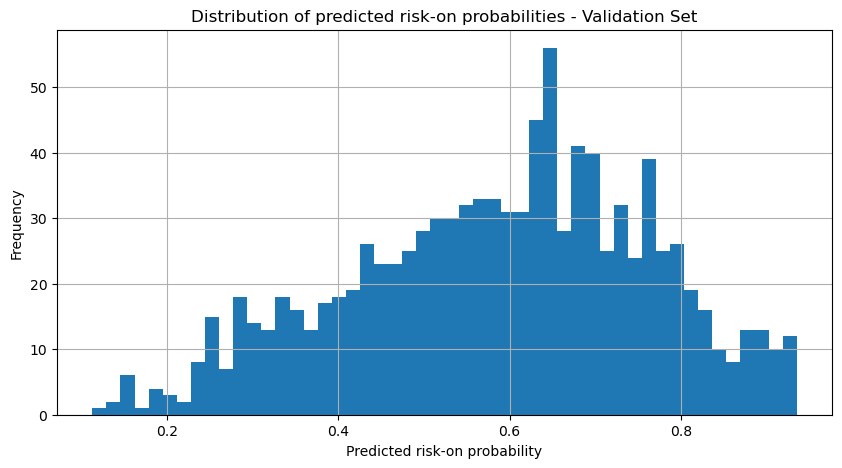

In [27]:
proba_check = pd.Series(weighted_model.predict_proba(X_val)[:, 1])

print(proba_check.describe())

plt.figure(figsize=(10, 5))
plt.hist(proba_check, bins=50)
plt.title("Distribution of predicted risk-on probabilities - Validation Set")
plt.xlabel("Predicted risk-on probability")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [28]:
threshold_results = []

val_proba = proba_check.values

threshold_grid = (
    proba_check
    .quantile(np.linspace(0.05, 0.95, 91))
    .drop_duplicates()
    .sort_values()
    .values
)

print("Threshold grid from validation probability quantiles:")
print("Min threshold:", threshold_grid.min())
print("Max threshold:", threshold_grid.max())
print("Number of thresholds:", len(threshold_grid))

for thr in threshold_grid:

    val_preds_thr = (val_proba >= thr).astype(int)

    predicted_risk_on = val_preds_thr.sum()
    predicted_risk_off = len(val_preds_thr) - predicted_risk_on
    risk_on_ratio = predicted_risk_on / len(val_preds_thr)

    acc = accuracy_score(y_val, val_preds_thr)

    f1_class1 = f1_score(
        y_val,
        val_preds_thr,
        zero_division=0
    )

    f1_macro = f1_score(
        y_val,
        val_preds_thr,
        average="macro",
        zero_division=0
    )

    threshold_results.append({
        "threshold": thr,
        "accuracy": acc,
        "f1_class1": f1_class1,
        "f1_macro": f1_macro,
        "predicted_risk_on": predicted_risk_on,
        "predicted_risk_off": predicted_risk_off,
        "risk_on_ratio": risk_on_ratio
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results = threshold_results.sort_values(
    "f1_macro",
    ascending=False
)

threshold_results.head(20)

Threshold grid from validation probability quantiles:
Min threshold: 0.27910093367099764
Max threshold: 0.8664990782737731
Number of thresholds: 91


,threshold,accuracy,f1_class1,f1_macro,predicted_risk_on,predicted_risk_off,risk_on_ratio
62,0.679623,0.554795,0.370678,0.513121,337,685,0.329746
63,0.683369,0.556751,0.364656,0.512155,327,695,0.319961
61,0.674016,0.547945,0.370572,0.508950,348,674,0.340509
60,0.669782,0.544031,0.373656,0.507597,358,664,0.350294
59,0.665022,0.540117,0.376658,0.506158,368,654,0.360078
57,0.652761,0.534247,0.385013,0.505105,388,634,0.379648
64,0.685888,0.552838,0.349929,0.504569,317,705,0.310176
58,0.658369,0.534247,0.376963,0.502544,378,644,0.369863
65,0.691448,0.552838,0.340548,0.501140,307,715,0.300391
56,0.649796,0.527397,0.384713,0.500538,399,623,0.390411


In [29]:
best_threshold = threshold_results.iloc[0]["threshold"]

print("Best weighted risk-on threshold:", best_threshold)
print("Best validation F1 class 1:", threshold_results.iloc[0]["f1_class1"])
print("Best validation F1 macro:", threshold_results.iloc[0]["f1_macro"])
print("Predicted risk-on:", threshold_results.iloc[0]["predicted_risk_on"])
print("Predicted risk-off:", threshold_results.iloc[0]["predicted_risk_off"])
print("Risk-on ratio:", threshold_results.iloc[0]["risk_on_ratio"])

Best weighted risk-on threshold: 0.6796231532096864
Best validation F1 class 1: 0.3706777316735823
Best validation F1 macro: 0.5131208491827413
Predicted risk-on: 337.0
Predicted risk-off: 685.0
Risk-on ratio: 0.32974559686888455


In [30]:
try:
    try:
        val_proba = proba_check.values
        
        val_preds_thr = (val_proba >= best_threshold).astype(int)
        
        print("Weighted Threshold Validation Accuracy:", accuracy_score(y_val, val_preds_thr))
        print("Weighted Threshold Validation F1 class 1:", f1_score(y_val, val_preds_thr, zero_division=0))
        print("Weighted Threshold Validation F1 Macro:", f1_score(y_val, val_preds_thr, average="macro", zero_division=0))
        
        print(classification_report(y_val, val_preds_thr, zero_division=0))
        print(confusion_matrix(y_val, val_preds_thr))
        
        print("Predicted validation risk-on labels:")
        print(pd.Series(val_preds_thr).value_counts().sort_index())
    except Exception as e:
        print(f'Evaluation error: {e}')
        print(f'Unique predictions: {set(val_preds) if "val_preds" in src else "unknown"}')
except Exception as e:
    print(f"Classification report error: {e}")
    print(f"Predictions unique values: {np.unique(val_preds)}")
    print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")


Weighted Threshold Validation Accuracy: 0.5547945205479452
Weighted Threshold Validation F1 class 1: 0.3706777316735823
Weighted Threshold Validation F1 Macro: 0.5131208491827413
              precision    recall  f1-score   support

           0       0.63      0.68      0.66       636
           1       0.40      0.35      0.37       386

    accuracy                           0.55      1022
   macro avg       0.51      0.51      0.51      1022
weighted avg       0.54      0.55      0.55      1022

[[433 203]
 [252 134]]
Predicted validation risk-on labels:
0    685
1    337
Name: count, dtype: int64


In [31]:
baseline_model = weighted_model

baseline_threshold = best_threshold

baseline_val_preds = val_preds_thr.copy()

baseline_accuracy = accuracy_score(y_val, baseline_val_preds)

baseline_f1_class1 = f1_score(
    y_val,
    baseline_val_preds,
    zero_division=0
)

baseline_f1_macro = f1_score(
    y_val,
    baseline_val_preds,
    average="macro",
    zero_division=0
)

print("Weighted baseline model saved.")
print("Baseline risk-on threshold:", baseline_threshold)
print("Baseline Validation Accuracy:", baseline_accuracy)
print("Baseline Validation F1 class 1:", baseline_f1_class1)
print("Baseline Validation F1 Macro:", baseline_f1_macro)

Weighted baseline model saved.
Baseline risk-on threshold: 0.6796231532096864
Baseline Validation Accuracy: 0.5547945205479452
Baseline Validation F1 class 1: 0.3706777316735823
Baseline Validation F1 Macro: 0.5131208491827413


## 7. Hyperparameter tuning on the best label

In [32]:
def score_probability_strategy_next_open(
    valid_data,
    valid_proba,
    decision_threshold,
    low_exposure=0.55,
    high_exposure=1.00,
    risk_off_exposure=0.30,
    risk_on_boost=0.10,
    rebalance_threshold=0.10,
    fast_vol_threshold=1.40,
    cash_yield=0.04,
    cost_bps=5.0
):
    """
    Trading-oriented fold score using realistic next-open execution.

    Signal is generated after today's close.
    Position is applied from the next session open.
    Return is measured from current open to next open, so the exposure captures overnight return until the next rebalance.
    """

    fold = valid_data.copy()

    fold["target_exposure"] = np.where(
        valid_proba >= decision_threshold,
        high_exposure,
        low_exposure
    )

    fast_conditions = []

    if "close_to_ema_20" in fold.columns:
        fast_conditions.append(fold["close_to_ema_20"] < 0)

    if "return_5d" in fold.columns:
        fast_conditions.append(fold["return_5d"] < 0)

    if "volatility_ratio_5_20" in fold.columns:
        fast_conditions.append(fold["volatility_ratio_5_20"] > fast_vol_threshold)

    if len(fast_conditions) > 0:
        fast_risk_score = sum(condition.astype(int) for condition in fast_conditions)
        fast_risk_off = fast_risk_score >= min(2, len(fast_conditions))
    else:
        fast_risk_off = pd.Series(False, index=fold.index)

    if "close_to_ema_20" in fold.columns:
        short_trend_ok = fold["close_to_ema_20"] > 0
    else:
        short_trend_ok = pd.Series(True, index=fold.index)

    strong_risk_on = (
        (valid_proba >= decision_threshold)
        & short_trend_ok
        & (~fast_risk_off)
    )

    fold["target_exposure"] = np.where(
        strong_risk_on,
        fold["target_exposure"] + risk_on_boost,
        fold["target_exposure"]
    )

    fold["target_exposure"] = np.where(
        fast_risk_off,
        np.minimum(fold["target_exposure"], risk_off_exposure),
        fold["target_exposure"]
    )

    fold["target_exposure"] = fold["target_exposure"].clip(risk_off_exposure, 1.00)

    executable_target = fold["target_exposure"].shift(1).fillna(low_exposure)

    positions = []
    current_position = low_exposure

    for target in executable_target:
        if abs(target - current_position) >= rebalance_threshold:
            current_position = target
        positions.append(current_position)

    fold["position"] = positions

    fold["open_to_next_open_return"] = (
        fold["Open"].shift(-1) / fold["Open"] - 1
    ).fillna(0)

    daily_cash_return = (1 + cash_yield) ** (1 / 252) - 1
    transaction_cost = cost_bps / 10000

    fold["turnover"] = fold["position"].diff().abs().fillna(0)

    fold["strategy_return"] = (
        fold["position"] * fold["open_to_next_open_return"]
        + (1 - fold["position"]) * daily_cash_return
        - fold["turnover"] * transaction_cost
    )

    annualized_return = fold["strategy_return"].mean() * 252
    annualized_volatility = fold["strategy_return"].std() * np.sqrt(252)

    downside_returns = fold.loc[fold["strategy_return"] < 0, "strategy_return"]
    downside_volatility = downside_returns.std() * np.sqrt(252)

    sharpe = annualized_return / annualized_volatility if annualized_volatility != 0 else 0
    sortino = annualized_return / downside_volatility if downside_volatility != 0 else 0

    equity = (1 + fold["strategy_return"]).cumprod()
    drawdown = (equity / equity.cummax()) - 1
    max_drawdown = drawdown.min()

    turnover_penalty = fold["turnover"].sum() * 0.003
    drawdown_penalty = abs(max_drawdown) * 0.80

    score = (
        sharpe
        + 0.25 * sortino
        + 0.70 * annualized_return
        - drawdown_penalty
        - turnover_penalty
    )

    return score


def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": -1,
        "random_state": 42
    }

    decision_threshold = trial.suggest_float("decision_threshold", 0.40, 0.75)
    low_exposure = trial.suggest_float("low_exposure", 0.40, 0.75)
    high_exposure = trial.suggest_float("high_exposure", 0.90, 1.00)
    risk_off_exposure = trial.suggest_float("risk_off_exposure", 0.20, 0.50)
    risk_on_boost = trial.suggest_float("risk_on_boost", 0.00, 0.15)
    rebalance_threshold = trial.suggest_float("rebalance_threshold", 0.05, 0.20)
    fast_vol_threshold = trial.suggest_float("fast_vol_threshold", 1.30, 1.80)

    if not (risk_off_exposure <= low_exposure < high_exposure):
        return -100

    if X_train.empty or y_train.empty:
        print("Optuna trial skipped: empty training data")
        return -100

    if len(X_train) <= 80:
        print(f"Optuna trial skipped: not enough samples for purged CV ({len(X_train)})")
        return -100

    tscv = TimeSeriesSplit(n_splits=3, gap=20)
    fold_scores = []

    try:
        split_iterator = list(tscv.split(X_train))
    except ValueError as e:
        print(f"Optuna trial skipped: {e}")
        return -100

    for train_idx, valid_idx in split_iterator:

        X_train_fold = X_train.iloc[train_idx]
        X_valid_fold = X_train.iloc[valid_idx]
        y_train_fold = y_train.iloc[train_idx]
        valid_data_fold = train_df.iloc[valid_idx].copy()

        try:
            sample_weights_fold = compute_sample_weight(
                class_weight="balanced",
                y=y_train_fold
            )
        except Exception:
            sample_weights_fold = np.ones(len(y_train_fold))

        if X_train_fold.empty or X_valid_fold.empty or y_train_fold.nunique() < 2:
            fold_scores.append(-100)
            continue

        model = XGBClassifier(**params)

        try:
            model.fit(
                X_train_fold,
                y_train_fold,
                sample_weight=sample_weights_fold
            )

            valid_proba = model.predict_proba(X_valid_fold)[:, 1]
        except Exception as e:
            print(f"Optuna fold skipped: {e}")
            fold_scores.append(-100)
            continue

        fold_score = score_probability_strategy_next_open(
            valid_data=valid_data_fold,
            valid_proba=valid_proba,
            decision_threshold=decision_threshold,
            low_exposure=low_exposure,
            high_exposure=high_exposure,
            risk_off_exposure=risk_off_exposure,
            risk_on_boost=risk_on_boost,
            rebalance_threshold=rebalance_threshold,
            fast_vol_threshold=fast_vol_threshold,
            cash_yield=0.04,
            cost_bps=5.0
        )

        fold_scores.append(fold_score)

    return np.mean(fold_scores)

In [33]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=50)

print("Best CV Trading Score:", study.best_value)
print("Best trial:", study.best_trial.number)
print("Best parameters:")
print(study.best_params)

[I 2026-07-17 17:03:16,859] A new study created in memory with name: no-name-cedb4bb8-6cd2-4e0a-8381-207bb915f6ed
[I 2026-07-17 17:03:16,886] Trial 0 finished with value: -100.0 and parameters: {'n_estimators': 325, 'max_depth': 8, 'learning_rate': 0.060285631437218844, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 4.330880728874676, 'reg_lambda': 6.051038616257767, 'decision_threshold': 0.647825402228616, 'low_exposure': 0.40720457300353086, 'high_exposure': 0.9969909852161994, 'risk_off_exposure': 0.4497327922401265, 'risk_on_boost': 0.03185086660174142, 'rebalance_threshold': 0.0772737450810651, 'fast_vol_threshold': 1.391702254926717}. Best is trial 0 with value: -100.0.
[I 2026-07-17 17:03:21,248] Trial 1 finished with value: 1.9335879798010718 and parameters: {'n_estimators': 282, 'max_depth': 5, 'learning_rate': 0.02172727054864738, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8

Best CV Trading Score: 2.095557548508511
Best trial: 47
Best parameters:
{'n_estimators': 403, 'max_depth': 3, 'learning_rate': 0.00955422002504833, 'subsample': 0.6625031385998675, 'colsample_bytree': 0.6101546057754078, 'min_child_weight': 4, 'gamma': 3.932976878817305, 'reg_alpha': 4.614839699730521, 'reg_lambda': 0.16473024414043605, 'decision_threshold': 0.6420788307537086, 'low_exposure': 0.40142115664992956, 'high_exposure': 0.9054521898590371, 'risk_off_exposure': 0.3673968851785068, 'risk_on_boost': 0.00704151522340518, 'rebalance_threshold': 0.06154828694375286, 'fast_vol_threshold': 1.6975586665579072}


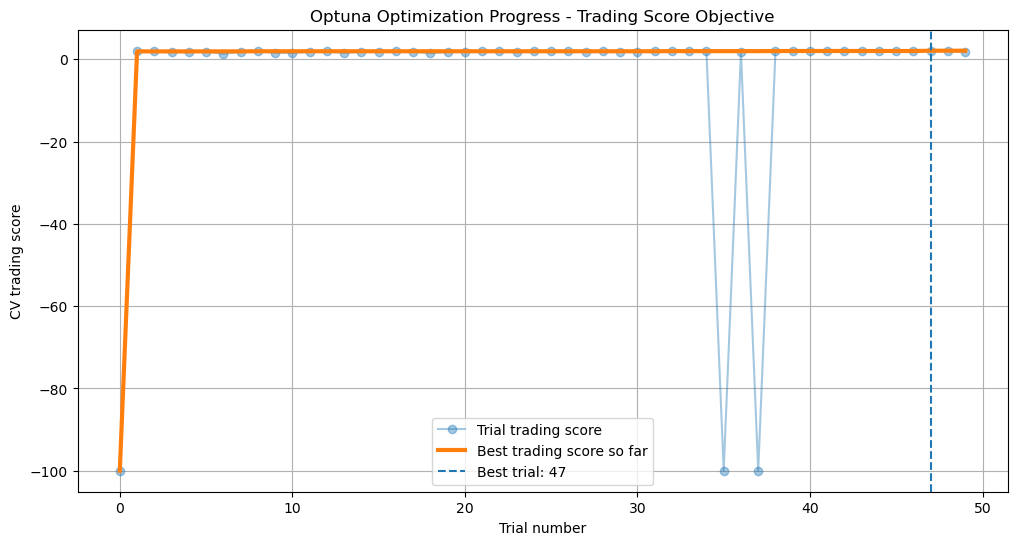

Best trial number: 47
Best CV Trading Score: 2.095557548508511
Total completed trials: 50


In [34]:
trials_df = study.trials_dataframe()

trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()

trials_df["best_so_far"] = trials_df["value"].cummax()

best_trial_number = study.best_trial.number
best_score = study.best_value

plt.figure(figsize=(12, 6))

plt.plot(
    trials_df["number"],
    trials_df["value"],
    marker="o",
    alpha=0.4,
    label="Trial trading score"
)

plt.plot(
    trials_df["number"],
    trials_df["best_so_far"],
    linewidth=3,
    label="Best trading score so far"
)

plt.axvline(
    best_trial_number,
    linestyle="--",
    label=f"Best trial: {best_trial_number}"
)

plt.xlabel("Trial number")
plt.ylabel("CV trading score")
plt.title("Optuna Optimization Progress - Trading Score Objective")
plt.legend()
plt.grid(True)
plt.show()

print("Best trial number:", best_trial_number)
print("Best CV Trading Score:", best_score)
print("Total completed trials:", len(trials_df))

In [35]:
best_params = study.best_params.copy()

best_threshold = best_params.pop("decision_threshold")
best_low_exposure = best_params.pop("low_exposure")
best_high_exposure = best_params.pop("high_exposure")
best_risk_off_exposure = best_params.pop("risk_off_exposure")
best_risk_on_boost = best_params.pop("risk_on_boost")
best_rebalance_threshold = best_params.pop("rebalance_threshold")
best_fast_vol_threshold = best_params.pop("fast_vol_threshold")

best_optuna_strategy_params = {
    "decision_threshold": best_threshold,
    "low_exposure": best_low_exposure,
    "high_exposure": best_high_exposure,
    "risk_off_exposure": best_risk_off_exposure,
    "risk_on_boost": best_risk_on_boost,
    "rebalance_threshold": best_rebalance_threshold,
    "fast_vol_threshold": best_fast_vol_threshold
}

print("Best Optuna trading threshold:", best_threshold)
print("Best Optuna low exposure:", best_low_exposure)
print("Best Optuna high exposure:", best_high_exposure)
print("Best Optuna risk-off exposure:", best_risk_off_exposure)
print("Best Optuna risk-on boost:", best_risk_on_boost)
print("Best Optuna rebalance threshold:", best_rebalance_threshold)
print("Best Optuna fast volatility threshold:", best_fast_vol_threshold)

print("Best Optuna strategy params:")
print(best_optuna_strategy_params)

print("Best XGBoost params:")
print(best_params)

Best Optuna trading threshold: 0.6420788307537086
Best Optuna low exposure: 0.40142115664992956
Best Optuna high exposure: 0.9054521898590371
Best Optuna risk-off exposure: 0.3673968851785068
Best Optuna risk-on boost: 0.00704151522340518
Best Optuna rebalance threshold: 0.06154828694375286
Best Optuna fast volatility threshold: 1.6975586665579072
Best Optuna strategy params:
{'decision_threshold': 0.6420788307537086, 'low_exposure': 0.40142115664992956, 'high_exposure': 0.9054521898590371, 'risk_off_exposure': 0.3673968851785068, 'risk_on_boost': 0.00704151522340518, 'rebalance_threshold': 0.06154828694375286, 'fast_vol_threshold': 1.6975586665579072}
Best XGBoost params:
{'n_estimators': 403, 'max_depth': 3, 'learning_rate': 0.00955422002504833, 'subsample': 0.6625031385998675, 'colsample_bytree': 0.6101546057754078, 'min_child_weight': 4, 'gamma': 3.932976878817305, 'reg_alpha': 4.614839699730521, 'reg_lambda': 0.16473024414043605}


In [36]:
try:
    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=np.asarray(y_train).astype(int)
    )
except Exception as e:
    print(f"Sample weight error for tuned model: {e}, using uniform weights")
    sample_weights = np.ones(len(y_train))

tuned_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

tuned_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Tuned XGBoost model trained.")

Tuned XGBoost model trained.


In [37]:
val_proba_tuned = tuned_model.predict_proba(X_val)[:, 1]

val_preds_tuned = (val_proba_tuned >= best_threshold).astype(int)

print("Tuned Model Validation Metrics using Optuna Trading Threshold")
print("Tuned Validation Accuracy:", accuracy_score(y_val, val_preds_tuned))
print("Tuned Validation F1 class 1:", f1_score(y_val, val_preds_tuned, zero_division=0))
print("Tuned Validation F1 macro:", f1_score(y_val, val_preds_tuned, average="macro", zero_division=0))

print(classification_report(y_val, val_preds_tuned, zero_division=0))
print(confusion_matrix(y_val, val_preds_tuned))

print("Predicted validation risk-on labels:")
print(pd.Series(val_preds_tuned).value_counts().sort_index())

Tuned Model Validation Metrics using Optuna Trading Threshold
Tuned Validation Accuracy: 0.6095890410958904
Tuned Validation F1 class 1: 0.16701461377870563
Tuned Validation F1 macro: 0.45603126855069465
              precision    recall  f1-score   support

           0       0.63      0.92      0.75       636
           1       0.43      0.10      0.17       386

    accuracy                           0.61      1022
   macro avg       0.53      0.51      0.46      1022
weighted avg       0.55      0.61      0.53      1022

[[583  53]
 [346  40]]
Predicted validation risk-on labels:
0    929
1     93
Name: count, dtype: int64


## 8. Dynamic Exposure Strategy and Backtesting

In [38]:
def run_stock_strategy_backtest(data,
                                proba_column="risk_on_proba",
                                price_column="Close",
                                lower_threshold=None,
                                upper_threshold=None,
                                base_exposure=0.75,
                                model_tilt=0.20,
                                trend_bonus=0.10,
                                trend_penalty=0.20,
                                risk_off_exposure=0.35,
                                risk_on_boost=0.10,
                                recovery_min_exposure=0.85,
                                recovery_step_up_limit=0.15,
                                bull_min_exposure=1.00,
                                bull_leverage_exposure=1.25,
                                target_vol=0.30,
                                vol_floor=0.60,
                                vol_ceiling=1.10,
                                vix_risk_multiplier=0.90,
                                drawdown_cutoff=-0.07,
                                drawdown_risk_multiplier=0.70,
                                min_exposure=0.30,
                                max_exposure=1.25,
                                rebalance_threshold=0.10,
                                fast_vol_threshold=1.40,
                                early_risk_on_boost=0.05,
                                early_recovery_min_exposure=0.75,
                                early_risk_on_score_threshold=4,
                                cash_yield=0.04,
                                leverage_financing_rate=0.06,
                                cost_bps=5.0,
                                use_sentiment_overlay=True,
                                sentiment_positive_threshold=0.10,
                                sentiment_negative_threshold=-0.10,
                                sentiment_boost=0.10,
                                sentiment_penalty=0.15,
                                sentiment_news_z_threshold=1.0,
                                sentiment_sensitivity=2.0,
                                sentiment_positive_max_adjustment=0.15,
                                sentiment_negative_max_adjustment=0.20,
                                sentiment_asymmetric_factor=3.0,
                                sentiment_whipsaw_days=2,
                                sentiment_regime_gate=True,
                                sentiment_confidence_headlines=3.0):

    df_bt = data.copy()

    if lower_threshold is None:
        lower_threshold = df_bt[proba_column].quantile(0.30)

    if upper_threshold is None:
        upper_threshold = df_bt[proba_column].quantile(0.70)

    proba_range = max(upper_threshold - lower_threshold, 1e-9)

    df_bt["probability_tilt"] = (
        (df_bt[proba_column] - lower_threshold) / proba_range
    ).clip(0, 1)

    df_bt["probability_tilt"] = (
        df_bt["probability_tilt"] * 2 - 1
    ) * model_tilt

    if "close_to_ema_200" in df_bt.columns:
        trend_on = df_bt["close_to_ema_200"] > 0
    elif "ema_200" in df_bt.columns:
        trend_on = df_bt[price_column] > df_bt["ema_200"]
    else:
        trend_on = pd.Series(True, index=df_bt.index)

    df_bt["trend_on"] = trend_on.astype(int)

    df_bt["trend_adjustment"] = np.where(
        df_bt["trend_on"] == 1,
        trend_bonus,
        -trend_penalty
    )

    df_bt["raw_exposure"] = (
        base_exposure
        + df_bt["probability_tilt"]
        + df_bt["trend_adjustment"]
    )

    # Realistic next-open execution:
    # yesterday's signal is applied at today's open and held until the next open/rebalance.
    df_bt["market_return"] = (
        df_bt["Open"].shift(-1) / df_bt["Open"] - 1
    ).fillna(0)

    past_open_return = df_bt["Open"].pct_change(fill_method=None)

    df_bt["realized_vol_20d"] = (
        past_open_return
        .rolling(20)
        .std()
        .shift(1)
        * np.sqrt(252)
    )

    df_bt["vol_multiplier"] = (
        target_vol / df_bt["realized_vol_20d"]
    ).clip(vol_floor, vol_ceiling)

    df_bt["vol_multiplier"] = df_bt["vol_multiplier"].fillna(1.0)

    if "vix_level" in df_bt.columns:
        df_bt["vix_ma_20"] = df_bt["vix_level"].rolling(20).mean()
        df_bt["vix_multiplier"] = np.where(
            df_bt["vix_level"].shift(1) > df_bt["vix_ma_20"].shift(1),
            vix_risk_multiplier,
            1.0
        )
    else:
        df_bt["vix_multiplier"] = 1.0

    df_bt["rolling_high_60d"] = df_bt[price_column].rolling(60).max()
    df_bt["drawdown_60d"] = (df_bt[price_column].shift(1) / df_bt["rolling_high_60d"].shift(1)) - 1

    df_bt["drawdown_multiplier"] = np.where(
        df_bt["drawdown_60d"] < drawdown_cutoff,
        drawdown_risk_multiplier,
        1.0
    )

    df_bt["target_position"] = (
        df_bt["raw_exposure"]
        * df_bt["vol_multiplier"]
        * df_bt["vix_multiplier"]
        * df_bt["drawdown_multiplier"]
    )

    df_bt["target_position"] = np.where(
        (df_bt["trend_on"] == 0) & (df_bt[proba_column] < lower_threshold),
        np.minimum(df_bt["target_position"], risk_off_exposure),
        df_bt["target_position"]
    )


    fast_conditions = []

    if "close_to_ema_20" in df_bt.columns:
        fast_conditions.append(df_bt["close_to_ema_20"] < 0)

    if "return_5d" in df_bt.columns:
        fast_conditions.append(df_bt["return_5d"] < 0)

    if "volatility_ratio_5_20" in df_bt.columns:
        fast_conditions.append(df_bt["volatility_ratio_5_20"] > fast_vol_threshold)

    if len(fast_conditions) > 0:
        fast_risk_score = sum(condition.astype(int) for condition in fast_conditions)
        fast_risk_off = fast_risk_score >= min(2, len(fast_conditions))
    else:
        fast_risk_score = pd.Series(0, index=df_bt.index)
        fast_risk_off = pd.Series(False, index=df_bt.index)

    df_bt["fast_risk_score"] = fast_risk_score
    df_bt["fast_risk_off"] = fast_risk_off.astype(int)

    early_risk_on_conditions = []

    if "close_to_ema_20" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["close_to_ema_20"] > 0)

    if "ema_20_slope_3d" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["ema_20_slope_3d"] > 0)

    if "return_5d" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["return_5d"] > 0)

    if "return_3d_minus_10d" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["return_3d_minus_10d"] > 0)

    if "return_5d_minus_20d" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["return_5d_minus_20d"] > 0)

    if "volatility_ratio_5_20" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["volatility_ratio_5_20"] < fast_vol_threshold)

    if "vix_change_5d" in df_bt.columns:
        early_risk_on_conditions.append(df_bt["vix_change_5d"] < 0)

    if early_risk_on_conditions:
        early_risk_on_score = sum(condition.astype(int) for condition in early_risk_on_conditions)
    else:
        early_risk_on_score = pd.Series(0, index=df_bt.index)

    early_risk_on = (
        (early_risk_on_score >= early_risk_on_score_threshold)
        & (df_bt["fast_risk_off"] == 0)
    )

    df_bt["early_risk_on_score"] = early_risk_on_score
    df_bt["early_risk_on"] = early_risk_on.astype(int)

    if "close_to_ema_20" in df_bt.columns:
        short_trend_ok = df_bt["close_to_ema_20"] > 0
    else:
        short_trend_ok = pd.Series(True, index=df_bt.index)

    if "return_20d" in df_bt.columns:
        medium_momentum_ok = df_bt["return_20d"] > 0
        strong_medium_momentum = df_bt["return_20d"] > 0.05
    else:
        medium_momentum_ok = pd.Series(True, index=df_bt.index)
        strong_medium_momentum = pd.Series(True, index=df_bt.index)

    if "return_60d" in df_bt.columns:
        long_momentum_ok = df_bt["return_60d"] > 0
        strong_long_momentum = df_bt["return_60d"] > 0.08
    else:
        long_momentum_ok = pd.Series(True, index=df_bt.index)
        strong_long_momentum = pd.Series(True, index=df_bt.index)

    if "return_5d" in df_bt.columns:
        short_momentum_ok = df_bt["return_5d"] > 0
    else:
        short_momentum_ok = pd.Series(True, index=df_bt.index)

    if "drawdown_20d" in df_bt.columns:
        near_recent_high = df_bt["drawdown_20d"] > -0.08
    else:
        near_recent_high = pd.Series(True, index=df_bt.index)

    if "volatility_ratio_5_20" in df_bt.columns:
        volatility_not_extreme = df_bt["volatility_ratio_5_20"] < fast_vol_threshold
    else:
        volatility_not_extreme = pd.Series(True, index=df_bt.index)

    strong_risk_on = (
        (df_bt[proba_column] >= upper_threshold)
        & (df_bt["trend_on"] == 1)
        & short_trend_ok
        & (df_bt["fast_risk_off"] == 0)
    )

    recovery_risk_on = (
        strong_risk_on
        & medium_momentum_ok
        & short_momentum_ok
    )

    strong_bull_regime = (
        recovery_risk_on
        & long_momentum_ok
        & near_recent_high
        & volatility_not_extreme
    )

    leveraged_bull_regime = (
        strong_bull_regime
        & strong_medium_momentum
        & strong_long_momentum
    )

    df_bt["recovery_risk_on"] = recovery_risk_on.astype(int)
    df_bt["strong_bull_regime"] = strong_bull_regime.astype(int)
    df_bt["leveraged_bull_regime"] = leveraged_bull_regime.astype(int)

    df_bt["target_position"] = np.where(
        strong_risk_on,
        df_bt["target_position"] + risk_on_boost,
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["recovery_risk_on"] == 1,
        np.maximum(df_bt["target_position"], recovery_min_exposure),
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["strong_bull_regime"] == 1,
        np.maximum(df_bt["target_position"], bull_min_exposure),
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["leveraged_bull_regime"] == 1,
        np.maximum(df_bt["target_position"], bull_leverage_exposure),
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["early_risk_on"] == 1,
        df_bt["target_position"] + early_risk_on_boost,
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["early_risk_on"] == 1,
        np.maximum(df_bt["target_position"], early_recovery_min_exposure),
        df_bt["target_position"]
    )

    df_bt["target_position"] = np.where(
        df_bt["fast_risk_off"] == 1,
        np.minimum(df_bt["target_position"], risk_off_exposure),
        df_bt["target_position"]
    )

    # Multiplicative real-news sentiment scaler.
    if use_sentiment_overlay and "sentiment_ma_5d" in df_bt.columns:
        sentiment_signal = df_bt["sentiment_ma_5d"].fillna(0.0)
        sentiment_change = df_bt.get("sentiment_change_3d", pd.Series(0.0, index=df_bt.index)).fillna(0.0)
        news_volume = df_bt.get("news_volume", pd.Series(0.0, index=df_bt.index)).fillna(0.0)
        news_z = df_bt.get("news_volume_zscore", pd.Series(0.0, index=df_bt.index)).fillna(0.0)
        has_news = news_volume > 0

        df_bt["sentiment_score_raw"] = 0.70 * sentiment_signal + 0.30 * sentiment_change
        df_bt.loc[~has_news, "sentiment_score_raw"] = 0.0

        df_bt["sentiment_score_scaled"] = np.tanh(
            df_bt["sentiment_score_raw"] * sentiment_sensitivity
        )

        df_bt["sentiment_confidence"] = np.where(
            has_news,
            (
                (news_volume / max(sentiment_confidence_headlines, 1e-9)).clip(0, 1)
                + 0.25 * (news_z > sentiment_news_z_threshold).astype(float)
            ).clip(0, 1),
            0.0,
        )

        sentiment_dir = np.sign(df_bt["sentiment_score_scaled"])
        streak_id = (sentiment_dir != sentiment_dir.shift()).cumsum()
        cons_days = sentiment_dir.groupby(streak_id).cumcount() + 1
        whipsaw_ok = (sentiment_dir == 0) | (cons_days >= sentiment_whipsaw_days)

        pos_limit = sentiment_positive_max_adjustment
        neg_limit = sentiment_negative_max_adjustment * sentiment_asymmetric_factor

        pos_scale = df_bt["sentiment_score_scaled"].clip(lower=0) * df_bt["sentiment_confidence"] * pos_limit
        neg_scale = df_bt["sentiment_score_scaled"].clip(upper=0) * df_bt["sentiment_confidence"] * neg_limit

        raw_mult = 1.0 + pos_scale + neg_scale
        mult = np.where(has_news & whipsaw_ok, raw_mult, 1.0)

        # Regime gate: composite market fear overrides positive sentiment
        if sentiment_regime_gate:
            vix_fear = df_bt.get("vix_multiplier", pd.Series(1.0, index=df_bt.index)) < 1.0
            vol_fear = df_bt.get("volatility_ratio_5_20", pd.Series(0.0, index=df_bt.index)) > 1.5
            dd_fear = df_bt.get("drawdown_60d", pd.Series(0.0, index=df_bt.index)) < -0.10
            composite_fear = (vix_fear.astype(int) + vol_fear.astype(int) + dd_fear.astype(int)) >= 2
            mult = np.where(composite_fear & (mult > 1.0), 1.0, mult)

            # In strong bull: cap negative impact
            strong_bull = df_bt.get("strong_bull_regime", pd.Series(0, index=df_bt.index))
            mult = np.where((strong_bull == 1) & (mult < 1.0), np.maximum(mult, 0.97), mult)

        df_bt["sentiment_multiplier"] = np.where(has_news, mult, 1.0)
        df_bt["sentiment_adjustment"] = df_bt["sentiment_multiplier"] - 1.0
        df_bt["sentiment_whipsaw_active"] = (~whipsaw_ok).astype(int)
        df_bt["sentiment_risk_on"] = df_bt["sentiment_multiplier"] > 1.0
        df_bt["sentiment_risk_off"] = df_bt["sentiment_multiplier"] < 1.0

        df_bt["target_position"] = df_bt["target_position"] * df_bt["sentiment_multiplier"]

        # Fast risk-off cap runs after multiplicative scaler
        df_bt["target_position"] = np.where(
            df_bt["fast_risk_off"] == 1,
            np.minimum(df_bt["target_position"], risk_off_exposure),
            df_bt["target_position"]
        )
    else:
        df_bt["sentiment_score_raw"] = 0.0
        df_bt["sentiment_score_scaled"] = 0.0
        df_bt["sentiment_confidence"] = 0.0
        df_bt["sentiment_adjustment"] = 0.0
        df_bt["sentiment_multiplier"] = 1.0
        df_bt["sentiment_whipsaw_active"] = 0
        df_bt["sentiment_risk_on"] = False
        df_bt["sentiment_risk_off"] = False

    df_bt["target_position"] = np.where(
        df_bt["fast_risk_off"] == 1,
        np.minimum(df_bt["target_position"], risk_off_exposure),
        df_bt["target_position"]
    )

    df_bt["target_position"] = df_bt["target_position"].clip(min_exposure, max_exposure)

    df_bt["target_position"] = np.where(
        df_bt["fast_risk_off"] == 1,
        np.minimum(df_bt["target_position"], risk_off_exposure),
        df_bt["target_position"]
    )

    # Signal is generated after the close.
    # The target position is known for the next session.
    executable_target_position = df_bt["target_position"].shift(1).fillna(base_exposure)

    # No-trade band:
    # rebalance only when target exposure differs enough from current exposure.
    positions = []
    current_position = base_exposure

    if recovery_step_up_limit is None:
        effective_recovery_step = 0.0
    else:
        effective_recovery_step = float(recovery_step_up_limit)

    for target in executable_target_position:
        if abs(target - current_position) >= rebalance_threshold:
            next_position = target
            if effective_recovery_step > 0 and current_position < base_exposure and target > current_position:
                next_position = min(target, current_position + effective_recovery_step)
            current_position = next_position

        positions.append(current_position)

    df_bt["position"] = positions

    transaction_cost = cost_bps / 10000
    daily_cash_return = (1 + cash_yield) ** (1 / 252) - 1
    daily_financing_cost = (1 + leverage_financing_rate) ** (1 / 252) - 1

    df_bt["turnover"] = df_bt["position"].diff().abs().fillna(0)
    df_bt["cash_weight"] = (1 - df_bt["position"]).clip(lower=0)
    df_bt["leverage_amount"] = (df_bt["position"] - 1).clip(lower=0)
    df_bt["financing_cost"] = df_bt["leverage_amount"] * daily_financing_cost

    df_bt["strategy_return_gross"] = (
        df_bt["position"] * df_bt["market_return"]
        + df_bt["cash_weight"] * daily_cash_return
        - df_bt["financing_cost"]
    )

    df_bt["strategy_return_net"] = (
        df_bt["strategy_return_gross"]
        - df_bt["turnover"] * transaction_cost
    )

    df_bt["strategy_equity"] = (1 + df_bt["strategy_return_net"]).cumprod()
    df_bt["buy_hold_equity"] = (1 + df_bt["market_return"]).cumprod()

    df_bt["strategy_drawdown"] = (
        df_bt["strategy_equity"] / df_bt["strategy_equity"].cummax()
    ) - 1

    df_bt["buy_hold_drawdown"] = (
        df_bt["buy_hold_equity"] / df_bt["buy_hold_equity"].cummax()
    ) - 1

    strategy_returns = df_bt["strategy_return_net"]
    downside_returns = strategy_returns[strategy_returns < 0]

    annualized_return = strategy_returns.mean() * 252
    annualized_volatility = strategy_returns.std() * np.sqrt(252)
    downside_volatility = downside_returns.std() * np.sqrt(252)
    max_drawdown = df_bt["strategy_drawdown"].min()

    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan
    sortino_ratio = annualized_return / downside_volatility if downside_volatility != 0 else np.nan
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    gross_profit = strategy_returns[strategy_returns > 0].sum()
    gross_loss = -strategy_returns[strategy_returns < 0].sum()
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan

    metrics = pd.Series({
        "Strategy Total Return": df_bt["strategy_equity"].iloc[-1] - 1,
        "Buy & Hold Total Return": df_bt["buy_hold_equity"].iloc[-1] - 1,
        "Excess Return vs Buy & Hold": df_bt["strategy_equity"].iloc[-1] - df_bt["buy_hold_equity"].iloc[-1],
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Calmar Ratio": calmar_ratio,
        "Profit Factor": profit_factor,
        "Max Drawdown": max_drawdown,
        "Win Rate": (strategy_returns > 0).mean(),
        "Average Exposure": df_bt["position"].mean(),
        "Strong Bull Days": df_bt["strong_bull_regime"].sum(),
        "Leveraged Days": (df_bt["position"] > 1.0).sum(),
        "Average Leverage": df_bt["leverage_amount"].mean(),
        "Total Financing Cost": df_bt["financing_cost"].sum(),
        "Fast Risk-Off Days": df_bt["fast_risk_off"].sum(),
        "Early Risk-On Days": df_bt["early_risk_on"].sum(),
        "Average Early Risk-On Score": df_bt["early_risk_on_score"].mean(),
        "Sentiment Risk-On Days": df_bt["sentiment_risk_on"].sum(),
        "Sentiment Risk-Off Days": df_bt["sentiment_risk_off"].sum(),
        "Average Sentiment Multiplier": df_bt["sentiment_multiplier"].mean() if "sentiment_multiplier" in df_bt.columns else 1.0,
        "Whipsaw Filtered Days": df_bt["sentiment_whipsaw_active"].sum() if "sentiment_whipsaw_active" in df_bt.columns else 0,
        "Average Sentiment Adjustment": df_bt["sentiment_adjustment"].mean(),
        "Rebalance Days": (df_bt["turnover"] > 0).sum(),
        "Total Turnover": df_bt["turnover"].sum(),
        "Average Daily Turnover": df_bt["turnover"].mean()
    })

    return df_bt, metrics


def get_buy_hold_metrics(bt_data):
    buy_hold_returns = bt_data["market_return"]
    downside_returns = buy_hold_returns[buy_hold_returns < 0]

    annualized_return = buy_hold_returns.mean() * 252
    annualized_volatility = buy_hold_returns.std() * np.sqrt(252)
    downside_volatility = downside_returns.std() * np.sqrt(252)
    max_drawdown = bt_data["buy_hold_drawdown"].min()

    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan
    sortino_ratio = annualized_return / downside_volatility if downside_volatility != 0 else np.nan
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    gross_profit = buy_hold_returns[buy_hold_returns > 0].sum()
    gross_loss = -buy_hold_returns[buy_hold_returns < 0].sum()
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan

    return pd.Series({
        "Total Return": bt_data["buy_hold_equity"].iloc[-1] - 1,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Calmar Ratio": calmar_ratio,
        "Profit Factor": profit_factor,
        "Max Drawdown": max_drawdown,
        "Win Rate": (buy_hold_returns > 0).mean(),
        "Average Exposure": 1.0,
        "Strong Bull Days": 0,
        "Leveraged Days": 0,
        "Average Leverage": 0.0,
        "Total Financing Cost": 0.0,
        "Fast Risk-Off Days": 0,
        "Rebalance Days": 1,
        "Total Turnover": 1.0,
        "Average Daily Turnover": 0.0
    })


def optimize_stock_strategy(model, model_name, data, X):
    opt_df = data.copy()
    opt_df["risk_on_proba"] = model.predict_proba(X)[:, 1]

    reference_bt, _ = run_stock_strategy_backtest(
        opt_df,
        proba_column="risk_on_proba",
        lower_threshold=opt_df["risk_on_proba"].quantile(0.30),
        upper_threshold=opt_df["risk_on_proba"].quantile(0.70),
        base_exposure=1.0,
        model_tilt=0.0,
        trend_bonus=0.0,
        trend_penalty=0.0,
        risk_off_exposure=1.0,
        risk_on_boost=0.0,
        recovery_min_exposure=1.0,
        bull_min_exposure=1.0,
        bull_leverage_exposure=1.0,
        target_vol=1.0,
        vol_floor=1.0,
        vol_ceiling=1.0,
        vix_risk_multiplier=1.0,
        drawdown_cutoff=-1.0,
        drawdown_risk_multiplier=1.0,
        min_exposure=1.0,
        max_exposure=1.0,
        rebalance_threshold=1.0,
        fast_vol_threshold=99.0,
        cash_yield=0.0,
        leverage_financing_rate=0.0,
        cost_bps=0.0
    )

    buy_hold_metrics = get_buy_hold_metrics(reference_bt)
    rows = []

    for lower_q in [0.25, 0.35]:
        for upper_q in [0.65, 0.75]:
            if lower_q >= upper_q:
                continue

            lower_threshold = opt_df["risk_on_proba"].quantile(lower_q)
            upper_threshold = opt_df["risk_on_proba"].quantile(upper_q)

            for base_exposure in [0.70, 0.85, 0.95]:
                for model_tilt in [0.15, 0.25]:
                    for trend_penalty in [0.20, 0.35]:
                        for risk_off_exposure in [0.25, 0.40, 0.50]:
                            for target_vol in [0.35, 0.45, 0.55]:
                                for drawdown_cutoff in [-0.05, -0.10]:
                                    for rebalance_threshold in [0.05, 0.10, 0.15]:
                                        for fast_vol_threshold in [1.35, 1.55]:
                                            bt, metrics = run_stock_strategy_backtest(
                                                opt_df,
                                                proba_column="risk_on_proba",
                                                lower_threshold=lower_threshold,
                                                upper_threshold=upper_threshold,
                                                base_exposure=base_exposure,
                                                model_tilt=model_tilt,
                                                trend_bonus=0.05,
                                                trend_penalty=trend_penalty,
                                                risk_off_exposure=risk_off_exposure,
                                                risk_on_boost=0.10,
                                                recovery_min_exposure=0.85,
                                                bull_min_exposure=1.00,
                                                bull_leverage_exposure=1.25,
                                                target_vol=target_vol,
                                                vol_floor=0.65,
                                                vol_ceiling=1.10,
                                                vix_risk_multiplier=0.90,
                                                drawdown_cutoff=drawdown_cutoff,
                                                drawdown_risk_multiplier=0.70,
                                                min_exposure=0.25,
                                                max_exposure=1.25,
                                                rebalance_threshold=rebalance_threshold,
                                                fast_vol_threshold=fast_vol_threshold,
                                                cash_yield=0.04,
                                                leverage_financing_rate=0.06,
                                                cost_bps=5.0
                                            )

                                            sharpe_edge = metrics["Sharpe Ratio"] - buy_hold_metrics["Sharpe Ratio"]
                                            drawdown_edge = metrics["Max Drawdown"] - buy_hold_metrics["Max Drawdown"]
                                            return_edge = metrics["Annualized Return"] - buy_hold_metrics["Annualized Return"]
                                            vol_reduction = 1 - metrics["Annualized Volatility"] / buy_hold_metrics["Annualized Volatility"] if buy_hold_metrics["Annualized Volatility"] != 0 else np.nan

                                            score = (
                                                2.75 * metrics["Sharpe Ratio"]
                                                + 0.50 * (0 if pd.isna(metrics["Sortino Ratio"]) else metrics["Sortino Ratio"])
                                                + 0.75 * drawdown_edge
                                                + 0.75 * return_edge
                                                + 0.25 * vol_reduction
                                                - 0.003 * metrics["Total Turnover"]
                                            )

                                            rows.append({
                                                "model_name": model_name,
                                                "lower_q": lower_q,
                                                "upper_q": upper_q,
                                                "lower_threshold": lower_threshold,
                                                "upper_threshold": upper_threshold,
                                                "base_exposure": base_exposure,
                                                "model_tilt": model_tilt,
                                                "trend_penalty": trend_penalty,
                                                "risk_off_exposure": risk_off_exposure,
                                                "target_vol": target_vol,
                                                "drawdown_cutoff": drawdown_cutoff,
                                                "rebalance_threshold": rebalance_threshold,
                                                "fast_vol_threshold": fast_vol_threshold,
                                                "Sharpe Ratio": metrics["Sharpe Ratio"],
                                                "Buy & Hold Sharpe": buy_hold_metrics["Sharpe Ratio"],
                                                "Sharpe Edge": sharpe_edge,
                                                "Max Drawdown": metrics["Max Drawdown"],
                                                "Buy & Hold Max Drawdown": buy_hold_metrics["Max Drawdown"],
                                                "Drawdown Edge": drawdown_edge,
                                                "Annualized Return": metrics["Annualized Return"],
                                                "Annualized Volatility": metrics["Annualized Volatility"],
                                                "Return Edge": return_edge,
                                                "Volatility Reduction": vol_reduction,
                                                "Average Exposure": metrics["Average Exposure"],
                                                "Fast Risk-Off Days": metrics["Fast Risk-Off Days"],
                                                "Total Turnover": metrics["Total Turnover"],
                                                "beats_buy_hold_sharpe": sharpe_edge > 0,
                                                "lower_drawdown_than_buy_hold": drawdown_edge > 0,
                                                "score": score
                                            })

    results = pd.DataFrame(rows)

    results = results.sort_values(
        ["beats_buy_hold_sharpe", "lower_drawdown_than_buy_hold", "score"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return results


### 8b. Walk-Forward Model Selection: Weighted vs Optuna

Walk-forward evaluation runs over the combined train+validation region and selects the model family by average fold Sharpe.
After that family is selected, a train-only `validation_model` is used on the validation split to choose risk/exposure settings, early-risk-on settings and sentiment settings.
Once those settings are locked, `final_model` is retrained on train+validation and used for the final test.


In [39]:
# ---------------------------------------------------------------------------
# Walk-forward model selection: Weighted baseline vs Optuna tuned
# ---------------------------------------------------------------------------

WF_FOLD_TEST_DAYS = 63
WF_FOLD_STEP_DAYS = 63
WF_MIN_TRAIN_DAYS = len(train_df_raw)
WF_TARGET_QUANTILE = 0.60

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

selection_raw = pd.concat([train_df_raw, val_df_raw]).sort_index()
selection_raw = selection_raw.loc[~selection_raw.index.duplicated(keep="first")].copy()

weighted_default_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.90,
    "colsample_bytree": 0.80,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_jobs": -1,
    "random_state": 42,
}

optuna_wf_params = None
if "best_params" in globals() and isinstance(best_params, dict) and len(best_params) > 0:
    optuna_wf_params = best_params.copy()
    optuna_wf_params.update({
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": -1,
        "random_state": 42,
    })

candidates = [("Weighted baseline", weighted_default_params)]
if optuna_wf_params is not None:
    candidates.append(("Optuna tuned", optuna_wf_params))

candidate_fold_sharpes = {name: [] for name, _ in candidates}
candidate_fold_returns = {name: [] for name, _ in candidates}
candidate_fold_drawdowns = {name: [] for name, _ in candidates}

wf_fold_id = 0
first_validation_pos = len(train_df_raw)

for test_start in range(first_validation_pos, len(selection_raw), WF_FOLD_STEP_DAYS):
    test_end = min(test_start + WF_FOLD_TEST_DAYS, len(selection_raw))
    if test_end <= test_start:
        continue

    train_raw_fold = selection_raw.iloc[:test_start].copy()
    eval_raw_fold = selection_raw.iloc[test_start:test_end].copy()

    if len(train_raw_fold) < WF_MIN_TRAIN_DAYS or eval_raw_fold.empty:
        continue

    train_labeled = add_future_return_target(train_raw_fold).copy()
    if train_labeled.empty:
        continue

    target_threshold_fold = train_labeled["future_return"].quantile(WF_TARGET_QUANTILE)
    y_train_fold = (train_labeled["future_return"] > target_threshold_fold).astype(int)

    if y_train_fold.nunique() < 2:
        continue

    avail_features = [c for c in feature_cols if c in train_labeled.columns and c in eval_raw_fold.columns]
    if not avail_features:
        continue

    X_train_fold = train_labeled[avail_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    X_eval_fold = eval_raw_fold[avail_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    fill_vals = X_train_fold.mean()
    X_train_fold = X_train_fold.fillna(fill_vals).astype(float)
    X_eval_fold = X_eval_fold.fillna(fill_vals).astype(float)

    try:
        sw = compute_sample_weight(class_weight="balanced", y=np.asarray(y_train_fold).astype(int))
    except Exception:
        sw = np.ones(len(y_train_fold))

    for cand_name, cand_params in candidates:
        try:
            wf_model = XGBClassifier(**cand_params)
            wf_model.fit(X_train_fold, y_train_fold, sample_weight=sw)

            eval_proba = wf_model.predict_proba(X_eval_fold)[:, 1]
            train_proba = wf_model.predict_proba(X_train_fold)[:, 1]
            train_proba_series = pd.Series(train_proba, index=train_labeled.index)

            lower_threshold = float(train_proba_series.quantile(0.30))
            upper_threshold = float(train_proba_series.quantile(0.70))

            if not np.isfinite(lower_threshold) or not np.isfinite(upper_threshold) or lower_threshold >= upper_threshold:
                continue

            eval_fold_copy = eval_raw_fold.copy()
            eval_fold_copy["risk_on_proba"] = eval_proba

            context_past = train_labeled.tail(80).copy()
            context_past["risk_on_proba"] = upper_threshold
            context_window = pd.concat([context_past, eval_fold_copy]).copy()

            bt_wf, _ = run_stock_strategy_backtest(
                context_window,
                proba_column="risk_on_proba",
                price_column="Close",
                lower_threshold=lower_threshold,
                upper_threshold=upper_threshold,
                base_exposure=0.70,
                model_tilt=0.20,
                trend_bonus=0.05,
                trend_penalty=0.20,
                risk_off_exposure=0.40,
                risk_on_boost=0.10,
                recovery_min_exposure=0.85,
                bull_min_exposure=1.00,
                bull_leverage_exposure=1.25,
                target_vol=0.50,
                vol_floor=0.65,
                vol_ceiling=1.10,
                vix_risk_multiplier=0.90,
                drawdown_cutoff=-0.05,
                drawdown_risk_multiplier=0.70,
                min_exposure=0.25,
                max_exposure=1.25,
                rebalance_threshold=0.15,
                fast_vol_threshold=1.50,
                cash_yield=0.04,
                leverage_financing_rate=0.06,
                cost_bps=5.0,
                use_sentiment_overlay=True,
                sentiment_news_z_threshold=1.0,
                sentiment_sensitivity=1.0,
                sentiment_positive_max_adjustment=0.15,
                sentiment_negative_max_adjustment=0.10,
                sentiment_asymmetric_factor=3.0,
                sentiment_whipsaw_days=2,
                sentiment_regime_gate=True,
                sentiment_confidence_headlines=3.0,
            )

            bt_oos = bt_wf.loc[eval_raw_fold.index].copy()
            fold_strat_ret = (1 + bt_oos["strategy_return_net"]).prod() - 1
            fold_sharpe = (
                bt_oos["strategy_return_net"].mean() / bt_oos["strategy_return_net"].std() * np.sqrt(252)
                if bt_oos["strategy_return_net"].std() != 0 else np.nan
            )
            fold_max_dd = bt_oos["strategy_drawdown"].min() if "strategy_drawdown" in bt_oos.columns else np.nan

            candidate_fold_sharpes[cand_name].append(fold_sharpe)
            candidate_fold_returns[cand_name].append(fold_strat_ret)
            candidate_fold_drawdowns[cand_name].append(fold_max_dd)

        except Exception:
            continue

    wf_fold_id += 1

print(f"Walk-forward folds completed: {wf_fold_id}")
print()

wf_summary_rows = []
for cand_name in candidate_fold_sharpes:
    sharpes = candidate_fold_sharpes[cand_name]
    returns = candidate_fold_returns[cand_name]
    drawdowns = candidate_fold_drawdowns[cand_name]
    if sharpes:
        avg_sharpe = np.nanmean(sharpes)
        avg_return = np.nanmean(returns)
        avg_dd = np.nanmean(drawdowns)
        win_rate = np.mean([s > 0 for s in sharpes if not np.isnan(s)]) if sharpes else 0
    else:
        avg_sharpe = np.nan
        avg_return = np.nan
        avg_dd = np.nan
        win_rate = 0

    wf_summary_rows.append({
        "Candidate": cand_name,
        "Avg Sharpe": avg_sharpe,
        "Avg Return": avg_return,
        "Avg Max DD": avg_dd,
        "Fold Win Rate": win_rate,
        "Folds": len(sharpes),
    })

wf_summary = pd.DataFrame(wf_summary_rows).sort_values("Avg Sharpe", ascending=False).reset_index(drop=True)
print("Walk-forward candidate comparison:")
display(wf_summary)

best_cand_row = wf_summary.iloc[0]
selected_candidate_name = best_cand_row["Candidate"]
selected_candidate_params = None
for name, params in candidates:
    if name == selected_candidate_name:
        selected_candidate_params = params.copy()
        break

print(f"\nSelected candidate: {selected_candidate_name} (Avg Sharpe: {best_cand_row['Avg Sharpe']:.4f})")

def unified_validation_score(metrics):
    required_metric_names = [
        "Sharpe Ratio",
        "Annualized Return",
        "Max Drawdown",
        "Total Turnover",
    ]
    metric_values = {}
    for metric_name in required_metric_names:
        metric_value = pd.to_numeric(metrics.get(metric_name, np.nan), errors="coerce")
        if not np.isfinite(metric_value):
            return -np.inf
        metric_values[metric_name] = float(metric_value)

    sortino = pd.to_numeric(metrics.get("Sortino Ratio", 0.0), errors="coerce")
    sortino = float(sortino) if np.isfinite(sortino) else 0.0

    return (
        metric_values["Sharpe Ratio"]
        + 0.25 * sortino
        + 0.50 * metric_values["Annualized Return"]
        - 0.75 * abs(metric_values["Max Drawdown"])
        - 0.010 * metric_values["Total Turnover"]
    )


def native_scalar(value):
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if hasattr(value, "item") and np.isscalar(value):
        return value.item()
    return value

validation_features = list(X_train.columns)
X_train_validation = X_train[validation_features].copy()
X_val_validation = X_val[validation_features].copy()

try:
    sw_validation = compute_sample_weight(class_weight="balanced", y=np.asarray(y_train).astype(int))
except Exception:
    sw_validation = np.ones(len(y_train))

validation_model = XGBClassifier(**selected_candidate_params)
validation_model.fit(X_train_validation, y_train, sample_weight=sw_validation)
validation_model_name = selected_candidate_name

train_validation_proba = validation_model.predict_proba(X_train_validation)[:, 1]
val_validation_proba = validation_model.predict_proba(X_val_validation)[:, 1]
train_validation_proba_series = pd.Series(train_validation_proba, index=X_train_validation.index)

val_tuning_df = val_df.copy()
val_tuning_df["risk_on_proba"] = val_validation_proba

threshold_templates = [
    (0.30, 0.70),
    (0.35, 0.70),
    (0.30, 0.65),
]

risk_templates = [
    {"base_exposure": 0.75, "model_tilt": 0.20, "trend_penalty": 0.20, "risk_off_exposure": 0.40, "target_vol": 0.45, "drawdown_cutoff": -0.05, "rebalance_threshold": 0.10, "recovery_step_up_limit": 0.15, "fast_vol_threshold": 1.40},
    {"base_exposure": 0.70, "model_tilt": 0.20, "trend_penalty": 0.20, "risk_off_exposure": 0.40, "target_vol": 0.50, "drawdown_cutoff": -0.05, "rebalance_threshold": 0.15, "recovery_step_up_limit": 0.15, "fast_vol_threshold": 1.50},
    {"base_exposure": 0.85, "model_tilt": 0.15, "trend_penalty": 0.35, "risk_off_exposure": 0.50, "target_vol": 0.45, "drawdown_cutoff": -0.10, "rebalance_threshold": 0.10, "recovery_step_up_limit": 0.15, "fast_vol_threshold": 1.55},
    {"base_exposure": 0.70, "model_tilt": 0.25, "trend_penalty": 0.20, "risk_off_exposure": 0.50, "target_vol": 0.35, "drawdown_cutoff": -0.05, "rebalance_threshold": 0.05, "recovery_step_up_limit": 0.15, "fast_vol_threshold": 1.55},
]

risk_rows = []
for lower_q, upper_q in threshold_templates:
    lower_threshold = float(train_validation_proba_series.quantile(lower_q))
    upper_threshold = float(train_validation_proba_series.quantile(upper_q))
    if not np.isfinite(lower_threshold) or not np.isfinite(upper_threshold) or lower_threshold >= upper_threshold:
        continue

    for template in risk_templates:
        bt_val, metrics_val = run_stock_strategy_backtest(
            val_tuning_df,
            proba_column="risk_on_proba",
            lower_threshold=lower_threshold,
            upper_threshold=upper_threshold,
            trend_bonus=0.05,
            risk_on_boost=0.10,
            recovery_min_exposure=0.85,
            bull_min_exposure=1.00,
            bull_leverage_exposure=1.25,
            vol_floor=0.65,
            vol_ceiling=1.10,
            vix_risk_multiplier=0.90,
            drawdown_risk_multiplier=0.70,
            min_exposure=0.25,
            max_exposure=1.25,
            cash_yield=0.04,
            leverage_financing_rate=0.06,
            cost_bps=5.0,
            **template,
        )
        bh_val = get_buy_hold_metrics(bt_val)
        risk_rows.append({
            "lower_q": lower_q,
            "upper_q": upper_q,
            "lower_threshold": lower_threshold,
            "upper_threshold": upper_threshold,
            "trend_bonus": 0.05,
            "risk_on_boost": 0.10,
            "recovery_min_exposure": 0.85,
            "bull_min_exposure": 1.00,
            "bull_leverage_exposure": 1.25,
            "vol_floor": 0.65,
            "vol_ceiling": 1.10,
            "vix_risk_multiplier": 0.90,
            "drawdown_risk_multiplier": 0.70,
            "min_exposure": 0.25,
            "max_exposure": 1.25,
            "cash_yield": 0.04,
            "leverage_financing_rate": 0.06,
            "cost_bps": 5.0,
            "Sharpe Ratio": metrics_val["Sharpe Ratio"],
            "Sortino Ratio": metrics_val["Sortino Ratio"],
            "Buy & Hold Sharpe": bh_val["Sharpe Ratio"],
            "Sharpe Edge": metrics_val["Sharpe Ratio"] - bh_val["Sharpe Ratio"],
            "Max Drawdown": metrics_val["Max Drawdown"],
            "Buy & Hold Max Drawdown": bh_val["Max Drawdown"],
            "Annualized Return": metrics_val["Annualized Return"],
            "Annualized Volatility": metrics_val["Annualized Volatility"],
            "Total Turnover": metrics_val["Total Turnover"],
            "score": unified_validation_score(metrics_val),
            **template,
        })

risk_optimization_results = pd.DataFrame(risk_rows)
if not risk_optimization_results.empty:
    finite_risk_scores = np.isfinite(pd.to_numeric(risk_optimization_results["score"], errors="coerce"))
    risk_optimization_results = (
        risk_optimization_results.loc[finite_risk_scores]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

if risk_optimization_results.empty:
    print("WARNING: Validation risk templates returned empty results. Using fallback defaults.")
    best_risk_row = pd.Series({
        "lower_threshold": float(train_validation_proba_series.quantile(0.30)),
        "upper_threshold": float(train_validation_proba_series.quantile(0.70)),
        "base_exposure": 0.75,
        "model_tilt": 0.20,
        "trend_bonus": 0.05,
        "trend_penalty": 0.20,
        "risk_off_exposure": 0.40,
        "risk_on_boost": 0.10,
        "recovery_min_exposure": 0.85,
        "recovery_step_up_limit": 0.15,
        "bull_min_exposure": 1.00,
        "bull_leverage_exposure": 1.25,
        "target_vol": 0.45,
        "vol_floor": 0.65,
        "vol_ceiling": 1.10,
        "vix_risk_multiplier": 0.90,
        "drawdown_cutoff": -0.05,
        "drawdown_risk_multiplier": 0.70,
        "min_exposure": 0.25,
        "max_exposure": 1.25,
        "rebalance_threshold": 0.10,
        "fast_vol_threshold": 1.40,
        "cash_yield": 0.04,
        "leverage_financing_rate": 0.06,
        "cost_bps": 5.0,
        "Sharpe Ratio": np.nan,
        "Sortino Ratio": np.nan,
        "Buy & Hold Sharpe": np.nan,
        "Sharpe Edge": np.nan,
        "Max Drawdown": np.nan,
        "Buy & Hold Max Drawdown": np.nan,
        "Annualized Return": np.nan,
        "Total Turnover": np.nan,
        "score": np.nan,
    })
else:
    best_risk_row = risk_optimization_results.iloc[0]

selected_risk_settings = {
    "lower_threshold": native_scalar(best_risk_row["lower_threshold"]),
    "upper_threshold": native_scalar(best_risk_row["upper_threshold"]),
    "base_exposure": native_scalar(best_risk_row["base_exposure"]),
    "model_tilt": native_scalar(best_risk_row["model_tilt"]),
    "trend_bonus": native_scalar(best_risk_row["trend_bonus"]),
    "trend_penalty": native_scalar(best_risk_row["trend_penalty"]),
    "risk_off_exposure": native_scalar(best_risk_row["risk_off_exposure"]),
    "risk_on_boost": native_scalar(best_risk_row["risk_on_boost"]),
    "recovery_min_exposure": native_scalar(best_risk_row["recovery_min_exposure"]),
    "recovery_step_up_limit": native_scalar(best_risk_row.get("recovery_step_up_limit", 0.15)),
    "bull_min_exposure": native_scalar(best_risk_row["bull_min_exposure"]),
    "bull_leverage_exposure": native_scalar(best_risk_row["bull_leverage_exposure"]),
    "target_vol": native_scalar(best_risk_row["target_vol"]),
    "vol_floor": native_scalar(best_risk_row["vol_floor"]),
    "vol_ceiling": native_scalar(best_risk_row["vol_ceiling"]),
    "vix_risk_multiplier": native_scalar(best_risk_row["vix_risk_multiplier"]),
    "drawdown_cutoff": native_scalar(best_risk_row["drawdown_cutoff"]),
    "drawdown_risk_multiplier": native_scalar(best_risk_row["drawdown_risk_multiplier"]),
    "min_exposure": native_scalar(best_risk_row["min_exposure"]),
    "max_exposure": native_scalar(best_risk_row["max_exposure"]),
    "rebalance_threshold": native_scalar(best_risk_row["rebalance_threshold"]),
    "fast_vol_threshold": native_scalar(best_risk_row["fast_vol_threshold"]),
    "cash_yield": native_scalar(best_risk_row["cash_yield"]),
    "leverage_financing_rate": native_scalar(best_risk_row["leverage_financing_rate"]),
    "cost_bps": native_scalar(best_risk_row["cost_bps"]),
}

early_risk_on_templates = [
    {"early_risk_on_boost": 0.00, "early_recovery_min_exposure": 0.75, "early_risk_on_score_threshold": 99},
    {"early_risk_on_boost": 0.05, "early_recovery_min_exposure": 0.75, "early_risk_on_score_threshold": 4},
    {"early_risk_on_boost": 0.05, "early_recovery_min_exposure": 0.80, "early_risk_on_score_threshold": 5},
]

early_risk_on_rows = []
for template in early_risk_on_templates:
    bt_early, metrics_early = run_stock_strategy_backtest(
        val_tuning_df,
        proba_column="risk_on_proba",
        **selected_risk_settings,
        **template,
    )
    early_risk_on_rows.append({
        **template,
        "Sharpe Ratio": metrics_early["Sharpe Ratio"],
        "Sortino Ratio": metrics_early["Sortino Ratio"],
        "Max Drawdown": metrics_early["Max Drawdown"],
        "Annualized Return": metrics_early["Annualized Return"],
        "Total Turnover": metrics_early["Total Turnover"],
        "Early Risk-On Days": metrics_early.get("Early Risk-On Days", 0),
        "Average Early Risk-On Score": metrics_early.get("Average Early Risk-On Score", 0.0),
        "score": unified_validation_score(metrics_early),
    })

early_risk_on_results = pd.DataFrame(early_risk_on_rows)
if not early_risk_on_results.empty:
    finite_early_scores = np.isfinite(pd.to_numeric(early_risk_on_results["score"], errors="coerce"))
    early_risk_on_results = (
        early_risk_on_results.loc[finite_early_scores]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

if early_risk_on_results.empty:
    print("WARNING: Validation early risk-on templates returned empty results. Using fallback early defaults.")
    best_early_risk_on_row = pd.Series(early_risk_on_templates[1])
else:
    best_early_risk_on_row = early_risk_on_results.iloc[0]

for key in early_risk_on_templates[0]:
    selected_risk_settings[key] = native_scalar(best_early_risk_on_row[key])

sentiment_templates = [
    {"use_sentiment_overlay": False, "sentiment_sensitivity": 1.0, "sentiment_positive_max_adjustment": 0.00, "sentiment_negative_max_adjustment": 0.00, "sentiment_asymmetric_factor": 1.0, "sentiment_whipsaw_days": 2, "sentiment_regime_gate": True, "sentiment_confidence_headlines": 3.0, "sentiment_news_z_threshold": 1.0},
    {"use_sentiment_overlay": True, "sentiment_sensitivity": 1.0, "sentiment_positive_max_adjustment": 0.05, "sentiment_negative_max_adjustment": 0.10, "sentiment_asymmetric_factor": 3.0, "sentiment_whipsaw_days": 2, "sentiment_regime_gate": True, "sentiment_confidence_headlines": 3.0, "sentiment_news_z_threshold": 1.0},
    {"use_sentiment_overlay": True, "sentiment_sensitivity": 1.0, "sentiment_positive_max_adjustment": 0.10, "sentiment_negative_max_adjustment": 0.10, "sentiment_asymmetric_factor": 3.0, "sentiment_whipsaw_days": 2, "sentiment_regime_gate": True, "sentiment_confidence_headlines": 3.0, "sentiment_news_z_threshold": 1.0},
    {"use_sentiment_overlay": True, "sentiment_sensitivity": 1.0, "sentiment_positive_max_adjustment": 0.05, "sentiment_negative_max_adjustment": 0.15, "sentiment_asymmetric_factor": 5.0, "sentiment_whipsaw_days": 3, "sentiment_regime_gate": True, "sentiment_confidence_headlines": 3.0, "sentiment_news_z_threshold": 1.0},
]

sentiment_rows = []
for template in sentiment_templates:
    bt_overlay, metrics_overlay = run_stock_strategy_backtest(
        val_tuning_df,
        proba_column="risk_on_proba",
        **selected_risk_settings,
        **template,
    )
    sentiment_rows.append({
        **template,
        "Sharpe Ratio": metrics_overlay["Sharpe Ratio"],
        "Sortino Ratio": metrics_overlay["Sortino Ratio"],
        "Max Drawdown": metrics_overlay["Max Drawdown"],
        "Annualized Return": metrics_overlay["Annualized Return"],
        "Total Turnover": metrics_overlay["Total Turnover"],
        "Sentiment Risk-On Days": metrics_overlay.get("Sentiment Risk-On Days", 0),
        "Sentiment Risk-Off Days": metrics_overlay.get("Sentiment Risk-Off Days", 0),
        "Average Sentiment Adjustment": metrics_overlay.get("Average Sentiment Adjustment", 0.0),
        "score": unified_validation_score(metrics_overlay),
    })

sentiment_overlay_results = pd.DataFrame(sentiment_rows)
if not sentiment_overlay_results.empty:
    finite_sentiment_scores = np.isfinite(pd.to_numeric(sentiment_overlay_results["score"], errors="coerce"))
    sentiment_overlay_results = (
        sentiment_overlay_results.loc[finite_sentiment_scores]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

if sentiment_overlay_results.empty:
    print("WARNING: Validation sentiment templates returned empty results. Using fallback overlay defaults.")
    best_overlay_row = pd.Series(sentiment_templates[0])
else:
    best_overlay_row = sentiment_overlay_results.iloc[0]

for key in sentiment_templates[0]:
    selected_risk_settings[key] = native_scalar(best_overlay_row[key])

for legacy_key in [
    "sentiment_positive_threshold",
    "sentiment_negative_threshold",
    "sentiment_boost",
    "sentiment_penalty",
]:
    selected_risk_settings.pop(legacy_key, None)

final_lower_threshold = selected_risk_settings["lower_threshold"]
final_upper_threshold = selected_risk_settings["upper_threshold"]
final_threshold = final_upper_threshold

print("Validation model trained on train only:", validation_model_name)
print(f"Probability thresholds - Lower: {final_lower_threshold:.6f}, Upper: {final_upper_threshold:.6f}")
print("Best risk settings selected on validation:")
for k, v in selected_risk_settings.items():
    print(f"  {k}: {v}")
print(f"\nBest validation score: {best_risk_row['score']:.4f}")
print(f"Best validation Sharpe: {best_risk_row['Sharpe Ratio']:.4f}  (Buy & Hold: {best_risk_row['Buy & Hold Sharpe']:.4f})")
print(f"Best validation Max Drawdown: {best_risk_row['Max Drawdown']:.2%}  (Buy & Hold: {best_risk_row['Buy & Hold Max Drawdown']:.2%})")
print(f"Sharpe Edge: {best_risk_row.get('Sharpe Edge', 0):.4f}")

train_val_labeled = add_future_return_target(pd.concat([train_df_raw, val_df_raw]).sort_index()).copy()
target_threshold_full = train_val_labeled["future_return"].quantile(0.60)
y_train_val = (train_val_labeled["future_return"] > target_threshold_full).astype(int)

X_train_val = train_val_labeled[validation_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
fill_vals_final = X_train_val.mean()
X_train_val = X_train_val.fillna(fill_vals_final).astype(float)

try:
    sw_final = compute_sample_weight(class_weight="balanced", y=np.asarray(y_train_val).astype(int))
except Exception:
    sw_final = np.ones(len(y_train_val))

final_model = XGBClassifier(**selected_candidate_params)
final_model.fit(X_train_val, y_train_val, sample_weight=sw_final)
final_model_name = selected_candidate_name

X_val_final = val_df[validation_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_val_final = X_val_final.fillna(fill_vals_final).astype(float)
X_test_final = test_df[validation_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_test_final = X_test_final.fillna(fill_vals_final).astype(float)

print(f"Final model trained on full train+val after validation settings lock: {final_model_name}")
print("Final validation feature matrix shape:", X_val_final.shape)
print("Final test feature matrix shape:", X_test_final.shape)


Walk-forward folds completed: 17

Walk-forward candidate comparison:


,Candidate,Avg Sharpe,Avg Return,Avg Max DD,Fold Win Rate,Folds
0,Optuna tuned,0.413985,0.034167,-0.134803,0.647059,17
1,Weighted baseline,0.352021,0.028914,-0.135182,0.588235,17



Selected candidate: Optuna tuned (Avg Sharpe: 0.4140)
Validation model trained on train only: Optuna tuned
Probability thresholds - Lower: 0.431640, Upper: 0.536460
Best risk settings selected on validation:
  lower_threshold: 0.43163959980010985
  upper_threshold: 0.5364596009254455
  base_exposure: 0.7
  model_tilt: 0.2
  trend_bonus: 0.05
  trend_penalty: 0.2
  risk_off_exposure: 0.4
  risk_on_boost: 0.1
  recovery_min_exposure: 0.85
  recovery_step_up_limit: 0.15
  bull_min_exposure: 1.0
  bull_leverage_exposure: 1.25
  target_vol: 0.5
  vol_floor: 0.65
  vol_ceiling: 1.1
  vix_risk_multiplier: 0.9
  drawdown_cutoff: -0.05
  drawdown_risk_multiplier: 0.7
  min_exposure: 0.25
  max_exposure: 1.25
  rebalance_threshold: 0.15
  fast_vol_threshold: 1.5
  cash_yield: 0.04
  leverage_financing_rate: 0.06
  cost_bps: 5.0
  early_risk_on_boost: 0.05
  early_recovery_min_exposure: 0.75
  early_risk_on_score_threshold: 4.0
  use_sentiment_overlay: True
  sentiment_sensitivity: 1.0
  sentime

In [40]:
val_overlay_df = val_df.copy()
val_overlay_df["risk_on_proba"] = validation_model.predict_proba(X_val_validation)[:, 1]

bt_selected_validation, selected_validation_metrics = run_stock_strategy_backtest(
    val_overlay_df,
    proba_column="risk_on_proba",
    **selected_risk_settings,
)
selected_validation_bh = get_buy_hold_metrics(bt_selected_validation)

selected_validation_row = {
    "Sharpe Ratio": selected_validation_metrics["Sharpe Ratio"],
    "Sortino Ratio": selected_validation_metrics["Sortino Ratio"],
    "Max Drawdown": selected_validation_metrics["Max Drawdown"],
    "Annualized Return": selected_validation_metrics["Annualized Return"],
    "Total Turnover": selected_validation_metrics["Total Turnover"],
    "Early Risk-On Days": selected_validation_metrics.get("Early Risk-On Days", 0),
    "Average Early Risk-On Score": selected_validation_metrics.get("Average Early Risk-On Score", 0.0),
    "score": unified_validation_score(selected_validation_metrics),
}

print("Selected validation diagnostics use settings locked before final_model fit.")
print("Validation model:", validation_model_name)
print("Final model retrained after settings lock:", final_model_name)
print("Selection objective: Sharpe + 0.25*Sortino + 0.50*Annualized Return - 0.75*abs(Max Drawdown) - 0.010*Total Turnover")
print("Execution assumption: signal after close, position applied next session open-to-next-open")
print("Validation Sharpe:", selected_validation_row["Sharpe Ratio"])
print("Validation Score:", selected_validation_row["score"])
print("Validation Buy & Hold Sharpe:", selected_validation_bh["Sharpe Ratio"])
print("Validation Sharpe Edge:", selected_validation_row["Sharpe Ratio"] - selected_validation_bh["Sharpe Ratio"])
print("Validation Max Drawdown:", selected_validation_row["Max Drawdown"])
print("Validation Buy & Hold Max Drawdown:", selected_validation_bh["Max Drawdown"])
print("Validation Early Risk-On Days:", selected_validation_row["Early Risk-On Days"])
print("Validation Average Early Risk-On Score:", selected_validation_row["Average Early Risk-On Score"])
print("Selected risk settings:")
print(selected_risk_settings)

display(risk_optimization_results.head(20))
display(early_risk_on_results)
display(sentiment_overlay_results)


Selected validation diagnostics use settings locked before final_model fit.
Validation model: Optuna tuned
Final model retrained after settings lock: Optuna tuned
Selection objective: Sharpe + 0.25*Sortino + 0.50*Annualized Return - 0.75*abs(Max Drawdown) - 0.010*Total Turnover
Execution assumption: signal after close, position applied next session open-to-next-open
Validation Sharpe: 0.6232561232726935
Validation Score: -0.1862814496241728
Validation Buy & Hold Sharpe: 0.47019421595167904
Validation Sharpe Edge: 0.1530619073210145
Validation Max Drawdown: -0.3118323510576876
Validation Buy & Hold Max Drawdown: -0.45112178592391305
Validation Early Risk-On Days: 603.0
Validation Average Early Risk-On Score: 4.066536203522505
Selected risk settings:
{'lower_threshold': 0.43163959980010985, 'upper_threshold': 0.5364596009254455, 'base_exposure': 0.7, 'model_tilt': 0.2, 'trend_bonus': 0.05, 'trend_penalty': 0.2, 'risk_off_exposure': 0.4, 'risk_on_boost': 0.1, 'recovery_min_exposure': 0.85

,lower_q,upper_q,lower_threshold,upper_threshold,trend_bonus,risk_on_boost,recovery_min_exposure,bull_min_exposure,bull_leverage_exposure,vol_floor,vol_ceiling,vix_risk_multiplier,drawdown_risk_multiplier,min_exposure,max_exposure,cash_yield,leverage_financing_rate,cost_bps,Sharpe Ratio,Sortino Ratio,Buy & Hold Sharpe,Sharpe Edge,Max Drawdown,Buy & Hold Max Drawdown,Annualized Return,Annualized Volatility,Total Turnover,score,base_exposure,model_tilt,trend_penalty,risk_off_exposure,target_vol,drawdown_cutoff,rebalance_threshold,recovery_step_up_limit,fast_vol_threshold
0,0.30,0.70,0.431640,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.616467,0.850162,0.470194,0.146273,-0.316189,-0.451122,0.146230,0.237206,86.665693,-0.201676,0.70,0.20,0.20,0.4,0.50,-0.05,0.15,0.15,1.50
1,0.35,0.70,0.443362,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.594027,0.811063,0.470194,0.123833,-0.321865,-0.451122,0.141137,0.237593,87.032647,-0.244364,0.70,0.20,0.20,0.4,0.50,-0.05,0.15,0.15,1.50
2,0.30,0.65,0.431640,0.52233,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.612858,0.841364,0.470194,0.142664,-0.323082,-0.451122,0.147973,0.241447,92.472332,-0.269849,0.70,0.20,0.20,0.4,0.50,-0.05,0.15,0.15,1.50
3,0.35,0.70,0.443362,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.597276,0.814037,0.470194,0.127082,-0.325093,-0.451122,0.142051,0.237831,92.303173,-0.295040,0.75,0.20,0.20,0.4,0.45,-0.05,0.10,0.15,1.40
4,0.30,0.65,0.431640,0.52233,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.610272,0.832931,0.470194,0.140078,-0.325638,-0.451122,0.147845,0.242261,95.583169,-0.307633,0.75,0.20,0.20,0.4,0.45,-0.05,0.10,0.15,1.40
5,0.30,0.70,0.431640,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.577751,0.784926,0.470194,0.107556,-0.326478,-0.451122,0.137831,0.238565,91.582313,-0.317784,0.75,0.20,0.20,0.4,0.45,-0.05,0.10,0.15,1.40
6,0.30,0.70,0.431640,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.562815,0.776121,0.470194,0.092621,-0.304215,-0.451122,0.136974,0.243374,97.484403,-0.377673,0.70,0.25,0.20,0.5,0.35,-0.05,0.05,0.15,1.55
7,0.30,0.65,0.431640,0.52233,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.581157,0.803081,0.470194,0.110963,-0.309402,-0.451122,0.144045,0.247859,100.635640,-0.384458,0.70,0.25,0.20,0.5,0.35,-0.05,0.05,0.15,1.55
8,0.35,0.70,0.443362,0.53646,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.558210,0.768834,0.470194,0.088016,-0.301746,-0.451122,0.135249,0.242291,98.525563,-0.393522,0.70,0.25,0.20,0.5,0.35,-0.05,0.05,0.15,1.55
9,0.30,0.65,0.431640,0.52233,0.05,0.1,0.85,1.0,1.25,0.65,1.1,0.9,0.7,0.25,1.25,0.04,0.06,5.0,0.465917,0.644362,0.470194,-0.004277,-0.390854,-0.451122,0.123143,0.264303,89.205532,-0.496617,0.85,0.15,0.35,0.5,0.45,-0.10,0.10,0.15,1.55


,early_risk_on_boost,early_recovery_min_exposure,early_risk_on_score_threshold,Sharpe Ratio,Sortino Ratio,Max Drawdown,Annualized Return,Total Turnover,Early Risk-On Days,Average Early Risk-On Score,score
0,0.05,0.75,4,0.616467,0.850162,-0.316189,0.146230,86.665693,603.0,4.066536,-0.201676
1,0.05,0.80,5,0.608603,0.832833,-0.292697,0.141639,88.574852,420.0,4.066536,-0.217641
2,0.00,0.75,99,0.473380,0.627915,-0.282418,0.101855,76.530765,0.0,4.066536,-0.295834


,use_sentiment_overlay,sentiment_sensitivity,sentiment_positive_max_adjustment,sentiment_negative_max_adjustment,sentiment_asymmetric_factor,sentiment_whipsaw_days,sentiment_regime_gate,sentiment_confidence_headlines,sentiment_news_z_threshold,Sharpe Ratio,Sortino Ratio,Max Drawdown,Annualized Return,Total Turnover,Sentiment Risk-On Days,Sentiment Risk-Off Days,Average Sentiment Adjustment,score
0,True,1.0,0.05,0.10,3.0,2,True,3.0,1.0,0.623256,0.860950,-0.311832,0.147756,86.477872,3.0,5.0,-0.000219,-0.186281
1,True,1.0,0.10,0.10,3.0,2,True,3.0,1.0,0.622836,0.860112,-0.312082,0.147675,86.485409,3.0,5.0,-0.000210,-0.187214
2,False,1.0,0.00,0.00,1.0,2,True,3.0,1.0,0.624320,0.863005,-0.311082,0.148032,86.933292,0.0,0.0,0.000000,-0.188557
3,True,1.0,0.05,0.15,5.0,3,True,3.0,1.0,0.624320,0.863005,-0.311082,0.148032,86.933292,0.0,1.0,-0.000098,-0.188557


## 9. Features interpretation with SHAP

In [41]:
model_to_explain = final_model

X_explain = X_val_final.copy()

print("Explaining model:", final_model_name)
print("X_explain shape:", X_explain.shape)

explainer = shap.TreeExplainer(model_to_explain)

shap_values = explainer.shap_values(X_explain)

print(type(shap_values))

if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Shape class 0:", shap_values[0].shape)
    print("Shape class 1:", shap_values[1].shape)
else:
    print("Shape:", shap_values.shape)

Explaining model: Optuna tuned
X_explain shape: (1022, 67)
<class 'numpy.ndarray'>
Shape: (1022, 67)


In [42]:
if isinstance(shap_values, list):
    shap_risk_on = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_risk_on = shap_values[:, :, 1]
    else:
        shap_risk_on = shap_values

print("SHAP risk-on shape:", shap_risk_on.shape)
print("X_explain shape:", X_explain.shape)

SHAP risk-on shape: (1022, 67)
X_explain shape: (1022, 67)


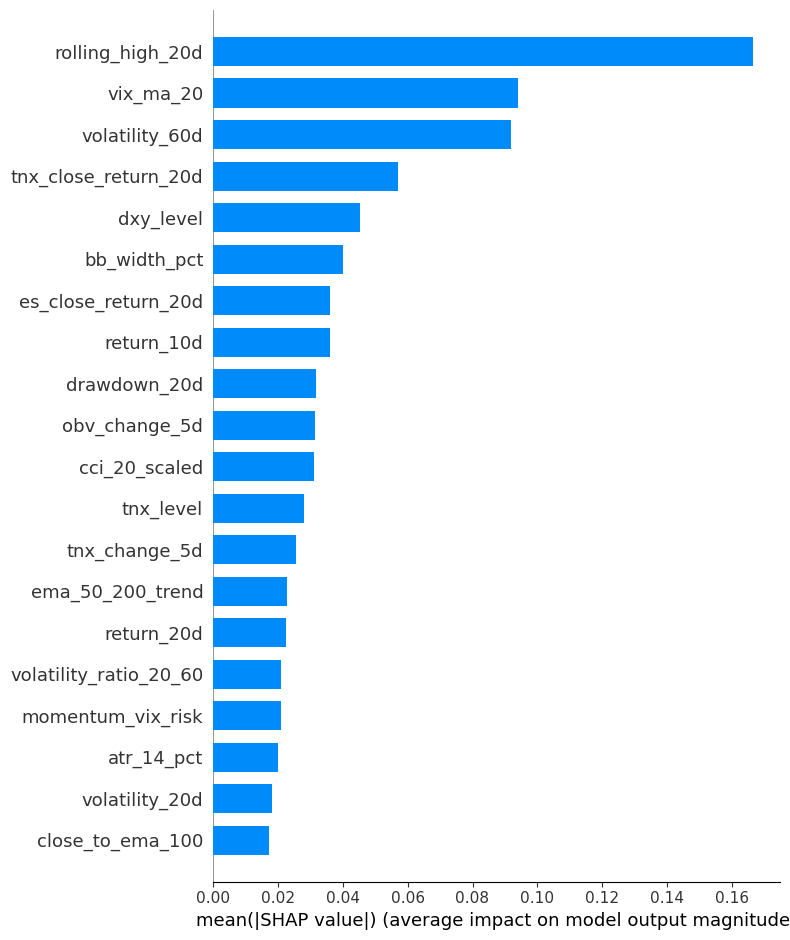

In [43]:
shap.summary_plot(
    shap_risk_on,
    X_explain,
    plot_type="bar",
    show=True
)

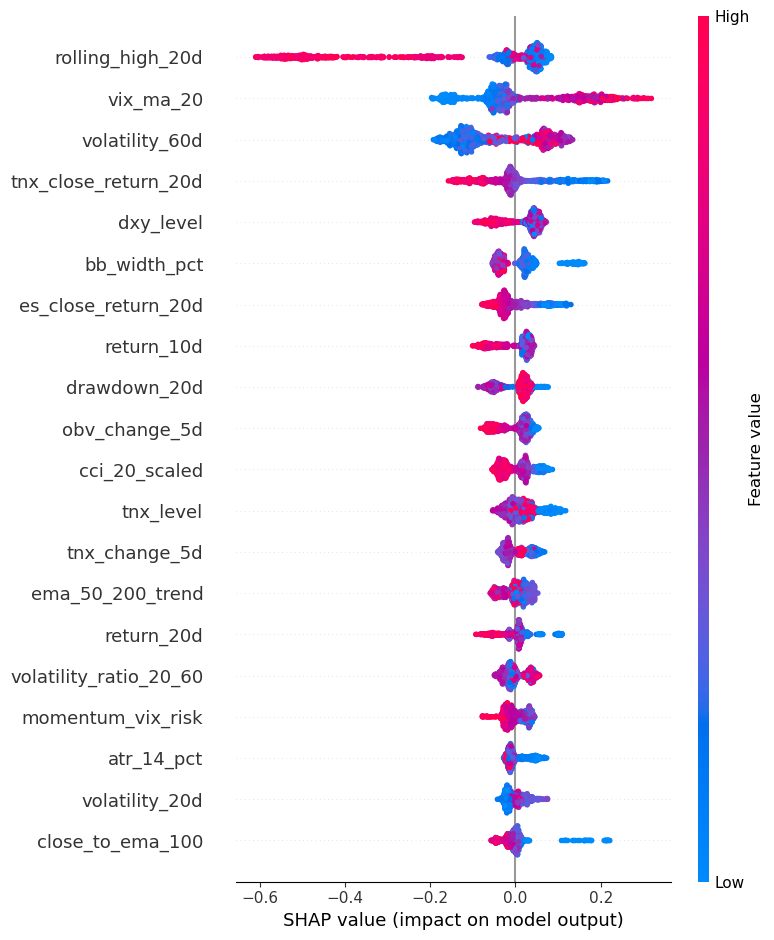

In [44]:
shap.summary_plot(
    shap_risk_on,
    X_explain,
    show=True
)

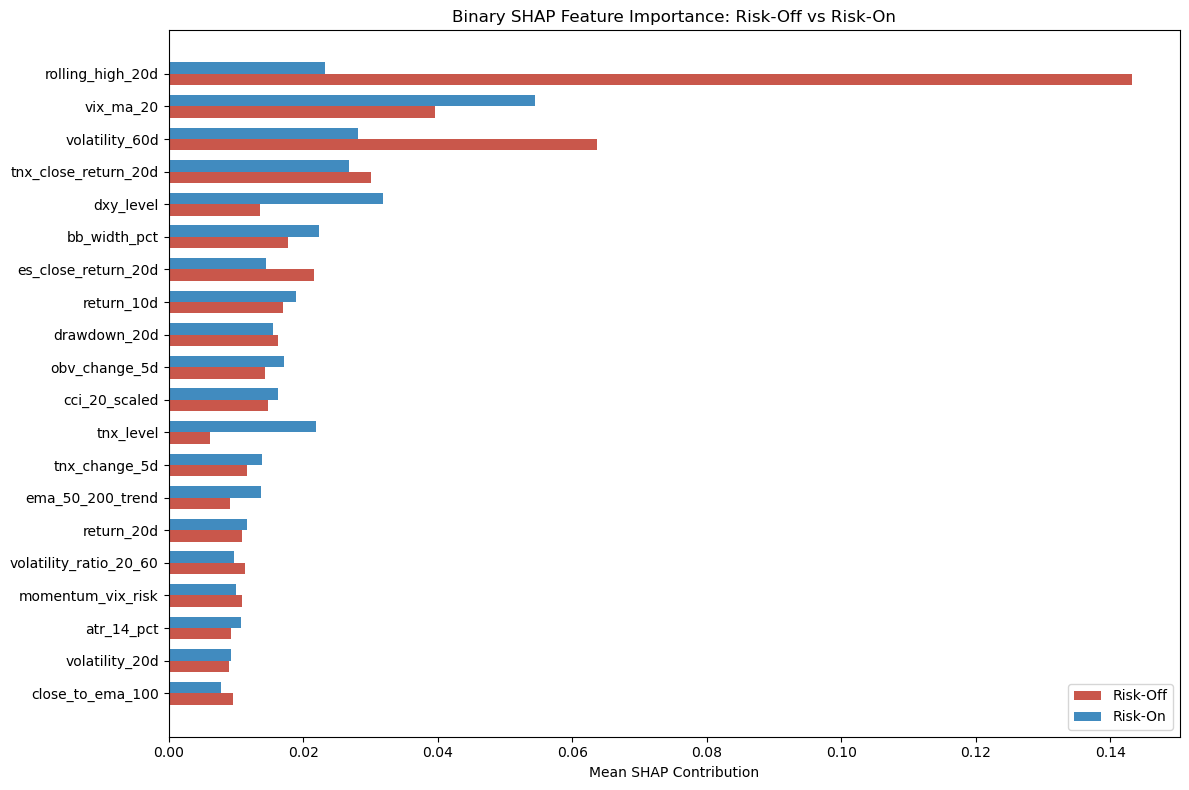

In [45]:
shap_df = pd.DataFrame(
    shap_risk_on,
    columns=X_explain.columns,
    index=X_explain.index
)

risk_on_importance = shap_df.clip(lower=0).mean()

risk_off_importance = (-shap_df.clip(upper=0)).mean()

binary_shap_importance = pd.DataFrame({
    "Risk-Off": risk_off_importance,
    "Risk-On": risk_on_importance
})

binary_shap_importance["total"] = (
    binary_shap_importance["Risk-Off"] +
    binary_shap_importance["Risk-On"]
)

top_n = 20

top_features = (
    binary_shap_importance
    .sort_values("total", ascending=False)
    .head(top_n)
    .drop(columns="total")
)

top_features = top_features.iloc[::-1]

risk_off_color = "#C0392B"
risk_on_color = "#1F77B4"

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(top_features))

bar_height = 0.35

ax.barh(
    y - bar_height / 2,
    top_features["Risk-Off"],
    height=bar_height,
    color=risk_off_color,
    alpha=0.85,
    label="Risk-Off"
)

ax.barh(
    y + bar_height / 2,
    top_features["Risk-On"],
    height=bar_height,
    color=risk_on_color,
    alpha=0.85,
    label="Risk-On"
)

ax.set_yticks(y)
ax.set_yticklabels(top_features.index)

ax.set_xlabel("Mean SHAP Contribution")
ax.set_title("Binary SHAP Feature Importance: Risk-Off vs Risk-On")

ax.legend()

plt.tight_layout()
plt.show()

In [46]:
val_proba = final_model.predict_proba(X_val_final)[:, 1]

val_df["risk_on_pred"] = (val_proba >= final_threshold).astype(int)

print("Validation risk-on predictions:")
print(val_df["risk_on_pred"].value_counts().sort_index())

Validation risk-on predictions:
risk_on_pred
0    731
1    291
Name: count, dtype: int64


In [47]:
import plotly.graph_objs as go
import pandas as pd
import numpy as np


def plot_ml_position_management(data,
                                start=None,
                                length=90,
                                start_date=None,
                                end_date=None,
                                title="Candlestick Chart",
                                min_change=0.001,
                                return_fig=False):

    plot_df = data.copy()

    if start_date is not None or end_date is not None:
        date_start = plot_df.index.min() if start_date is None else pd.to_datetime(start_date)
        date_end = plot_df.index.max() if end_date is None else pd.to_datetime(end_date)

        df_slice = plot_df.loc[
            (plot_df.index >= date_start) &
            (plot_df.index <= date_end)
        ].copy()
    else:
        if start is None:
            start = max(0, len(plot_df) - length)

        df_slice = plot_df.iloc[start:start + length].copy()

    if df_slice.empty:
        raise ValueError("The selected chart window is empty.")

    price_offset = max(
        (df_slice["High"] - df_slice["Low"]).mean() * 0.25,
        df_slice["Close"].mean() * 0.0015
    )

    fig = go.Figure()

    fig.add_trace(
        go.Candlestick(
            x=df_slice.index,
            open=df_slice["Open"],
            high=df_slice["High"],
            low=df_slice["Low"],
            close=df_slice["Close"],
            name="Candlestick",
            increasing_line_color="#2E8B57",
            decreasing_line_color="#C0392B"
        )
    )

    if "position" in df_slice.columns:
        position_change = df_slice["position"].diff().fillna(0)

        increase_idx = df_slice[position_change > min_change].index
        decrease_idx = df_slice[position_change < -min_change].index

        fig.add_trace(
            go.Scatter(
                x=increase_idx,
                y=df_slice.loc[increase_idx, "Low"] - price_offset,
                mode="markers+text",
                marker=dict(
                    size=11,
                    color="#1F77B4",
                    symbol="triangle-up"
                ),
                text=(df_slice.loc[increase_idx, "position"] * 100).round(0).astype(int).astype(str) + "%",
                textposition="bottom center",
                name="Exposure increase"
            )
        )

        fig.add_trace(
            go.Scatter(
                x=decrease_idx,
                y=df_slice.loc[decrease_idx, "High"] + price_offset,
                mode="markers+text",
                marker=dict(
                    size=11,
                    color="#D62728",
                    symbol="triangle-down"
                ),
                text=(df_slice.loc[decrease_idx, "position"] * 100).round(0).astype(int).astype(str) + "%",
                textposition="top center",
                name="Exposure reduction"
            )
        )

    if "turnover" in df_slice.columns:
        rebalance_idx = df_slice[df_slice["turnover"] > min_change].index

        fig.add_trace(
            go.Scatter(
                x=rebalance_idx,
                y=df_slice.loc[rebalance_idx, "Close"],
                mode="markers",
                marker=dict(
                    size=6,
                    color="#111111",
                    symbol="diamond"
                ),
                name="Rebalance"
            )
        )

    fig.update_layout(
        title=title,
        height=700,
        width=1350,
        showlegend=True,
        hovermode="x unified",
        xaxis_rangeslider_visible=False,
        margin=dict(l=60, r=30, t=70, b=50)
    )

    fig.update_yaxes(title_text="Price")
    fig.update_xaxes(
    title_text="Date",
    rangebreaks=[
        dict(bounds=["sat", "mon"])
    ]
)

    if return_fig:
        return fig

    fig.show()


In [48]:
test_df["risk_on_proba"] = final_model.predict_proba(X_test_final)[:, 1]
val_df["risk_on_proba"] = final_model.predict_proba(X_val_final)[:, 1]

test_df["risk_on_pred"] = (
    test_df["risk_on_proba"] >= final_threshold
).astype(int)

val_df["risk_on_pred"] = (
    val_df["risk_on_proba"] >= final_threshold
).astype(int)

bt_plot, _ = run_stock_strategy_backtest(
    test_df,
    proba_column="risk_on_proba",
    price_column="Close",
    lower_threshold=selected_risk_settings["lower_threshold"],
    upper_threshold=selected_risk_settings["upper_threshold"],
    base_exposure=selected_risk_settings["base_exposure"],
    model_tilt=selected_risk_settings["model_tilt"],
    trend_bonus=selected_risk_settings["trend_bonus"],
    trend_penalty=selected_risk_settings["trend_penalty"],
    risk_off_exposure=selected_risk_settings["risk_off_exposure"],
    risk_on_boost=selected_risk_settings.get("risk_on_boost", 0.0),
    recovery_min_exposure=selected_risk_settings.get("recovery_min_exposure", 0.85),
    recovery_step_up_limit=selected_risk_settings.get("recovery_step_up_limit", 0.15),
    early_risk_on_boost=selected_risk_settings.get("early_risk_on_boost", 0.05),
    early_recovery_min_exposure=selected_risk_settings.get("early_recovery_min_exposure", 0.75),
    early_risk_on_score_threshold=selected_risk_settings.get("early_risk_on_score_threshold", 4),
    bull_min_exposure=selected_risk_settings.get("bull_min_exposure", 1.00),
    bull_leverage_exposure=selected_risk_settings.get("bull_leverage_exposure", 1.25),
    target_vol=selected_risk_settings["target_vol"],
    vol_floor=selected_risk_settings["vol_floor"],
    vol_ceiling=selected_risk_settings["vol_ceiling"],
    vix_risk_multiplier=selected_risk_settings["vix_risk_multiplier"],
    drawdown_cutoff=selected_risk_settings["drawdown_cutoff"],
    drawdown_risk_multiplier=selected_risk_settings["drawdown_risk_multiplier"],
    min_exposure=selected_risk_settings["min_exposure"],
    max_exposure=selected_risk_settings["max_exposure"],
    rebalance_threshold=selected_risk_settings["rebalance_threshold"],
    fast_vol_threshold=selected_risk_settings.get("fast_vol_threshold", 1.40),
    cash_yield=selected_risk_settings["cash_yield"],
    leverage_financing_rate=selected_risk_settings.get("leverage_financing_rate", 0.06),
    cost_bps=selected_risk_settings["cost_bps"],
    use_sentiment_overlay=selected_risk_settings.get("use_sentiment_overlay", True),
    sentiment_news_z_threshold=selected_risk_settings.get("sentiment_news_z_threshold", 1.0),
    sentiment_sensitivity=selected_risk_settings.get("sentiment_sensitivity", 2.0),
    sentiment_positive_max_adjustment=selected_risk_settings.get("sentiment_positive_max_adjustment", 0.15),
    sentiment_negative_max_adjustment=selected_risk_settings.get("sentiment_negative_max_adjustment", 0.20),
    sentiment_asymmetric_factor=selected_risk_settings.get("sentiment_asymmetric_factor", 3.0),
    sentiment_whipsaw_days=selected_risk_settings.get("sentiment_whipsaw_days", 2),
    sentiment_regime_gate=selected_risk_settings.get("sentiment_regime_gate", True),
    sentiment_confidence_headlines=selected_risk_settings.get("sentiment_confidence_headlines", 3.0)
)

print("Final selected model:", final_model_name)
print("Risk-on threshold:", final_threshold)
print("Selected strategy settings:")
print(selected_risk_settings)

print("Validation risk-on predictions:")
print(val_df["risk_on_pred"].value_counts().sort_index())

print("Test risk-on predictions:")
print(test_df["risk_on_pred"].value_counts().sort_index())

print("Plot data columns available:")
print([col for col in ["risk_on_proba", "risk_on_pred", "target_position", "position", "fast_risk_off", "fast_risk_score", "early_risk_on", "early_risk_on_score", "strong_bull_regime", "leveraged_bull_regime", "leverage_amount", "turnover", "sentiment_score_scaled", "sentiment_confidence", "sentiment_adjustment", "sentiment_multiplier", "sentiment_whipsaw_active", "sentiment_risk_on", "sentiment_risk_off"] if col in bt_plot.columns])


Final selected model: Optuna tuned
Risk-on threshold: 0.5364596009254455
Selected strategy settings:
{'lower_threshold': 0.43163959980010985, 'upper_threshold': 0.5364596009254455, 'base_exposure': 0.7, 'model_tilt': 0.2, 'trend_bonus': 0.05, 'trend_penalty': 0.2, 'risk_off_exposure': 0.4, 'risk_on_boost': 0.1, 'recovery_min_exposure': 0.85, 'recovery_step_up_limit': 0.15, 'bull_min_exposure': 1.0, 'bull_leverage_exposure': 1.25, 'target_vol': 0.5, 'vol_floor': 0.65, 'vol_ceiling': 1.1, 'vix_risk_multiplier': 0.9, 'drawdown_cutoff': -0.05, 'drawdown_risk_multiplier': 0.7, 'min_exposure': 0.25, 'max_exposure': 1.25, 'rebalance_threshold': 0.15, 'fast_vol_threshold': 1.5, 'cash_yield': 0.04, 'leverage_financing_rate': 0.06, 'cost_bps': 5.0, 'early_risk_on_boost': 0.05, 'early_recovery_min_exposure': 0.75, 'early_risk_on_score_threshold': 4.0, 'use_sentiment_overlay': True, 'sentiment_sensitivity': 1.0, 'sentiment_positive_max_adjustment': 0.05, 'sentiment_negative_max_adjustment': 0.1, '

In [49]:
plot_ml_position_management(
    bt_plot,
    start=0,
    length=len(bt_plot),
    title=f"{symbol} - Candlestick Chart - Full Out-of-Sample Test Window"
)


## 10. Final Out-of-Sample Strategy Evaluation

In [50]:
val_df["risk_on_proba"] = final_model.predict_proba(X_val_final)[:, 1]
test_df["risk_on_proba"] = final_model.predict_proba(X_test_final)[:, 1]

lower_prob_threshold = selected_risk_settings["lower_threshold"]
upper_prob_threshold = selected_risk_settings["upper_threshold"]

print("Locked validation lower probability threshold:", lower_prob_threshold)
print("Locked validation upper probability threshold:", upper_prob_threshold)
print("Locked stock strategy settings:")
print(selected_risk_settings)

Locked validation lower probability threshold: 0.43163959980010985
Locked validation upper probability threshold: 0.5364596009254455
Locked stock strategy settings:
{'lower_threshold': 0.43163959980010985, 'upper_threshold': 0.5364596009254455, 'base_exposure': 0.7, 'model_tilt': 0.2, 'trend_bonus': 0.05, 'trend_penalty': 0.2, 'risk_off_exposure': 0.4, 'risk_on_boost': 0.1, 'recovery_min_exposure': 0.85, 'recovery_step_up_limit': 0.15, 'bull_min_exposure': 1.0, 'bull_leverage_exposure': 1.25, 'target_vol': 0.5, 'vol_floor': 0.65, 'vol_ceiling': 1.1, 'vix_risk_multiplier': 0.9, 'drawdown_cutoff': -0.05, 'drawdown_risk_multiplier': 0.7, 'min_exposure': 0.25, 'max_exposure': 1.25, 'rebalance_threshold': 0.15, 'fast_vol_threshold': 1.5, 'cash_yield': 0.04, 'leverage_financing_rate': 0.06, 'cost_bps': 5.0, 'early_risk_on_boost': 0.05, 'early_recovery_min_exposure': 0.75, 'early_risk_on_score_threshold': 4.0, 'use_sentiment_overlay': True, 'sentiment_sensitivity': 1.0, 'sentiment_positive_ma

In [51]:
bt_test_risk, metrics_test_risk = run_stock_strategy_backtest(
    test_df,
    proba_column="risk_on_proba",
    price_column="Close",
    lower_threshold=selected_risk_settings["lower_threshold"],
    upper_threshold=selected_risk_settings["upper_threshold"],
    base_exposure=selected_risk_settings["base_exposure"],
    model_tilt=selected_risk_settings["model_tilt"],
    trend_bonus=selected_risk_settings["trend_bonus"],
    trend_penalty=selected_risk_settings["trend_penalty"],
    risk_off_exposure=selected_risk_settings["risk_off_exposure"],
    risk_on_boost=selected_risk_settings["risk_on_boost"],
    recovery_min_exposure=selected_risk_settings["recovery_min_exposure"],
    recovery_step_up_limit=selected_risk_settings.get("recovery_step_up_limit", 0.15),
    early_risk_on_boost=selected_risk_settings.get("early_risk_on_boost", 0.05),
    early_recovery_min_exposure=selected_risk_settings.get("early_recovery_min_exposure", 0.75),
    early_risk_on_score_threshold=selected_risk_settings.get("early_risk_on_score_threshold", 4),
    bull_min_exposure=selected_risk_settings["bull_min_exposure"],
    bull_leverage_exposure=selected_risk_settings["bull_leverage_exposure"],
    target_vol=selected_risk_settings["target_vol"],
    vol_floor=selected_risk_settings["vol_floor"],
    vol_ceiling=selected_risk_settings["vol_ceiling"],
    vix_risk_multiplier=selected_risk_settings["vix_risk_multiplier"],
    drawdown_cutoff=selected_risk_settings["drawdown_cutoff"],
    drawdown_risk_multiplier=selected_risk_settings["drawdown_risk_multiplier"],
    min_exposure=selected_risk_settings["min_exposure"],
    max_exposure=selected_risk_settings["max_exposure"],
    rebalance_threshold=selected_risk_settings["rebalance_threshold"],
    fast_vol_threshold=selected_risk_settings["fast_vol_threshold"],
    cash_yield=selected_risk_settings["cash_yield"],
    leverage_financing_rate=selected_risk_settings["leverage_financing_rate"],
    cost_bps=selected_risk_settings["cost_bps"],
    use_sentiment_overlay=selected_risk_settings.get("use_sentiment_overlay", True),
    sentiment_news_z_threshold=selected_risk_settings.get("sentiment_news_z_threshold", 1.0),
    sentiment_sensitivity=selected_risk_settings.get("sentiment_sensitivity", 2.0),
    sentiment_positive_max_adjustment=selected_risk_settings.get("sentiment_positive_max_adjustment", 0.15),
    sentiment_negative_max_adjustment=selected_risk_settings.get("sentiment_negative_max_adjustment", 0.20),
    sentiment_asymmetric_factor=selected_risk_settings.get("sentiment_asymmetric_factor", 3.0),
    sentiment_whipsaw_days=selected_risk_settings.get("sentiment_whipsaw_days", 2),
    sentiment_regime_gate=selected_risk_settings.get("sentiment_regime_gate", True),
    sentiment_confidence_headlines=selected_risk_settings.get("sentiment_confidence_headlines", 3.0)
)

metrics_test_risk


Strategy Total Return             0.721366
Buy & Hold Total Return           0.970267
Excess Return vs Buy & Hold      -0.248901
Annualized Return                 0.155891
Annualized Volatility             0.210249
Sharpe Ratio                      0.741457
Sortino Ratio                     1.069487
Calmar Ratio                      0.597067
Profit Factor                     1.144521
Max Drawdown                     -0.261094
Win Rate                          0.521017
Average Exposure                  0.586573
Strong Bull Days                 12.000000
Leveraged Days                   28.000000
Average Leverage                  0.003656
Total Financing Cost              0.000865
Fast Risk-Off Days              334.000000
Early Risk-On Days              605.000000
Average Early Risk-On Score       4.065494
Sentiment Risk-On Days            6.000000
Sentiment Risk-Off Days           0.000000
Average Sentiment Multiplier      1.000050
Whipsaw Filtered Days            42.000000
Average Sen

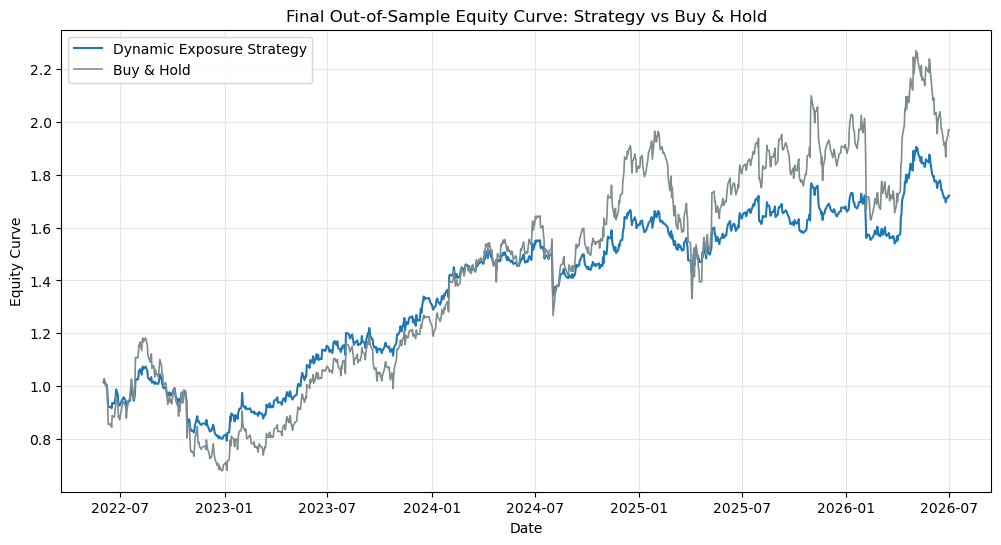

In [52]:
strategy_color = "#1F77B4"
buy_hold_color = "#7F8C8D"

plt.figure(figsize=(12, 6))

plt.plot(
    bt_test_risk.index,
    bt_test_risk["strategy_equity"],
    label="Dynamic Exposure Strategy",
    color=strategy_color,
    linewidth=1.5
)

plt.plot(
    bt_test_risk.index,
    bt_test_risk["buy_hold_equity"],
    label="Buy & Hold",
    color=buy_hold_color,
    linewidth=1.2,
)

plt.title("Final Out-of-Sample Equity Curve: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

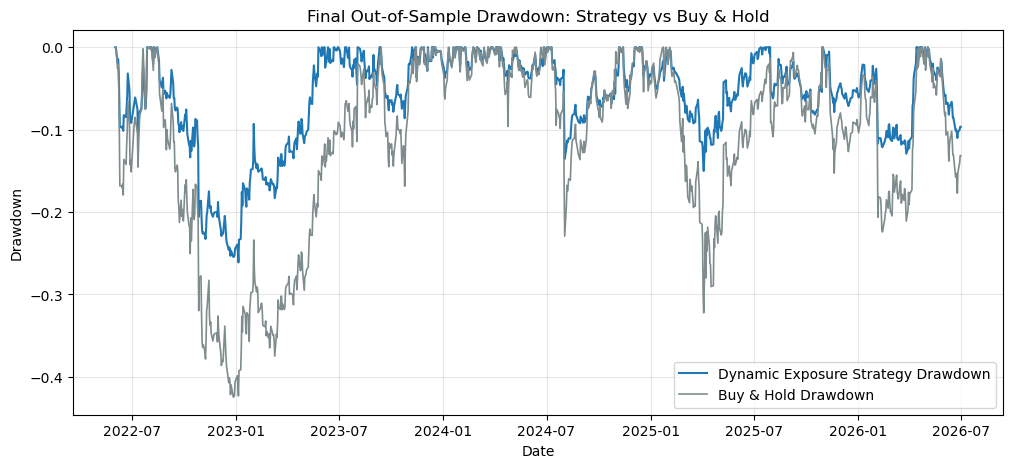

In [53]:
strategy_color = "#1F77B4"
buy_hold_color = "#7F8C8D"

plt.figure(figsize=(12, 5))

plt.plot(
    bt_test_risk.index,
    bt_test_risk["strategy_drawdown"],
    label="Dynamic Exposure Strategy Drawdown",
    color=strategy_color,
    linewidth=1.5
)

plt.plot(
    bt_test_risk.index,
    bt_test_risk["buy_hold_drawdown"],
    label="Buy & Hold Drawdown",
    color=buy_hold_color,
    linewidth=1.2
)

plt.title("Final Out-of-Sample Drawdown: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

In [54]:
strategy_metrics = pd.Series({
    "Total Return": metrics_test_risk["Strategy Total Return"],
    "Annualized Return": metrics_test_risk["Annualized Return"],
    "Annualized Volatility": metrics_test_risk["Annualized Volatility"],
    "Sharpe Ratio": metrics_test_risk["Sharpe Ratio"],
    "Sortino Ratio": metrics_test_risk["Sortino Ratio"],
    "Calmar Ratio": metrics_test_risk["Calmar Ratio"],
    "Profit Factor": metrics_test_risk["Profit Factor"],
    "Max Drawdown": metrics_test_risk["Max Drawdown"],
    "Win Rate": metrics_test_risk["Win Rate"],
    "Average Exposure": metrics_test_risk["Average Exposure"],
    "Rebalance Days": metrics_test_risk["Rebalance Days"],
    "Total Turnover": metrics_test_risk["Total Turnover"],
})

buy_hold_metrics = get_buy_hold_metrics(bt_test_risk)

buy_hold_metrics["Rebalance Days"] = 1
buy_hold_metrics["Total Turnover"] = 1.0

metrics_comparison = pd.DataFrame({
    "Dynamic Exposure Strategy": strategy_metrics,
    "Buy & Hold": buy_hold_metrics
})

rows_to_hide = [
    "Average Daily Turnover",
    "Average Leverage",
    "Fast Risk-Off Days",
    "Leveraged Days",
    "Strong Bull Days",
    "Total Financing Cost"
]

metrics_comparison = metrics_comparison.drop(
    index=rows_to_hide,
    errors="ignore"
)


In [55]:
metrics_comparison_display = pd.DataFrame(index=metrics_comparison.index)

percentage_rows = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Win Rate",
    "Average Exposure",
    "Average Daily Turnover"
]

ratio_rows = [
    "Sharpe Ratio",
    "Sortino Ratio",
    "Calmar Ratio",
    "Profit Factor",
    "Total Turnover"
]

integer_rows = [
    "Rebalance Days"
]

for col in metrics_comparison.columns:

    formatted_values = []

    for row in metrics_comparison.index:

        value = metrics_comparison.loc[row, col]

        if pd.isna(value):
            formatted_values.append("")

        elif row in percentage_rows:
            formatted_values.append(f"{float(value) * 100:.2f}%")

        elif row in ratio_rows:
            formatted_values.append(f"{float(value):.2f}")

        elif row in integer_rows:
            formatted_values.append(f"{int(float(value))}")

        else:
            formatted_values.append(value)

    metrics_comparison_display[col] = formatted_values

metrics_comparison_display

,Dynamic Exposure Strategy,Buy & Hold
Annualized Return,15.59%,23.39%
Annualized Volatility,21.02%,36.58%
Average Exposure,58.66%,100.00%
Calmar Ratio,0.60,0.55
Max Drawdown,-26.11%,-42.46%
Profit Factor,1.14,1.12
Rebalance Days,268,1
Sharpe Ratio,0.74,0.64
Sortino Ratio,1.07,0.92
Total Return,72.14%,97.03%


In [56]:
signal_check = test_df.copy()

if "risk_on_pred" not in signal_check.columns:
    signal_check["risk_on_pred"] = (
        signal_check["risk_on_proba"] >= final_threshold
    ).astype(int)

signal_quality = (
    signal_check
    .groupby("risk_on_pred")["future_return"]
    .agg(["count", "mean", "median", "std"])
)

signal_quality["positive_rate"] = (
    signal_check
    .groupby("risk_on_pred")["future_return"]
    .apply(lambda x: (x > 0).mean())
)

if "bt_test_risk" in globals() and "fast_risk_off" in bt_test_risk.columns:
    risk_off_summary = bt_test_risk.groupby("fast_risk_off")[[
        "market_return",
        "strategy_return_net",
        "position"
    ]].agg(["count", "mean", "median"])

    display(signal_quality)
    display(risk_off_summary)
else:
    display(signal_quality)

,count,mean,median,std,positive_rate
risk_on_pred,,,,,
0,909,0.003257,0.005295,0.040704,0.561056
1,114,0.019775,0.014632,0.052227,0.657895


market_return                     strategy_return_net            \
                      count      mean    median               count      mean   
fast_risk_off                                                                   
0                       689  0.004041  0.003156                 689  0.002328   
1                       334 -0.005493 -0.004756                 334 -0.002907   

                        position                   
                 median    count      mean median  
fast_risk_off                                      
0              0.002008      689  0.659860    0.7  
1             -0.001820      334  0.435391    0.4

In [57]:
# ---------------------------------------------------------------------------
# Generate and open HTML presentation
# ---------------------------------------------------------------------------
import sys
import os
import importlib
import webbrowser
from pathlib import Path
import plotly.graph_objs as go

PROJECT_DIR = Path.cwd().resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import generate_presentation

generate_presentation = importlib.reload(generate_presentation)
generate_html = generate_presentation.generate_html

# Create Plotly figures for the presentation
presentation_bt = bt_test_risk.copy()

# Equity curve figure
equity_fig = go.Figure()
equity_fig.add_trace(go.Scatter(
    x=presentation_bt.index,
    y=presentation_bt["strategy_equity"],
    mode="lines",
    name="Dynamic Exposure Strategy",
    line=dict(color="#1F77B4", width=2)
))
equity_fig.add_trace(go.Scatter(
    x=presentation_bt.index,
    y=presentation_bt["buy_hold_equity"],
    mode="lines",
    name="Buy & Hold",
    line=dict(color="#7F8C8D", width=2)
))
equity_fig.update_layout(
    title=f"Final Out-of-Sample Equity Curve - {symbol}",
    xaxis_title="Date",
    yaxis_title="Equity",
    template="plotly_white",
    hovermode="x unified"
)

# Drawdown figure
drawdown_fig = go.Figure()
drawdown_fig.add_trace(go.Scatter(
    x=presentation_bt.index,
    y=presentation_bt["strategy_drawdown"],
    mode="lines",
    name="Dynamic Exposure Strategy Drawdown",
    line=dict(color="#1F77B4", width=2)
))
drawdown_fig.add_trace(go.Scatter(
    x=presentation_bt.index,
    y=presentation_bt["buy_hold_drawdown"],
    mode="lines",
    name="Buy & Hold Drawdown",
    line=dict(color="#7F8C8D", width=2)
))
drawdown_fig.update_layout(
    title=f"Final Out-of-Sample Drawdown - {symbol}",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    template="plotly_white",
    hovermode="x unified"
)

# Candlestick + exposure figure (same function as notebook chart)
candlestick_source = bt_plot if "bt_plot" in globals() else presentation_bt

candlestick_fig = plot_ml_position_management(
    candlestick_source,
    start=0,
    length=len(candlestick_source),
    title=f"{symbol} - Candlestick Chart - Full Out-of-Sample Test Window",
    return_fig=True
)

# Compact SHAP figures for presentation
# Use notebook SHAP values and embed compact PNG images for smaller HTML payloads.
import io
import base64


def _mpl_current_fig_to_data_uri(dpi=120, size=None):
    fig = plt.gcf()
    if size is not None:
        fig.set_size_inches(*size)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight", dpi=dpi)
    plt.close(fig)
    buffer.seek(0)
    encoded = base64.b64encode(buffer.read()).decode("ascii")
    return "data:image/png;base64," + encoded


shap_bar_uri = ""
shap_summary_uri = ""
shap_binary_uri = ""

try:
    # Compact notebook bar plot for presentation.
    shap.summary_plot(
        shap_risk_on,
        X_explain,
        plot_type="bar",
        max_display=15,
        plot_size=(10, 4.8),
        show=False
    )
    shap_bar_uri = _mpl_current_fig_to_data_uri()

    # Compact notebook risk-on summary/beeswarm plot for presentation.
    shap.summary_plot(
        shap_risk_on,
        X_explain,
        max_display=15,
        plot_size=(10, 4.8),
        show=False
    )
    shap_summary_uri = _mpl_current_fig_to_data_uri()

    # Compact notebook binary SHAP plot as matplotlib image.
    if "binary_shap_importance" not in globals():
        shap_df = pd.DataFrame(
            shap_risk_on,
            columns=X_explain.columns,
            index=X_explain.index
        )
        risk_on_importance = shap_df.clip(lower=0).mean()
        risk_off_importance = (-shap_df.clip(upper=0)).mean()
        binary_shap_importance = pd.DataFrame({
            "Risk-Off": risk_off_importance,
            "Risk-On": risk_on_importance
        })
        binary_shap_importance["total"] = (
            binary_shap_importance["Risk-Off"] +
            binary_shap_importance["Risk-On"]
        )

    top_n = 15
    top_features = (
        binary_shap_importance
        .sort_values("total", ascending=False)
        .head(top_n)
        .drop(columns="total", errors="ignore")
    )
    top_features = top_features.iloc[::-1]

    risk_off_color = "#C0392B"
    risk_on_color = "#1F77B4"

    fig, ax = plt.subplots(figsize=(11, 5.2))
    y = np.arange(len(top_features))
    bar_height = 0.35

    ax.barh(
        y - bar_height / 2,
        top_features["Risk-Off"],
        height=bar_height,
        color=risk_off_color,
        alpha=0.85,
        label="Risk-Off"
    )

    ax.barh(
        y + bar_height / 2,
        top_features["Risk-On"],
        height=bar_height,
        color=risk_on_color,
        alpha=0.85,
        label="Risk-On"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(top_features.index)
    ax.set_xlabel("Mean SHAP Contribution")
    ax.set_title("Binary SHAP Feature Importance: Risk-Off vs Risk-On")
    ax.legend()
    plt.tight_layout()
    shap_binary_uri = _mpl_current_fig_to_data_uri()
except Exception as shap_error:
    print("Could not create compact notebook SHAP figures for presentation:", shap_error)

# Generate HTML presentation
metrics_html = metrics_comparison_display.to_html(classes="dataframe", border=1)

# Convert pandas Series to dict for generate_html
strategy_metrics_dict = strategy_metrics.to_dict() if hasattr(strategy_metrics, 'to_dict') else strategy_metrics
buy_hold_metrics_dict = buy_hold_metrics.to_dict() if hasattr(buy_hold_metrics, 'to_dict') else buy_hold_metrics

presentation_path = generate_html(
    symbol=symbol,
    model_name=final_model_name,
    strategy_metrics=strategy_metrics_dict,
    buy_hold_metrics=buy_hold_metrics_dict,
    equity_json=equity_fig.to_json(),
    drawdown_json=drawdown_fig.to_json(),
    shap_bar_json=shap_bar_uri,
    shap_summary_json=shap_summary_uri,
    shap_binary_json=shap_binary_uri,
    candlestick_json=candlestick_fig.to_json(),
    metrics_html=metrics_html
)

print("Presentation created:", presentation_path)

# Open presentation in browser
from IPython.display import display, HTML

path = str(Path(presentation_path).resolve())
print("Presentation path:", path)

# Show clickable link (works reliably in VSCode notebook)
uri = Path(path).as_uri()
display(HTML(f"<a href='{uri}' target='_blank' style='font-size:18px;font-weight:bold;'>Open Presentation in Browser</a>"))

# Also try to auto-open via multiple methods
success = False
try:
    uri = Path(path).as_uri()
    if webbrowser.open(uri):
        success = True
except Exception:
    pass

if not success:
    try:
        os.startfile(path)
        success = True
    except Exception:
        pass

if not success:
    try:
        import subprocess
        subprocess.Popen(["cmd", "/c", "start", "", path], shell=True)
        success = True
    except Exception:
        pass

if success:
    print("Presentation auto-opened in browser.")
else:
    print("Could not auto-open. Click the link above or open manually in File Explorer.")


HTML latest written to: C:\Users\teorg\Desktop\Dynamic_Risk_Exposure_Engine\presentation_outputs\ml_model_presentation_latest.html
HTML archived to: C:\Users\teorg\Desktop\Dynamic_Risk_Exposure_Engine\presentation_outputs\ml_model_presentation_AMZN_20260717_170550.html
History: 12 runs (EURUSD=X, NVDA, XAU, AVGO, JNJ, MSFT, TSLA, AAPL, ORCL, BLK, GOOG, AMZN)
Presentation created: C:\Users\teorg\Desktop\Dynamic_Risk_Exposure_Engine\presentation_outputs\ml_model_presentation_latest.html
Presentation path: C:\Users\teorg\Desktop\Dynamic_Risk_Exposure_Engine\presentation_outputs\ml_model_presentation_latest.html


Presentation auto-opened in browser.
